# Social-Media Attention as an Equity Factor: NLP on 5.6 Million StockTwits Posts

Cecilia Lo Cicero, Sara Pulidori, Alissa Sharuda, Nico Visentin

## Executive summary

1. **Domain fit matters more than domain label.** On 10,000 human-labelled StockTwits messages, FinTwitBERT (finance + social media) separates bullish from bearish best (AUC 0.757), ahead of Twitter-RoBERTa (0.700) and FinBERT (0.633), which calls about 80% of messages neutral. A zero-shot LLM (gpt-oss-120b) does better still: AUC 0.838 vs 0.766 for FinTwitBERT on the same 980 messages.
2. **Sentiment reacts to prices; it does not predict them.** Daily abnormal sentiment correlates with same-day returns (Spearman 0.265) but not with next-day returns (−0.003). On days with moves above 5%, sentiment separates rises from falls (AUC 0.83 over 947 moves), but in the five days before a move it says nothing about its direction.
3. **Model choice can flip a headline result.** On the same 1,000 posts, FinTwitBERT's average tone is −0.11 and the LLM's is +0.11 (agreement 64%, Cohen's κ 0.46). Most of the gap comes from words such as "short", "puts" and "bear" being read as bearish regardless of the author's position. Relative findings (index ETFs less positive than single stocks; tone stable over time) hold under both models.
4. **Raw attention is mostly a popularity contest.** The top 1% of users write 46.7% of posts, and five tickers take about 74% of mentions every year. A breadth-based abnormal attention measure (BAA: users capped at one per stock-month, multi-ticker posts split, compared with the stock's own 12-month median) rotates across stocks: 23 of 25 tickers reach the BAA top 5 in at least one year.
5. **No evidence that abnormal attention predicts returns.** High-minus-low BAA earns +0.37% per month for deciles (t = 0.54) and +0.20% for quintiles (t = 0.47). The long-short portfolio's FF5 alpha is +0.54% (t = 0.73) and its five-factor R² is about 0.06. With only 15–19 matched S&P 500 stocks per month, this is an absence of evidence with low statistical power, not proof of no effect.

Step numbers follow the original assignment's task numbering.

# 1. Data: loading, de-duplication and cleaning

### ***Step 1.0:*** *Setup*

Dependencies: see `requirements.txt`.

In [ ]:
import zipfile          # built into Python: lets us open .zip files without unzipping
import pandas as pd
import plotly.express as px  # plotly's quick-chart module, nicknamed px
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm                 # to build custom colour scales (LogNorm: log colour scale)
import matplotlib.ticker as mticker
from matplotlib.ticker import PercentFormatter
from matplotlib.transforms import blended_transform_factory
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.dates as mdates
import time                                                                   # to measure how long the model takes
from tqdm.auto import tqdm                                                    # progress bar (installed together with transformers)
import html   # built into Python: converts HTML codes like &quot; into normal characters
from transformers import pipeline                                             # all-in-one tool: tokenizer + model + probabilities
import re                                                                     # regular expressions (text patterns)
import emoji                                                                  # emoji list + demojize function
from collections import Counter                                               # counts how often each item appears
import nltk                                                                   # Natural Language Toolkit
from nltk.corpus import stopwords                                             # standard English stopword list
from nltk.stem import WordNetLemmatizer                                       # tool that finds a word's dictionary form
from collections import Counter                                               # counts how often each item appears
from wordcloud import WordCloud                                               # draws word clouds
import os, json, getpass                                                      # environment variables, JSON reading, hidden password input
from groq import Groq
from pathlib import Path
import gc
import warnings
import matplotlib.dates as mdates
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
import torch
from openai import OpenAI
from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score , cohen_kappa_score

In [ ]:
def read_zip(zip_path):
    """Open a zip, read every CSV inside it, and stack them into one table."""
    tables = []
    with zipfile.ZipFile(zip_path) as z:                  # open the zip
        for name in z.namelist():                         # list of files inside
            if name.endswith('.csv'):                     # keep only the CSVs
                with z.open(name) as f:
                    tables.append(pd.read_csv(f))         # read one CSV into a table
                print(f'{name:<45} {len(tables[-1]):>10,} tweets')
    return pd.concat(tables, ignore_index=True)           # stack all tables on top of each other

data1 = read_zip('UnlabelledDataset.zip')     # 20 tickers
data2 = read_zip('UnlabelledDataset_2.zip')   # AAPL, AMZN, NFLX, QQQ, TSLA

Data from 2010/stocktwits_ADBE.csv                36,709 tweets
Data from 2010/stocktwits_BAC.csv                165,879 tweets
Data from 2010/stocktwits_BRK.A.csv               11,302 tweets
Data from 2010/stocktwits_BRK.B.csv               33,718 tweets
Data from 2010/stocktwits_DIA.csv                189,685 tweets
Data from 2010/stocktwits_DIS.csv                245,751 tweets
Data from 2010/stocktwits_FB.csv                 112,115 tweets
Data from 2010/stocktwits_GOOG.csv               135,505 tweets
Data from 2010/stocktwits_GOOGL.csv              108,029 tweets
Data from 2010/stocktwits_HD.csv                  52,644 tweets
Data from 2010/stocktwits_INTC.csv                15,502 tweets
Data from 2010/stocktwits_JNJ.csv                 39,036 tweets
Data from 2010/stocktwits_PG.csv                  31,494 tweets
Data from 2010/stocktwits_SPY.csv                153,794 tweets
Data from 2010/stocktwits_T.csv                   70,316 tweets
Data from 2010/stocktwits_UNH.csv       

In [ ]:
print(data1.shape, data2.shape)
data1.head()

*Output removed for privacy (raw rows with user identifiers).*

In [ ]:
data2.head()

*Output removed for privacy (raw rows with user identifiers).*

____________

### ***Step 1.1:*** *Basic Checks*

In [ ]:
def basic_check(df, name):
    """Print column types, missing values and the time period of a dataset."""
    print(f'===== {name} =====')
    print('\nColumn types:')
    print(df.dtypes)
    print('\nMissing values per column:')
    print(df.isna().sum())

# Convert the datetime column from text into real dates
data1['datetime'] = pd.to_datetime(data1['datetime'], utc=True)
data2['datetime'] = pd.to_datetime(data2['datetime'], utc=True)

basic_check(data1, 'data1')
print('\nPeriod:', data1['datetime'].min(), '->', data1['datetime'].max())

basic_check(data2, 'data2')
print('\nPeriod:', data2['datetime'].min(), '->', data2['datetime'].max())

===== data1 =====

Column types:
symbol                     object
message                    object
datetime      datetime64[ns, UTC]
user                        int64
message_id                  int64
dtype: object

Missing values per column:
symbol        0
message       0
datetime      0
user          0
message_id    0
dtype: int64

Period: 2009-07-13 20:05:11+00:00 -> 2020-07-22 22:45:44+00:00
===== data2 =====

Column types:
symbol                     object
message                    object
datetime      datetime64[ns, UTC]
user                        int64
message_id                  int64
dtype: object

Missing values per column:
symbol        0
message       0
datetime      0
user          0
message_id    0
dtype: int64

Period: 2009-07-10 21:47:36+00:00 -> 2020-07-24 01:15:39+00:00


After checking the data we can identify that:
- The column data types are correct. `symbol` and `messages` are text (object), `user` and `message_id` are whole numbers (int64), and `datetime` is now a real date.
- There are no missing values in any column. But worth mentioning that "no empty cells" isn't the same as "clean": a tweet could just be a link or a list of tickers. We'll deal with that in later steps when we clean the text.
- Both datasets cover the same period: July 2009 to July 2020.
- Since both are the same kind of data from the same period, we can now combine them into one table.

_____________

### ***Step 1.2:*** *Check for duplicate tweets*

In [ ]:
# Combine both datasets into one table, then delete the originals to free memory
tweets_all = pd.concat([data1, data2], ignore_index=True)
del data1, data2

n_rows   = len(tweets_all)
n_unique = tweets_all['message_id'].nunique()   # number of different tweet IDs

print(f'Total rows:     {n_rows:,}')
print(f'Unique tweets:  {n_unique:,}')
print(f'Duplicate rows: {n_rows - n_unique:,} ({1 - n_unique / n_rows:.1%})')

# 1) Exact duplicates: same tweet ID AND same stock
exact = tweets_all.duplicated(subset=['message_id', 'symbol']).sum()
print(f'\nExact duplicates (same tweet, same stock): {exact:,}')

# 2) Cross-listed: under how many different stocks is each tweet filed?
stocks_per_tweet = tweets_all.groupby('message_id')['symbol'].nunique()
print('\nNumber of stocks a tweet is filed under -> number of tweets:')
print(stocks_per_tweet.value_counts().sort_index())

# Show one example of a tweet filed under 2 stocks
pd.set_option('display.max_colwidth', 200)       # show full tweet text
example_id = stocks_per_tweet[stocks_per_tweet == 2].index[0]
tweets_all[tweets_all['message_id'] == example_id][['symbol', 'message']]

Total rows:     6,483,233
Unique tweets:  5,564,920
Duplicate rows: 918,313 (14.2%)

Exact duplicates (same tweet, same stock): 73,148

Number of stocks a tweet is filed under -> number of tweets:
symbol
1     4898641
2      542264
3       83983
4       29543
5        7350
6        2285
7         621
8         147
9          58
10         20
11          6
12          2
Name: count, dtype: int64


,symbol,message
202587,BAC,@USER Love $amzn and audible add in $nflx and they just need to add a better UI and they become dominant
4088075,NFLX,@USER Love $amzn and audible add in $nflx and they just need to add a better UI and they become dominant


**We combine the datasets** into a single table of 6,483,233 rows. However, there are only 5,564,920 unique tweet IDs: 918,313 rows (14.2%) are additional tweet–stock rows.

There are 2 types of duplicates:
- **Exact duplicates (73,148 rows).** The same tweet filed twice under the same stock. These are removed (pure data errors).
- **Cross-listed tweets (845,165 extra rows).** The same tweet filed under several stocks, because it mentions several tickers. 88% of tweets are filed under a single stock, about 10% under two, and a small tail under up to 12 stocks. The tweets filed under many stocks are most likely bots posting lists of tickers.

The `symbol` column is not fully reliable. In our example, a tweet mentioning `$amzn` and `$nflx` is filed under BAC and NFLX, but not under AMZN. Take the per-stock results with caution as the ticker mentioned does not always match what the tweet is about. Note: tickers appear in lowercase (`$amzn`), which we must account for when searching the text.

**How we organise the data.**
- We don't consider cross-listed tweets as errors, but we remove the duplicates to not alter the sample-level statistics. We therefore split the data into two tables, linked by `message_id`:

- **`tweets` (5,564,920 rows).** Each tweet seen once, with its text, date, author, and the number of stocks it is filed under (`n_stocks`). Used for all sample-level statistics: number of tweets, words per tweet, sentiment.
- **`tweet_stock` (6,410,085 rows).** One row per tweet–stock pair. Used for per-stock analysis, where a tweet about two stocks rightly counts for both.

This method avoids double-counting and keeps memory use low, since the tweet text is stored only once.

In [ ]:
# 1) Remove exact duplicates (same tweet, same stock) -- these are data errors
tweets_all = tweets_all.drop_duplicates(subset=['message_id', 'symbol'])

# 2) Link table: which tweet is filed under which stock (small: two number/text columns)
tweet_stock = tweets_all[['message_id', 'symbol']].reset_index(drop=True)

# 3) Main table: each tweet once, without the symbol column
tweets = (tweets_all.drop_duplicates(subset='message_id').drop(columns='symbol').reset_index(drop=True))
tweets['n_stocks'] = tweets['message_id'].map(stocks_per_tweet)   # how many stocks it's filed under

del tweets_all   # free memory

print(f'tweet_stock: {len(tweet_stock):,} rows (tweet-stock pairs)')
print(f'tweets:      {len(tweets):,} rows (unique tweets)')
tweets.head()

*Output removed for privacy (raw rows with user identifiers).*

___________

### ***Step 1.3:*** *Clean Text*
In the raw data we saw "junk" rows that don't contain real words, specifically: HTML codes, line breaks saved as text, and links. To minimize confusion when performing sentiment analysis we need to analyze how common this issue is. And if it is persistent, clean the data.

However, as we are working with specific data points, there are several factors we should not delete like:
- **$TICKERS** as they indicate which stock the tweet is about
- **Emojis** as 🚀 or 📉 carry sentiment.
- **Upper/lower case** as tweeting "SELL NOW" is stronger than "sell now", and the models can use that.

In [ ]:
URL_PATTERN = r'https?://\S+|www\.\S+'   # a link: starts with http:// , https:// or www. then any non-space characters

# 1) Measure the problems in the raw text
raw = tweets['message']
problems = pd.Series({
    'HTML codes (&quot; &amp; &#39; ...)': raw.str.contains(r'&[a-z]+;|&#\d+;', regex=True).mean(),
    'Line breaks stored as text "\\n"':     raw.str.contains('\\n', regex=False).mean(),
    'Links (URLs)':                         raw.str.contains(URL_PATTERN, regex=True).mean(),
})
print('Share of tweets affected:')
print((problems * 100).round(3).astype(str) + ' %')

# 2) Cleaning function
def clean_text(text_column):
    """Fix HTML codes, remove text line breaks and links, remove extra spaces."""
    s = text_column.map(html.unescape)                    # &quot; -> "   &amp; -> &   &#39; -> '
    s = s.str.replace('\\n', ' ', regex=False)            # the two characters \ and n -> space
    s = s.str.replace('\\r', ' ', regex=False)            # same for \r (another line-break code)
    s = s.str.replace(URL_PATTERN, ' ', regex=True)       # remove links
    s = s.str.replace(r'\s+', ' ', regex=True).str.strip()  # many spaces -> one; trim the ends
    return s

tweets['clean'] = clean_text(tweets['message'])

# 3) Tweets that are empty after cleaning (e.g. they were only a link)
empty = (tweets['clean'] == '').sum()
print(f'\nEmpty after cleaning: {empty:,} tweets')

# 4) Before / after on a few examples
examples = tweets[raw.str.contains('&quot;|\\\\n', regex=True)].sample(5, random_state=42)
examples[['message', 'clean']]

Share of tweets affected:
HTML codes (&quot; &amp; &#39; ...)    20.122 %
Line breaks stored as text "\n"           0.0 %
Links (URLs)                           16.873 %
dtype: object

Empty after cleaning: 6 tweets


,message,clean
2111916,"&quot;@USER $AAPL If there is no greek deal how low do you think apple can go? 120?&quot; Wishful thinking, ain&#39;t gonna happen","""@USER $AAPL If there is no greek deal how low do you think apple can go? 120?"" Wishful thinking, ain't gonna happen"
2375322,"out 5,now 5.1 &quot;@USER: $AAPL 121102P00590.000.O 4.4&quot;","out 5,now 5.1 ""@USER: $AAPL 121102P00590.000.O 4.4"""
3228651,I was at Walmart the other day...and spotted some Kleenex on sale. The sign said... &quot;Use in case you are Short $NFLX&quot;. Even Walmart knows..,"I was at Walmart the other day...and spotted some Kleenex on sale. The sign said... ""Use in case you are Short $NFLX"". Even Walmart knows.."
1208720,NEW POST: &quot;Load Up The Credit Lines?&quot; http://stks.co/h14z5 $MA $V $STUDY,"NEW POST: ""Load Up The Credit Lines?"" $MA $V $STUDY"
160941,$USO $SPY $AMZN omg lol....just a &quot;tad&quot; pre-mature I&#39;d say! :-),"$USO $SPY $AMZN omg lol....just a ""tad"" pre-mature I'd say! :-)"


As we see, the raw tweets contained a lot of formatting junk that isn't real words as assumed.

- **~20% of tweets** had HTML codes like &quot;, &#39; or &amp; where there should have been quotes, apostrophes or ampersands. This was the most common problem.
- **~17% of tweets** contained a link, usually to a news article or a blog. Line breaks stored as the text `\n` were extremely rare, under 0.05% of tweets.

We fixed the HTML codes, removed the links and cleaned up extra spaces. Clean data went into a new column and the original message was kept for comparison. Only 6 tweets became empty after cleaning which we dropped.

Some noise can't be removed with simple cleaning, though:
- Some tokens look like tickers but aren't real stocks, like $STUDY.
- Some tweets contain options contract codes like 121102P00590.000.O, which aren't words.
- Some tweets are sarcastic or jokes, like the Walmart one: "Use in case you are Short $NFLX".

In [ ]:
# Count words per tweet
# 1) Drop the 6 tweets that are empty after cleaning
tweets = tweets[tweets['clean'] != ''].reset_index(drop=True)                      # keep only tweets whose cleaned text is not empty, then renumber rows
tweet_stock = tweet_stock[tweet_stock['message_id'].isin(tweets['message_id'])]    # keep only tweet-stock pairs whose tweet still exists in tweets

# 2) Count words
TAG_PATTERN = r'\$[A-Za-z][A-Za-z.]*|@\w+'                                         # pattern for a ticker ($ + letters, e.g. $AAPL, $BRK.B) or a mention (@ + name)

tweets['n_words'] = tweets['clean'].str.count(r'\S+')                               # count groups of non-space characters = number of words, incl. tickers and mentions
tweets['n_words_no_tags'] = (tweets['clean']                                        # start from the cleaned text
                             .str.replace(TAG_PATTERN, ' ', regex=True)             # replace every ticker and mention with a space
                             .str.count(r'\S+'))                                    # count the words that are left = words excluding tickers and mentions

# 3) Summary statistics
tweets[['n_words', 'n_words_no_tags']].describe(percentiles=[.25, .5, .75, .95, .99]).round(1)   # count, mean, std, min, max and chosen percentiles for both columns, rounded to 1 decimal

,n_words,n_words_no_tags
count,5564914.0,5564914.0
mean,15.1,13.3
std,12.6,12.4
min,1.0,0.0
25%,8.0,6.0
50%,13.0,11.0
75%,20.0,18.0
95%,29.0,28.0
99%,64.0,62.0
max,248.0,247.0


After dropping the 6 empty tweets, we have 5,564,914 tweets. **Typically, the tweet is one sentence.** On average, it has ~15 words, with median standing at ~13. Half of the tweets in the dataset are 13 words or fewer with the middle half falling between 8 and 20 words.

- **The distribution is right-skewed.** The mean (15.1) is above the median (13) because a small number of very long tweets pull the average up. The standard deviation (12.6) is almost as large as the mean, which also points to a long tail. So using the median is a better description of a typical tweet than the mean.
- **The jump from 29 words (95th percentile) to 64 words (99th) is suspicious.** But this could be due to StockTwits' old limit of 140 characters, which is roughly 25 to 30 words and later increase of the limit to about 180 words.
- **Tickers and mentions make up almost 2 words per tweet.** Removing $TICKERS and @mentions lowers the average from 15.1 to 13.3 words and the median from 13 to 11.
- **Some tweets contain no real text at all.** The minimum of n_words_no_tags is 0, so some tweets are made only of tickers and mentions, like "$AAPL $TSLA $NFLX".

__________

### ***Step 1.4:*** *Analyse tweets*

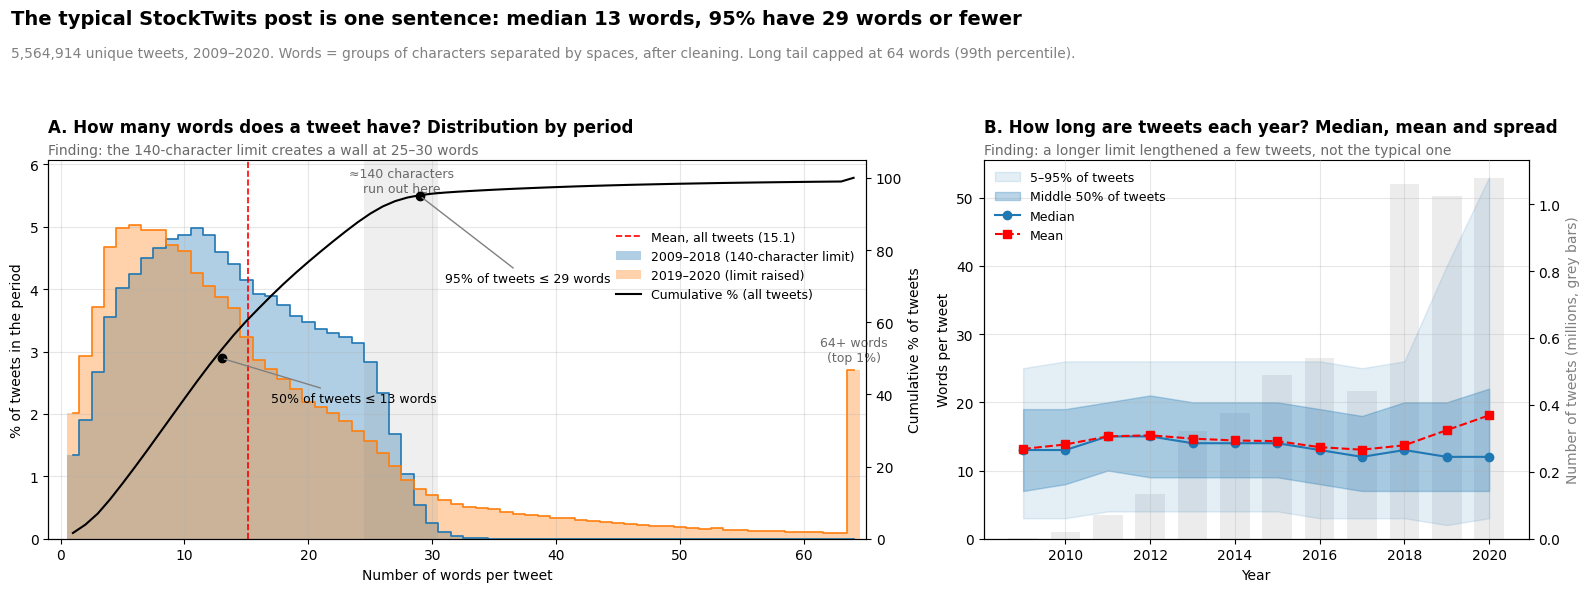

In [ ]:
tweets["datetime"] = pd.to_datetime(tweets["datetime"])
tweets['year'] = tweets['datetime'].dt.year                                   # year of each tweet (skip if you already created it)
CAP = 64                                                                      # tweets longer than 64 words (99th pct) go into the last bar
words = tweets['n_words'].clip(upper=CAP)                                     # word counts with the long tail capped at 64
old = tweets['year'] <= 2018                                                  # True for tweets written under the 140-character limit
periods = {'2009–2018 (140-character limit)': (words[old],  '#1f77b4'),       # old period: its word counts and a blue colour
           '2019–2020 (limit raised)':        (words[~old], '#ff7f0e')}       # new period (~ means "not"): word counts and orange
median, mean = tweets['n_words'].median(), tweets['n_words'].mean()           # median and mean words per tweet (for title and lines)
p95 = tweets['n_words'].quantile(0.95)                                        # 95th percentile: 95% of tweets have this many words or fewer

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1.5, 1]})  # one figure, two panels, left panel wider

# ---------- Panel A: distribution ----------
top_bar = 0                                                                   # will hold the height of the tallest "64+" bar (to place its label)
for label, (w, color) in periods.items():                                     # loop over the two periods
    share = w.value_counts(normalize=True).sort_index() * 100                 # % of the period's tweets for each word count, sorted by word count
    top_bar = max(top_bar, share.get(CAP, 0))                                 # remember the tallest 64+ bar
    ax1.bar(share.index, share.values, width=1, color=color, alpha=0.35, label=label)  # semi-transparent bars so both periods are visible
    ax1.step(share.index, share.values, where='mid', color=color, lw=1.2)    # outline on top of the bars so the shape stands out
ax1.set_ylim(0, ax1.get_ylim()[1] * 1.15)                                     # 15% extra room at the top for labels
ax1.axvspan(24.5, 30.5, color='grey', alpha=0.12, lw=0)                       # grey shaded band where 140 characters run out
ax1.text(27.5, ax1.get_ylim()[1] * 0.98, '≈140 characters\nrun out here', ha='center', va='top', fontsize=9, color='dimgrey')  # label the band
ax1.axvline(mean, color='red', ls='--', lw=1.2, label=f'Mean, all tweets ({mean:.1f})')  # dashed red vertical line at the mean
ax1.annotate('64+ words\n(top 1%)', xy=(CAP, top_bar + 0.15), ha='center', fontsize=9, color='dimgrey')  # explain the tall last bar
ax1.set(xlabel='Number of words per tweet', ylabel='% of tweets in the period', xlim=(-1, CAP + 1))  # axis titles and x range

ax1b = ax1.twinx()                                                            # second y-axis on the right, sharing the same x-axis
cum = words.value_counts(normalize=True).sort_index().cumsum() * 100          # cumulative %: share of tweets with this many words or fewer
ax1b.plot(cum.index, cum.values, color='black', lw=1.5, label='Cumulative % (all tweets)')  # draw the cumulative line
for p, v, dx, dy in [(50, median, 4, -12), (95, p95, 2, -24)]:                # two points to highlight: (percent, words, label offsets x/y)
    ax1b.plot(v, p, 'o', color='black')                                       # black dot on the cumulative line
    ax1b.annotate(f'{p}% of tweets ≤ {v:.0f} words', xy=(v, p), xytext=(v + dx, p + dy), fontsize=9,  # text placed next to the dot
                  arrowprops=dict(arrowstyle='-', color='grey'))              # thin grey line connecting text and dot
ax1b.set(ylim=(0, 105), ylabel='Cumulative % of tweets')                     # right axis from 0 to 105% and its title
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax1b.get_legend_handles_labels()  # collect legend entries from both axes
ax1.legend(h1 + h2, l1 + l2, loc='center right', bbox_to_anchor=(1, 0.72), fontsize=9, frameon=False)  # one combined legend, no box
ax1.set_title('A. How many words does a tweet have? Distribution by period',  # NEW: bold title saying what the panel shows
              loc='left', fontsize=12, fontweight='bold', pad=20)             # left-aligned, with space below it for the finding
ax1.text(0, 1.015, 'Finding: the 140-character limit creates a wall at 25–30 words',  # NEW: grey line with the finding, under the title
         transform=ax1.transAxes, fontsize=10, color='dimgrey')              # position measured in panel units (0 = left edge, 1 = top edge)

# ---------- Panel B: by year ----------
q = tweets.groupby('year')['n_words'].quantile([0.05, 0.25, 0.5, 0.75, 0.95]).unstack()  # per year: 5th, 25th, 50th, 75th, 95th percentile (one column each)
yearly_mean = tweets.groupby('year')['n_words'].mean()                        # per year: mean words per tweet
n_tweets = tweets.groupby('year').size() / 1e6                                # per year: number of tweets, in millions

ax2b = ax2.twinx()                                                            # second y-axis on the right for the tweet counts
ax2b.bar(n_tweets.index, n_tweets.values, color='grey', alpha=0.15, width=0.7)  # light grey bars: tweets per year, in the background
ax2b.set_ylabel('Number of tweets (millions, grey bars)', color='grey')       # title of the right axis
ax2.set_zorder(ax2b.get_zorder() + 1); ax2.patch.set_visible(False)           # draw the main panel in front of the grey bars

ax2.fill_between(q.index, q[0.05], q[0.95], color='#1f77b4', alpha=0.12, label='5–95% of tweets')  # light band: 90% of tweets lie inside
ax2.fill_between(q.index, q[0.25], q[0.75], color='#1f77b4', alpha=0.30, label='Middle 50% of tweets')  # darker band: middle half of tweets
ax2.plot(q.index, q[0.5], 'o-', color='#1f77b4', label='Median')              # median per year: line with dots
ax2.plot(yearly_mean.index, yearly_mean.values, 's--', color='red', label='Mean')  # mean per year: dashed red line with squares
ax2.set(xlabel='Year', ylabel='Words per tweet', ylim=(0, None))              # axis titles; y starts at 0
ax2.legend(loc='upper left', fontsize=9, frameon=False)                       # legend in the empty top-left corner
ax2.set_title('B. How long are tweets each year? Median, mean and spread',    # NEW: bold title saying what the panel shows
              loc='left', fontsize=12, fontweight='bold', pad=20)             # left-aligned, with space below it for the finding
ax2.text(0, 1.015, 'Finding: a longer limit lengthened a few tweets, not the typical one',  # NEW: grey line with the finding
         transform=ax2.transAxes, fontsize=10, color='dimgrey')              # same position as in panel A

for ax in (ax1, ax2):                                                         # same styling for both panels
    ax.grid(alpha=0.3); ax.spines[['top']].set_visible(False)                 # light grid, remove the top border line

fig.suptitle(f'The typical StockTwits post is one sentence: median {median:.0f} words, 95% have {p95:.0f} words or fewer',  # headline = the finding
             x=0.01, ha='left', fontsize=14, fontweight='bold')              # left-aligned, bold
fig.text(0.01, 0.9, f'{len(tweets):,} unique tweets, {tweets["year"].min()}–{tweets["year"].max()}. '  # CHANGED (0.905 -> 0.9): grey subtitle...
         f'Words = groups of characters separated by spaces, after cleaning. Long tail capped at {CAP} words (99th percentile).',  # ...and definitions
         fontsize=10, color='grey')                                           # smaller and grey, like the professor's slides
fig.tight_layout(rect=(0, 0, 1, 0.88))                                        # CHANGED (0.9 -> 0.88): a bit more room at the top for the new titles
plt.show()                                                                    # display the figure

***Panel A (left)**: The two periods look very different.*
- **2009–2018 (blue):** tweets peak around 10–11 words, then fall off gradually. Around 27–30 words they collapse, and beyond 31 words there's almost nothing. That's the 140-character wall.
- **2019–2020 (orange):** there's a thin tail of long tweets stretching past 60 words, and 2.7% of tweets have 64 or more. The peak sits further left, indicating that while the platform increased the character limit, most people preferred to keep to short posts, perhaps because the platform attracted more casual retail users posting quick reactions.
- The **black cumulative line** confirms the headline: half of all tweets have 13 words or fewer, and 95% have 29 or fewer.

***Panel B (right)**: The median is very stable.*
- The median stays at 13–15 words from 2009 to 2016, then drifts down to 12 from 2017 onwards, while the middle 50% band hardly moves (roughly 7–20 words the whole time).
- What changes is the top percentiles. The 95th percentile stays at 25 words until 2018, then jumps to about 40 in 2019 and 53 in 2020. The longer post allowance skews the mean, which can be misleading.
- The grey bars show activity growing to about a million tweets a year from 2018 onwards. With 2020 data only including 6 months, we see that there has been a surge in retail trading, aligned with the boom during Covid.

______________

### ***Step 1.5:*** *Describe the Sample*

In [ ]:
# Numbers for the summary
n_tweets = len(tweets)                                                        # number of unique tweets
n_stocks = tweet_stock['symbol'].nunique()                                    # number of different stocks
per_user = tweets.groupby('user').size().sort_values(ascending=False)         # tweets per user, most active user first
n_users  = len(per_user)                                                      # number of different users
share_users  = np.arange(1, n_users + 1) / n_users * 100                      # x-axis of panel C: 0.001%, 0.002% ... 100% of users
share_tweets = per_user.cumsum().values / n_tweets * 100                      # y-axis of panel C: % of tweets written by those users
top1 = share_tweets[int(n_users * 0.01) - 1]                                  # % of tweets written by the top 1% of users

summary = pd.Series({                                                         # a small table: one line per statistic
    'Unique tweets':                      f'{n_tweets:,}',                    # formatted with thousands separators
    'Stocks':                             n_stocks,
    'Users':                              f'{n_users:,}',
    'First tweet':                        tweets['datetime'].min().date(),    # earliest date (.date() drops the time)
    'Last tweet':                         tweets['datetime'].max().date(),    # latest date
    'Tweets per user (mean)':             f'{n_tweets / n_users:.1f}',        # average tweets per user
    'Tweets per user (median)':           f'{per_user.median():.0f}',         # the "typical" user
    'Users with a single tweet':          f'{(per_user == 1).mean():.1%}',    # share of users who posted only once
    'Share of tweets by top 1% of users': f'{top1:.1f}%',                     # concentration measure
})
display(summary.to_frame('value'))                                            # show it as a one-column table

,value
Unique tweets,"5,564,914"
Stocks,25
Users,"135,835"
First tweet,2009-07-10
Last tweet,2020-07-24
Tweets per user (mean),41.0
Tweets per user (median),3
Users with a single tweet,31.6%
Share of tweets by top 1% of users,46.7%


The data includes 5,564,914 unique tweets about 25 stocks, written by 135,835 different users over 11 years. On average, one user posted 41 tweets, with the median being right skewed, standing at 3 tweets. This can be explained by the extremely active users pulling the average up. 31.6% of users posted just once, meanwhile the top 1% of users (1,360 individuals) wrote 46.7% of all the tweets in the dataset. Thus, there is not a clear portrait of the "average StockTwits user".

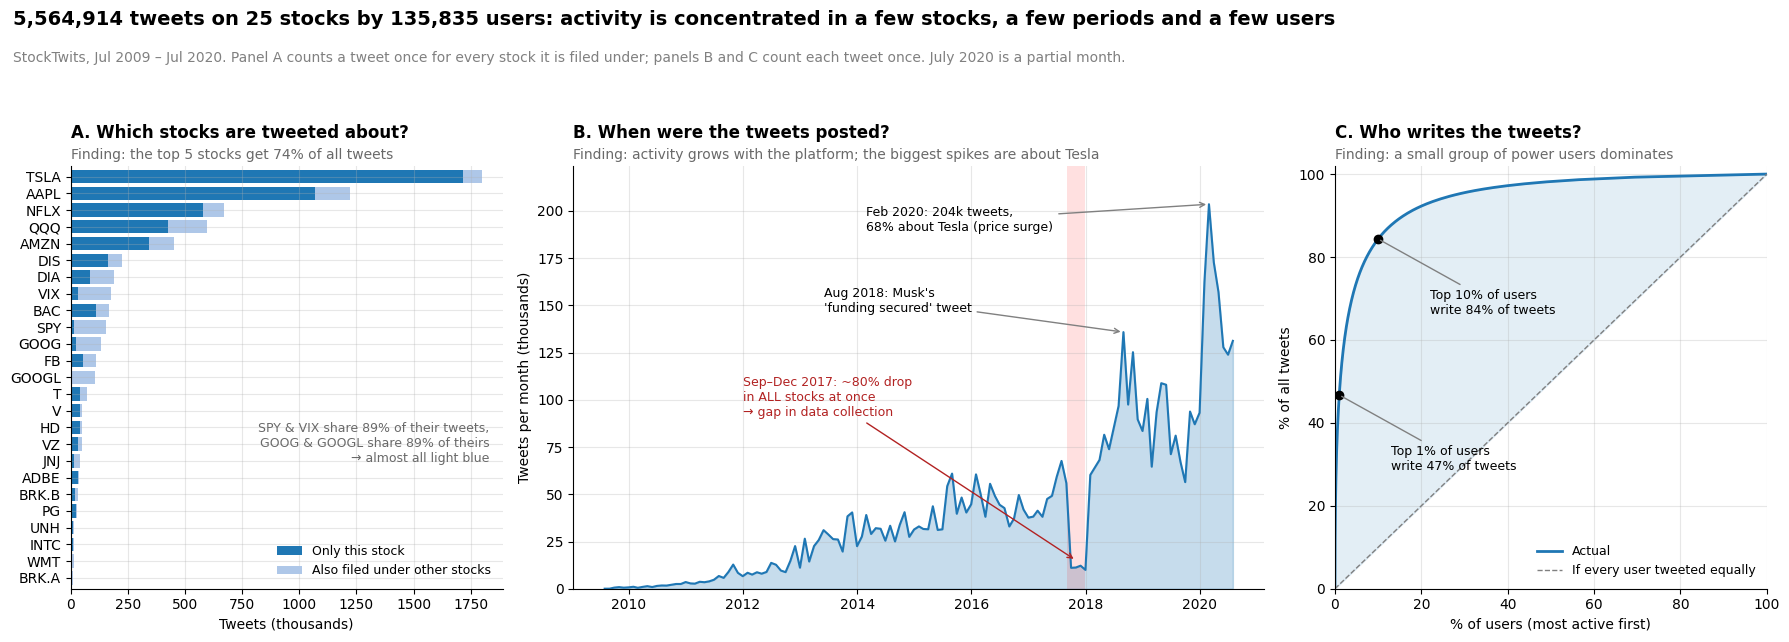

In [ ]:
#  Figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6.5), gridspec_kw={'width_ratios': [1, 1.6, 1]})  # 3 panels, middle one wider

# Panel A: tweets per stock, split into single-stock and cross-listed tweets
per_stock = (tweet_stock.merge(tweets[['message_id', 'n_stocks']], on='message_id')   # add n_stocks to every tweet-stock pair
                        .assign(kind=lambda d: np.where(d['n_stocks'] == 1, 'Only this stock', 'Also filed under other stocks'))  # label each pair
                        .groupby(['symbol', 'kind']).size().unstack(fill_value=0) / 1e3)  # count per stock and label, one column per label, in thousands
per_stock = per_stock.loc[per_stock.sum(axis=1).sort_values().index]          # sort stocks by total tweets (biggest ends up on top)
per_stock[['Only this stock', 'Also filed under other stocks']].plot.barh(stacked=True, ax=ax1, width=0.8,  # horizontal stacked bars
                                                                          color=['#1f77b4', '#aec7e8'])     # dark blue + light blue
top5 = per_stock.sum(axis=1).nlargest(5).sum() / per_stock.values.sum() * 100 # % of all tweet-stock pairs going to the 5 biggest stocks
ax1.set(xlabel='Tweets (thousands)', ylabel='')                               # axis titles
ax1.legend(frameon=False, fontsize=9, loc='lower right')                      # legend without a box, bottom right
ax1.text(0.97, 0.3, 'SPY & VIX share 89% of their tweets,\nGOOG & GOOGL share 89% of theirs\n→ almost all light blue', transform=ax1.transAxes,  # note on the overlapping files
         ha='right', fontsize=9, color='dimgrey')                             # right-aligned, grey
ax1.set_title('A. Which stocks are tweeted about?', loc='left', fontsize=12, fontweight='bold', pad=20)  # bold panel title
ax1.text(0, 1.015, f'Finding: the top 5 stocks get {top5:.0f}% of all tweets', transform=ax1.transAxes, fontsize=10, color='dimgrey')  # finding line

# Panel B: tweets per month, with the key events annotated
monthly = tweets.set_index('datetime').resample('ME').size() / 1e3            # count tweets per calendar month ('ME' = month end), in thousands
ax2.fill_between(monthly.index, monthly.values, color='#1f77b4', alpha=0.25)  # light blue area under the line
ax2.plot(monthly.index, monthly.values, color='#1f77b4', lw=1.5)              # the line itself
peak = monthly.idxmax()                                                       # the month with the most tweets
tsla_ids = tweet_stock.loc[tweet_stock['symbol'] == 'TSLA', 'message_id']     # IDs of all tweets filed under TSLA
in_peak = (tweets['datetime'].dt.year == peak.year) & (tweets['datetime'].dt.month == peak.month)  # True for tweets posted in the peak month
tsla_share = tweets.loc[in_peak, 'message_id'].isin(tsla_ids).mean()          # share of the peak month's tweets that are about Tesla
ax2.annotate(f'{peak:%b %Y}: {monthly.max():.0f}k tweets,\n{tsla_share:.0%} about Tesla (price surge)', xy=(peak, monthly.max()),  # label pointing at the peak
             xytext=(peak - pd.DateOffset(years=6), monthly.max() * 0.93), fontsize=9,  # text placed 6 years to the left
             arrowprops=dict(arrowstyle='->', color='grey'))                  # grey arrow from text to point
aug18 = pd.Timestamp('2018-08-31', tz='UTC')                                  # the August 2018 month (month-end date, like the resampled index)
ax2.annotate("Aug 2018: Musk's\n'funding secured' tweet", xy=(aug18, monthly[aug18]),  # label pointing at the Aug 2018 spike
             xytext=(pd.Timestamp('2013-06-01', tz='UTC'), monthly.max() * 0.72), fontsize=9,  # where the text goes
             arrowprops=dict(arrowstyle='->', color='grey'))                  # grey arrow
ax2.axvspan(pd.Timestamp('2017-09-01', tz='UTC'), pd.Timestamp('2017-12-31', tz='UTC'), color='red', alpha=0.12, lw=0)  # red band over the data gap
ax2.annotate('Sep–Dec 2017: ~80% drop\nin ALL stocks at once\n→ gap in data collection', xy=(pd.Timestamp('2017-11-01', tz='UTC'), 15),  # explain the gap
             xytext=(pd.Timestamp('2012-01-01', tz='UTC'), monthly.max() * 0.45), fontsize=9, color='firebrick',  # red text
             arrowprops=dict(arrowstyle='->', color='firebrick'))             # red arrow
ax2.set(xlabel='', ylabel='Tweets per month (thousands)', ylim=(0, monthly.max() * 1.1))  # axis titles, 10% room above the peak
ax2.set_title('B. When were the tweets posted?', loc='left', fontsize=12, fontweight='bold', pad=20)  # bold panel title
ax2.text(0, 1.015, 'Finding: activity grows with the platform; the biggest spikes are about Tesla', transform=ax2.transAxes, fontsize=10, color='dimgrey')  # finding line

# Panel C: how concentrated is activity across users?
ax3.plot(share_users, share_tweets, color='#1f77b4', lw=2, label='Actual')    # the concentration curve
ax3.plot([0, 100], [0, 100], color='grey', ls='--', lw=1, label='If every user tweeted equally')  # the diagonal = perfect equality
ax3.fill_between(share_users, share_users, share_tweets, color='#1f77b4', alpha=0.12)  # shade the gap between the two (bigger = more concentrated)
for p in [1, 10]:                                                             # highlight the top 1% and top 10% of users
    y = share_tweets[int(n_users * p / 100) - 1]                              # % of tweets written by the top p% of users
    ax3.plot(p, y, 'o', color='black')                                        # black dot on the curve
    ax3.annotate(f'Top {p}% of users\nwrite {y:.0f}% of tweets', xy=(p, y), xytext=(p + 12, y - 18), fontsize=9,  # label next to the dot
                 arrowprops=dict(arrowstyle='-', color='grey'))               # thin grey connector line
ax3.set(xlabel='% of users (most active first)', ylabel='% of all tweets', xlim=(0, 100), ylim=(0, 102))  # axis titles and ranges
ax3.legend(frameon=False, fontsize=9, loc='lower right')                      # legend bottom right
ax3.set_title('C. Who writes the tweets?', loc='left', fontsize=12, fontweight='bold', pad=20)  # bold panel title
ax3.text(0, 1.015, 'Finding: a small group of power users dominates', transform=ax3.transAxes, fontsize=10, color='dimgrey')  # finding line

for ax in (ax1, ax2, ax3):                                                    # same styling for all panels
    ax.grid(alpha=0.3); ax.spines[['top', 'right']].set_visible(False)        # light grid, remove top and right border lines

fig.suptitle(f'{n_tweets:,} tweets on {n_stocks} stocks by {n_users:,} users: '  # headline built from the real numbers...
             f'activity is concentrated in a few stocks, a few periods and a few users',  # ...plus the overall finding
             x=0.01, ha='left', fontsize=14, fontweight='bold')              # left-aligned, bold
fig.text(0.01, 0.9, f'StockTwits, {tweets["datetime"].min():%b %Y} – {tweets["datetime"].max():%b %Y}. '  # grey subtitle: period...
         'Panel A counts a tweet once for every stock it is filed under; panels B and C count each tweet once. July 2020 is a partial month.',  # ...and how things are counted
         fontsize=10, color='grey')
fig.tight_layout(rect=(0, 0, 1, 0.88))                                        # arrange panels, leave room at the top for the titles
plt.show()                                                                    # display

**Panel A : Which Stocks were tweeted about**
- 74% of all tweets are concentrated in a handful of stocks and indexes: TSLA, AAPL, NFLX, QQQ and AMZN.
    - 1.8 million tweets mentioned TSLA, which is more than the 20 smallest stocks combined.
    - Stable large cap and mega cap companies like Walmart, UnitedHealth, Intel and Berkshire Hathaway got almost no attention.

Thus, like in most media platforms, what excites individuals to share their opinions is the excitement around the product, the development or growth of the company, or swift changes leading to bullish or bearish sentiment.

The light blue parts also reveal data problems. `SPY` and `VIX` are almost entirely light blue because 89% of their tweets are the same. The same holds for `GOOG` and `GOOGL`, which are two share classes of the same company (Alphabet).

**Panel B: When were the tweets posted?**

The line graph shows how many tweets were posted each month.

- ***Growth.*** As mentioned earlier, we see a steady growth trend in the activity on the platform. This mostly reflects StockTwits itself becoming popular, not investors changing behaviour. So when comparing across years, we should look at shares and averages, not raw counts.
- ***Spikes.*** The activity spikes follow events around particular companies rather than sentiment spike about the whole market. When Covid disrupted the economy, we see a spike in tweets about the indexes (QQQ, SPY) and the "fear gauge" (VIX) double.

The lack of data from September to December 2017 is purely an issue with the raw data, potentially caused by either a loss of data when scraping/downloading or changes in privacy/governance during those times, leading to the inability to access the publications. Any analysis over time, for example sentiment by month, must treat late 2017 as missing data, not as "people stopped tweeting".

**Panel C: Who writes the tweets?**

On the graph, users are sorted from most to least active. The grey diagonal is what it would look like if everyone tweeted the same amount (10% of users would write 10% of tweets). The blue curve is the actual usage. The further it bulges above the diagonal, the more concentrated activity is.

Thus, we conclude that activity is unequal. The curve shoots up almost vertically at the start and then flattens. This trend matters because when we compute "average sentiment", we're mostly measuring the opinion of a few thousand very active accounts, not of the typical platform user. It is worth seeing if giving users the same weight will support analysis and modelling or whether it is best to remove the most active accounts.

________

### *Now before moving on to further analysing the data and working on sentiment analysis, we test which model performs best on the financial tweet data we have on hand.*

# 2. Choosing a sentiment model: benchmark and validation

In [ ]:
BASE = 'https://raw.githubusercontent.com/adlnlp/StockEmotions/main/tweet/'

# Large sample: all 10,000 messages (to our knowledge, none of the BERT models was trained on them; the LLM may have seen this public dataset during pre-training), so all can be used as test data
se_all = pd.concat([pd.read_csv(BASE + f'{split}_stockemo.csv') for split in ['train', 'val', 'test']],
                   ignore_index=True)
se_all['clean'] = clean_text(se_all['original'])                  # same light cleaning as our own tweets
se_all['y'] = (se_all['senti_label'] == 'bullish').astype(int)    # 1 = bullish, 0 = bearish

# Small sample for the LLM: the official 1,000-message test set = the last 1,000 rows.
se_sub = se_all.iloc[-1000:].copy()

print(f'Large sample: {len(se_all):,} messages |', se_all['senti_label'].value_counts(normalize=True).round(3).to_dict())
print(f'Small sample: {len(se_sub):,} messages |', se_sub['senti_label'].value_counts(normalize=True).round(3).to_dict())

Large sample: 10,000 messages | {'bullish': 0.547, 'bearish': 0.453}
Small sample: 1,000 messages | {'bullish': 0.555, 'bearish': 0.445}


### ***Step 3.1:*** *BERT Model Setup, Sentiment Classification and Evaluation Metrics*
This block sets up three pre-trained BERT sentiment models and standardises their different label formats into bullish, bearish and neutral predictions. It then evaluates each model using AUC (with a 95% confidence interval), macro F1-score, balanced accuracy and the proportion of neutral predictions.

In [ ]:
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'   # use the Mac GPU if available
print('Device:', DEVICE)

BERT_MODELS = {
    'Twitter-RoBERTa': 'cardiffnlp/twitter-roberta-base-sentiment-latest',   # knows Twitter, not finance
    'FinBERT':         'ProsusAI/finbert',                                   # knows finance, not Twitter
    'FinTwitBERT':     'StephanAkkerman/FinTwitBERT-sentiment',              # knows both
}

# Each model names its classes differently, we need one common vocabulary
LABEL_MAP = {'positive': 'pos', 'bullish': 'pos',
             'negative': 'neg', 'bearish': 'neg',
             'neutral':  'neu'}

def run_model(model_path, texts, batch_size=32):
    """Return, for each text, the probability of each class, a score P(pos) - P(neg), and the predicted label."""
    clf = pipeline('text-classification', model=model_path, top_k=None, device=DEVICE)
    outputs = clf(list(texts), batch_size=batch_size, truncation=True, max_length=128)
    probs = pd.DataFrame([{LABEL_MAP[d['label'].lower()]: d['score'] for d in out} for out in outputs],
                         index=texts.index)
    probs['score'] = probs['pos'] - probs['neg']                  # continuous score from -1 (bearish) to +1 (bullish)
    probs['label'] = probs[['pos', 'neg', 'neu']].idxmax(axis=1)  # class with the highest probability
    return probs

def auc_with_ci(y, score, n_boot=1000, seed=42):
    """AUC and its 95% confidence interval by bootstrap (resample the messages with replacement)."""
    rng = np.random.default_rng(seed)
    y, score = np.asarray(y), np.asarray(score)
    boots = [roc_auc_score(y[idx], score[idx])
             for idx in (rng.integers(0, len(y), len(y)) for _ in range(n_boot))]
    return roc_auc_score(y, score), np.percentile(boots, 2.5), np.percentile(boots, 97.5)

def evaluate(y, p):
    """All our metrics for one model, from its predictions p (needs a 'score' column; 'label' is optional)."""
    auc, low, high = auc_with_ci(y, p['score'])
    direction = (p['score'] > 0).astype(int)                      # ignore neutral: is the model leaning bullish or bearish?
    return {
        'AUC': auc, 'AUC low 95%': low, 'AUC high 95%': high,
        'F1 macro (bull vs bear)': f1_score(y, direction, average='macro'),
        'Balanced accuracy':       balanced_accuracy_score(y, direction),
        'Share predicted neutral': (p['label'] == 'neu').mean() if 'label' in p else np.nan,
    }

Device: cpu


Generate sentiment predictions for all 10,000 StockEmotions messages with each BERT model, or reload saved predictions if they already exist.
Then verify that every prediction remains correctly aligned with its original tweet, preventing errors in the later evaluation.

In [ ]:
preds = {}
for name, path in BERT_MODELS.items():
    file = f'preds_stockemo_{name}.csv'
    if os.path.exists(file):
        preds[name] = pd.read_csv(file, index_col=0)
        print(f'{name}: reloaded from {file}')
    else:
        start = time.time()
        preds[name] = run_model(path, se_all['clean'])        # ~3 min per model on a laptop
        preds[name].to_csv(file)                               # save immediately: never recompute again
        print(f'{name}: computed in {time.time() - start:.0f}s and saved to {file}')

# Safety check: predictions must line up with the messages, row by row
for name, p in preds.items():
    assert p.index.equals(se_all.index), f'{name}: predictions do not match the 10,000 messages'
print('All predictions aligned with the 10,000 messages')

Twitter-RoBERTa: reloaded from preds_stockemo_Twitter-RoBERTa.csv
FinBERT: reloaded from preds_stockemo_FinBERT.csv
FinTwitBERT: reloaded from preds_stockemo_FinTwitBERT.csv
All predictions aligned with the 10,000 messages


Ask for a Groq API key only when one has not already been provided.

In [ ]:
from getpass import getpass

# The key is only needed to compute new LLM scores; saved scores are reloaded without it.
# Press Enter to skip if preds_stockemo_llm.csv already exists.
if not os.environ.get('GROQ_API_KEY'):
    os.environ['GROQ_API_KEY'] = getpass('Paste your Groq API key (or press Enter to skip): ').strip()
print('Groq key provided:', bool(os.environ['GROQ_API_KEY']))

Paste your Groq API key (or press Enter to skip): ··········
Groq key provided: True


Connects to Groq’s API and ask the gpt-oss-120b LLM to score each StockTwits message from −1 (very bearish) to +1 (very bullish).

In [ ]:
client = OpenAI(api_key=os.environ.get('GROQ_API_KEY') or 'no-key',   # a placeholder is enough when scores are reloaded
                base_url='https://api.groq.com/openai/v1')

PROMPT = """You are a financial analyst. For each StockTwits message below, rate the author's sentiment toward the stock
from -1 (very bearish) to +1 (very bullish). Use 0 for neutral or no opinion.
Return only JSON: {"scores": [one number per message, in the same order]}

Messages:
"""

def llm_scores(texts, batch_size=20, pause=12):
    """Score texts with gpt-oss-120b, 20 messages per request to save the free quota."""
    texts, scores = list(texts), []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        numbered = '\n'.join(f'{j + 1}. {t}' for j, t in enumerate(batch))
        response = client.chat.completions.create(
            model='openai/gpt-oss-120b',
            messages=[{'role': 'user', 'content': PROMPT + numbered}],
            temperature=0,                          # same answer every time -> reproducible
            reasoning_effort='low',                 # less hidden "thinking" -> fewer tokens used
            response_format={'type': 'json_object'},
        )
        batch_scores = json.loads(response.choices[0].message.content)['scores']
        if len(batch_scores) != len(batch):         # the model skipped or merged a message -> mark the batch as missing
            batch_scores = [float('nan')] * len(batch)
        scores += batch_scores
        time.sleep(pause)                           # free tier: 8,000 tokens per minute
    return scores

In [ ]:
if os.path.exists('preds_stockemo_llm.csv'):
    llm = pd.read_csv('preds_stockemo_llm.csv')
    assert (llm['id'].values == se_sub['id'].values).all(), 'LLM file does not match the small sample'
    se_sub['llm_score'] = llm['llm_score'].values             # already computed: reload in seconds
    print('LLM: reloaded from preds_stockemo_llm.csv')
else:
    se_sub['llm_score'] = llm_scores(se_sub['clean'])          # ~12 min, ~50 Groq requests
    se_sub[['id', 'senti_label', 'clean', 'llm_score']].to_csv('preds_stockemo_llm.csv', index=False)
    print('LLM: computed and saved to preds_stockemo_llm.csv')

# A few batches can fail (the model skipped a message): those messages are dropped for ALL models, to compare on the same set
valid = se_sub['llm_score'].notna()
y_sub = se_sub.loc[valid, 'y']
print(f'Messages scored by the LLM: {valid.sum()} / {len(se_sub)}')

LLM: reloaded from preds_stockemo_llm.csv
Messages scored by the LLM: 980 / 1000


### ***Step 3.2:*** *Results*

Evaluate and compare the models’ sentiment predictions against the true bullish/bearish labels.
- Table 1 evaluates the three BERT models on the full 10,000-message external dataset.
- Table 2 evaluates all four models on the exact same 980 messages that received valid LLM scores, making the comparison fair.

In [ ]:

# Table 1: the three BERT models on all 10,000 messages
results_all = pd.DataFrame({name: evaluate(se_all['y'], p) for name, p in preds.items()}).T
print(f'BERT models on all {len(se_all):,} messages')
display(results_all.sort_values('AUC', ascending=False).round(3))

# Table 2: all four models on the same messages the LLM scored
results_sub = {name: evaluate(y_sub, p.loc[y_sub.index]) for name, p in preds.items()}
results_sub['gpt-oss-120b (LLM)'] = evaluate(y_sub, pd.DataFrame({'score': se_sub.loc[valid, 'llm_score']}))
print(f'\nAll four models on the same {len(y_sub)} messages')
display(pd.DataFrame(results_sub).T.sort_values('AUC', ascending=False).round(3))

BERT models on all 10,000 messages


,AUC,AUC low 95%,AUC high 95%,F1 macro (bull vs bear),Balanced accuracy,Share predicted neutral
FinTwitBERT,0.757,0.747,0.766,0.686,0.687,0.046
Twitter-RoBERTa,0.700,0.689,0.710,0.632,0.632,0.230
FinBERT,0.633,0.622,0.643,0.592,0.592,0.802



All four models on the same 980 messages


,AUC,AUC low 95%,AUC high 95%,F1 macro (bull vs bear),Balanced accuracy,Share predicted neutral
gpt-oss-120b (LLM),0.838,0.812,0.863,0.783,0.790,NaN
FinTwitBERT,0.766,0.734,0.793,0.692,0.695,0.039
Twitter-RoBERTa,0.697,0.664,0.728,0.618,0.618,0.241
FinBERT,0.635,0.600,0.669,0.595,0.595,0.805


### ***Step 3.3:*** *Interpretation*

**FinTwitBERT** is the best BERT model on the full sample
-  AUC = 0.757, macro F1 = 0.686, and balanced accuracy = 0.687.
- Its combination of finance and Twitter training makes it most suitable for StockTwits sentiment.

**Twitter-RoBERTa** is second (AUC = 0.700).
- It understands informal social-media language but is less specialised for finance.

**FinBERT** is weakest (AUC = 0.633) and predicts neutral for 80.2% of messages.
- This suggests that a finance model trained more on formal financial text does not transfer well to short, informal StockTwits messages.

**gpt-oss-120b** performs best overall:
- On the shared 980-message subset : AUC = 0.838, macro F1 = 0.783, balanced accuracy = 0.790.
- It clearly outperforms FinTwitBERT (AUC = 0.766).

FinTwitBERT was the strongest BERT-based baseline, confirming the value of a model trained on both financial and social-media language. However, the LLM achieved the best performance on the common evaluation subset, indicating a stronger ability to interpret nuanced financial sentiment in StockTwits messages.

### ***Step 3.4:*** *Test 1: models vs. the authors' own labels (visual representation)*

This section compares each model’s sentiment predictions with the original bullish and bearish labels assigned by StockEmotions users. It measures both ranking performance (AUC) and whether each model predicts the correct, neutral, or wrong market direction.

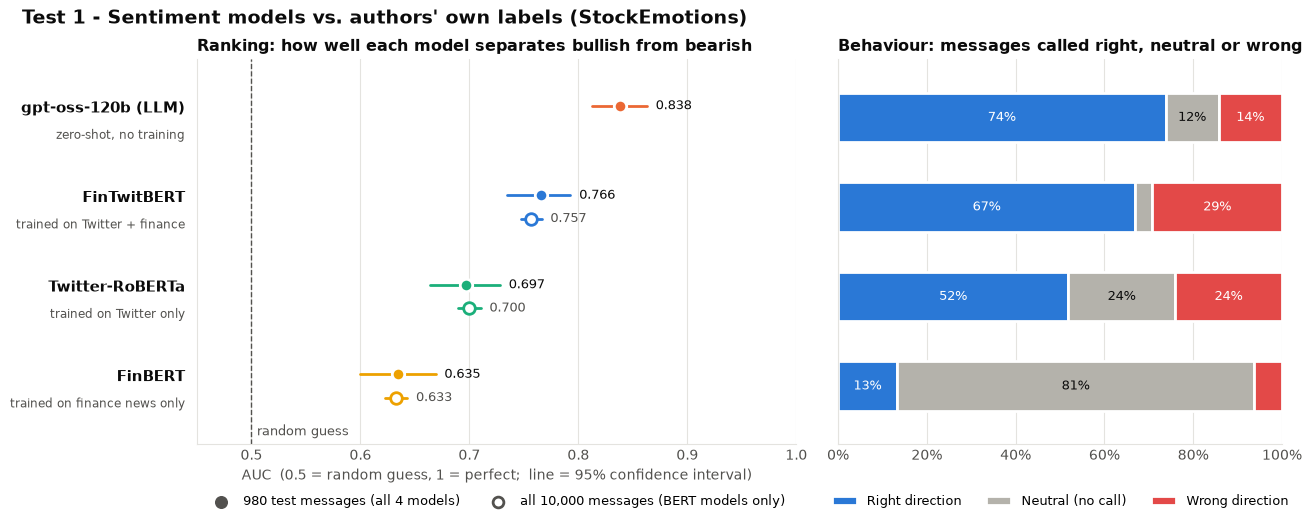

In [ ]:
# ---------- Data: 4 models on the same messages + 3 BERT models on all 10,000 ----------
LLM = 'gpt-oss-120b (LLM)'
MODEL_ORDER = [LLM, 'FinTwitBERT', 'Twitter-RoBERTa', 'FinBERT']       # best to worst
DESCRIPTION = {                                                          # what each model knows
    LLM:               'zero-shot, no training',
    'FinTwitBERT':     'trained on Twitter + finance',
    'Twitter-RoBERTa': 'trained on Twitter only',
    'FinBERT':         'trained on finance news only',
}
COLORS = {LLM: '#eb6834', 'FinTwitBERT': '#2a78d6', 'Twitter-RoBERTa': '#1baf7a', 'FinBERT': '#eda100'}
OUTCOME_COLORS = {'Right direction': '#2a78d6', 'Neutral (no call)': '#b4b2ab', 'Wrong direction': '#e34948'}
INK, INK_2, GRID = '#0b0b0b', '#52514e', '#e4e3df'

idx = y_sub.index                                                        # test messages scored by all 4 models
y_small = y_sub.values
score_small = {m: preds[m].loc[idx, 'score'].values for m in MODEL_ORDER if m != LLM}
score_small[LLM] = se_sub.loc[idx, 'llm_score'].astype(float).values
label_small = {m: preds[m].loc[idx, 'label'].values for m in MODEL_ORDER if m != LLM}
label_small[LLM] = np.select([score_small[LLM] > 0, score_small[LLM] < 0], ['pos', 'neg'], 'neu')

def outcome_shares(y, labels):
    """Share of messages where the model gets the author's direction right, says neutral, or gets it wrong."""
    right = ((labels == 'pos') & (y == 1)) | ((labels == 'neg') & (y == 0))
    neutral = labels == 'neu'
    return {'Right direction': right.mean(), 'Neutral (no call)': neutral.mean(), 'Wrong direction': 1 - right.mean() - neutral.mean()}

# ---------- Figure: one row per model, two panels ----------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True, gridspec_kw={'width_ratios': [1.35, 1], 'wspace': 0.08})
rows = MODEL_ORDER[::-1]                                                 # best model on top

# Left panel: AUC with 95% CI (filled = same test messages for all 4; hollow = all 10,000 messages)
for i, m in enumerate(rows):
    auc, low, high = auc_with_ci(y_small, score_small[m])
    ax1.plot([low, high], [i + 0.13] * 2, color=COLORS[m], linewidth=2, solid_capstyle='round')
    ax1.scatter(auc, i + 0.13, s=80, color=COLORS[m], edgecolor='white', linewidth=2, zorder=3)
    ax1.text(high + 0.008, i + 0.13, f'{auc:.3f}', va='center', color=INK, fontsize=9.5)
    if m != LLM:
        auc, low, high = auc_with_ci(se_all['y'].values, preds[m]['score'].values)
        ax1.plot([low, high], [i - 0.13] * 2, color=COLORS[m], linewidth=2, solid_capstyle='round')
        ax1.scatter(auc, i - 0.13, s=70, facecolor='white', edgecolor=COLORS[m], linewidth=2, zorder=3)
        ax1.text(high + 0.008, i - 0.13, f'{auc:.3f}', va='center', color=INK_2, fontsize=9.5)
ax1.axvline(0.5, color=INK_2, linestyle='--', linewidth=1)
ax1.text(0.505, -0.55, 'random guess', color=INK_2, fontsize=9)
ax1.set(xlim=(0.45, 1.0), ylim=(-0.65, len(rows) - 0.35))
ax1.set_xlabel('AUC  (0.5 = random guess, 1 = perfect;  line = 95% confidence interval)', color=INK_2)
ax1.set_title('Ranking: how well each model separates bullish from bearish', loc='left', fontsize=11.5, fontweight='bold', color=INK)
ax1.scatter([], [], s=70, color=INK_2, label=f'{len(idx):,} test messages (all 4 models)')
ax1.scatter([], [], s=60, facecolor='white', edgecolor=INK_2, linewidth=2, label=f'all {len(se_all):,} messages (BERT models only)')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False, fontsize=9)

# Model names + what they are, as y labels
ax1.set_yticks(range(len(rows)), [''] * len(rows))
trans = blended_transform_factory(ax1.transAxes, ax1.transData)
for i, m in enumerate(rows):
    ax1.text(-0.02, i + 0.1, m, transform=trans, ha='right', va='center', fontsize=11, fontweight='bold', color=INK)
    ax1.text(-0.02, i - 0.2, DESCRIPTION[m], transform=trans, ha='right', va='center', fontsize=8.5, color=INK_2)

# Right panel: what the predictions look like
left = np.zeros(len(rows))
shares = [outcome_shares(y_small, label_small[m]) for m in rows]
for outcome, color in OUTCOME_COLORS.items():
    values = np.array([s[outcome] for s in shares])
    ax2.barh(range(len(rows)), values, left=left, height=0.55, color=color, edgecolor='white', linewidth=2, label=outcome)
    for i, v in enumerate(values):
        if v >= 0.07:                                                    # label only readable segments
            ax2.text(left[i] + v / 2, i, f'{v:.0%}', ha='center', va='center', fontsize=9.5,
                     color=INK if outcome.startswith('Neutral') else 'white')
    left += values
ax2.set_xlim(0, 1)
ax2.xaxis.set_major_formatter(PercentFormatter(1))
ax2.set_title('Behaviour: messages called right, neutral or wrong', loc='left', fontsize=11.5, fontweight='bold', color=INK)
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False, fontsize=9)

for ax in (ax1, ax2):
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color(GRID)
    ax.tick_params(colors=INK_2, length=0)
    ax.grid(axis='x', color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

fig.suptitle('Test 1 - Sentiment models vs. authors\' own labels (StockEmotions)', x=0.0, ha='left', fontsize=13.5, fontweight='bold', color=INK)
plt.show()

Left panel — ranking quality (AUC):
- Higher AUC means the model is better at separating bullish from bearish messages; 0.5 is random guessing.
- The LLM performs best on the shared 980-message sample (AUC 0.838), followed by FinTwitBERT (0.766).
- FinTwitBERT also remains the best BERT model on the full 10,000 messages (0.757, hollow marker), ahead of Twitter-RoBERTa (0.700) and FinBERT (0.633).
- The horizontal lines are 95% confidence intervals: they show the uncertainty around each AUC estimate.

Right panel — prediction behaviour (same 980 messages):
- The LLM gives the correct bullish/bearish direction for 74% of messages, is neutral for 12%, and wrong for 14%.
- FinTwitBERT is correct on 67% and wrong on 29%.
- Twitter-RoBERTa is less accurate (52% correct) and neutral more often (24%).
- FinBERT predicts neutral for 81% of messages, so it misses many useful directional signals despite being finance-trained.

Main takeaway: models need both financial and social-media language knowledge. FinTwitBERT is the strongest specialised BERT baseline, but the LLM is clearly the most accurate model on the directly comparable sample.

________

### ***Step 3.5:*** *Test 2: daily sentiment vs stock returns*


Download adjusted daily closing prices for all stocks and ETFs mentioned in the tweets, using Yahoo Finance from June 2009 to August 2020. Convert prices into daily percentage returns, standardise ticker names and dates, and exclude the VIX because bullish sentiment toward market volatility has a different interpretation.

In [ ]:
import yfinance as yf

YF_NAME = {'BRK.A': 'BRK-A', 'BRK.B': 'BRK-B', 'FB': 'META'}          # Yahoo uses different names for these
symbols = sorted(set(tweet_stock['symbol']) - {'VIX'})                 # VIX is a volatility index: "bullish VIX" means fear

prices = yf.download([YF_NAME.get(s, s) for s in symbols], start='2009-06-01', end='2020-08-01',
                     auto_adjust=True, progress=False)['Close']        # adjusted for dividends and splits
prices = prices.rename(columns={v: k for k, v in YF_NAME.items()})
returns = prices.pct_change(fill_method=None).iloc[1:]
returns.index = pd.to_datetime(returns.index).tz_localize(None)
returns.index.name, returns.columns.name = 'trade_date', 'symbol'
print(f'{returns.shape[1]} stocks/ETFs, {len(returns):,} trading days')

24 stocks/ETFs, 2,812 trading days


#### **Sentiment Analysis**

Assign each tweet to the trading day on which its information could first affect the market, accounting for after-market posts, weekends and public-market closures.

Average FinTwitBERT sentiment by stock and trading day, retain days with at least five tweets, link them to next-day returns, and calculate sentiment relative to each stock’s normal average.

In [ ]:
scores = pd.read_parquet('fintwitbert_scores.parquet', columns=['message_id', 'score'])

# A tweet posted after the 16:00 New York close (or on a weekend) can only react to the NEXT trading session
ny_time = tweets['datetime'].dt.tz_convert('America/New_York')
shifted = (ny_time + pd.Timedelta(hours=8)).dt.tz_localize(None).dt.normalize()   # +8h: after 16:00 -> next day
days = returns.index
pos = days.searchsorted(shifted)                                       # first trading day on or after that date
tweet_day = pd.DataFrame({'message_id': tweets['message_id'],
                          'trade_date': days[np.minimum(pos, len(days) - 1)]})
tweet_day = tweet_day[pos < len(days)]                                 # tweets after our last price date are dropped

daily = (tweet_stock.merge(tweet_day, on='message_id')
                    .merge(scores, on='message_id')
                    .groupby(['symbol', 'trade_date'])
                    .agg(sentiment=('score', 'mean'), n_tweets=('score', 'size'))
                    .reset_index())

ret_long = returns.stack().rename('ret').reset_index()
daily = daily.merge(ret_long, on=['symbol', 'trade_date'])
daily['ret_next'] = daily.groupby('symbol')['ret'].shift(-1)          # next day's return (does sentiment predict?)
daily = daily[daily['n_tweets'] >= 5]                                  # an average of 1-2 tweets is just noise

# FinTwitBERT is tilted towards "bearish" overall, so we use each stock's sentiment relative to its own average
daily['abn_sentiment'] = daily['sentiment'] - daily.groupby('symbol')['sentiment'].transform('mean')
print(f'{len(daily):,} stock-days with at least 5 tweets, {daily["symbol"].nunique()} stocks/ETFs')

40,009 stock-days with at least 5 tweets, 24 stocks/ETFs


In [ ]:
same = daily['abn_sentiment'].corr(daily['ret'], method='spearman')
nxt  = daily['abn_sentiment'].corr(daily['ret_next'], method='spearman')
print(f'Spearman correlation, sentiment vs same-day return: {same:.3f}')
print(f'Spearman correlation, sentiment vs next-day return: {nxt:.3f}')

per_stock = daily.groupby('symbol').apply(lambda d: pd.Series({
    'same_day': d['abn_sentiment'].corr(d['ret'], method='spearman'),
    'next_day': d['abn_sentiment'].corr(d['ret_next'], method='spearman'),
    'stock_days': len(d)}), include_groups=False)
per_stock.sort_values('same_day', ascending=False).round(3)

Spearman correlation, sentiment vs same-day return: 0.265
Spearman correlation, sentiment vs next-day return: -0.003


,same_day,next_day,stock_days
symbol,,,
TSLA,0.451,0.000,2127.0
NFLX,0.444,0.035,2568.0
AAPL,0.420,0.022,2584.0
AMZN,0.390,-0.010,2510.0
GOOG,0.355,0.036,1607.0
GOOGL,0.351,0.039,1371.0
QQQ,0.333,-0.042,2351.0
DIS,0.312,0.013,1956.0
V,0.258,-0.059,1490.0


This result shows that StockTwits sentiment is associated with returns already occurring on the same trading day, but has essentially no power to predict the next day’s return.

- Same-day Spearman correlation = 0.265: a modest positive relationship. More bullish-than-usual sentiment tends to coincide with higher same-day stock returns.
- Next-day Spearman correlation = −0.003: effectively zero. Once the trading day is over, the measured sentiment contains no meaningful directional signal for tomorrow’s return.

The pattern is consistent across many major stocks: same-day correlations are strongest for TSLA (0.451), NFLX (0.444), AAPL (0.420), and AMZN (0.390), while their next-day correlations remain close to zero.
- This likely means that tweets and market moves react to the same news and information during the day, rather than sentiment causing future returns.

Important: correlation does not establish causality, this evidence supports contemporaneous association, not a profitable predictive trading signal.

> **Note:** `ret_next` is the return on the stock's next day with posts, which for thinly discussed stocks (and across the Sep–Dec 2017 data gap) can be later than the next trading day; results for heavily discussed stocks are unaffected.

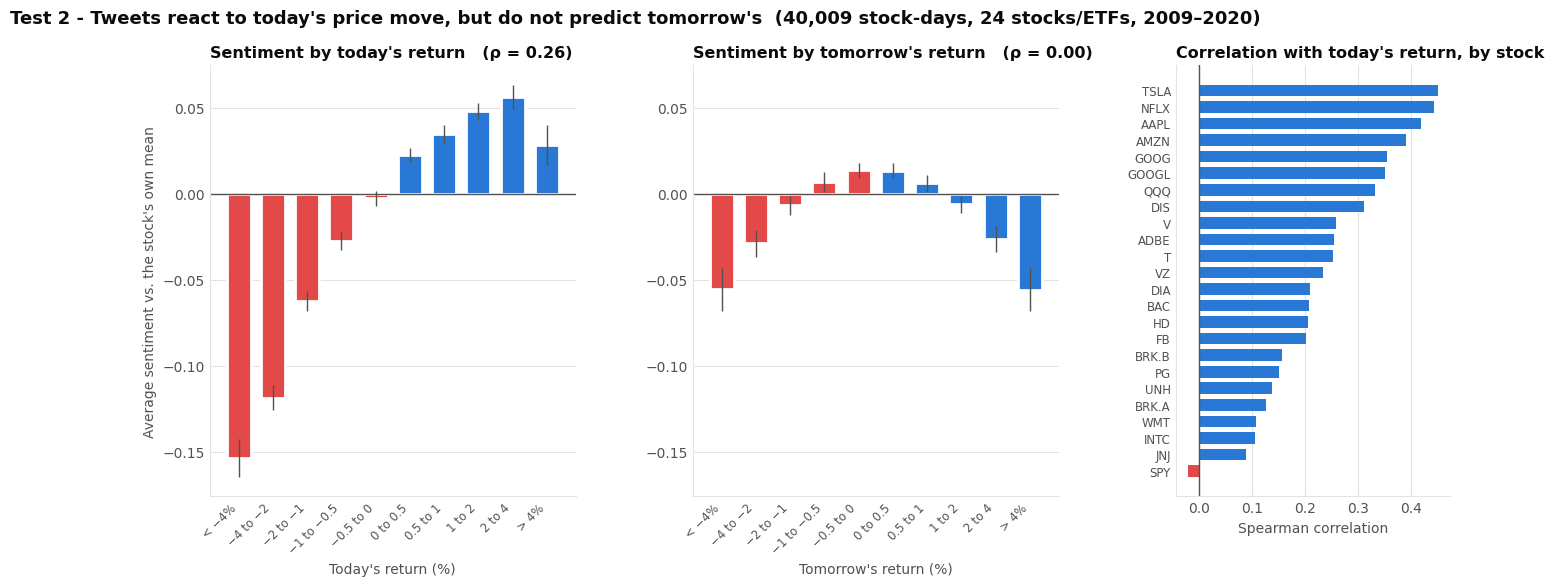

In [ ]:
UP, DOWN = '#2a78d6', '#e34948'                                        # rise = blue, fall = red
INK, INK_2, GRID = '#0b0b0b', '#52514e', '#e4e3df'

# 10 return buckets with round limits, easier to read than quantiles
EDGES  = [-np.inf, -0.04, -0.02, -0.01, -0.005, 0, 0.005, 0.01, 0.02, 0.04, np.inf]
LABELS = ['< −4%', '−4 to −2', '−2 to −1', '−1 to −0.5', '−0.5 to 0', '0 to 0.5', '0.5 to 1', '1 to 2', '2 to 4', '> 4%']

def by_bucket(ret_col):
    """Average abnormal sentiment (and its 95% CI) for each return bucket."""
    d = daily.dropna(subset=[ret_col])
    g = d.groupby(pd.cut(d[ret_col], EDGES, labels=LABELS), observed=False)['abn_sentiment']
    return pd.DataFrame({'mean': g.mean(), 'ci': 1.96 * g.std() / np.sqrt(g.size())})

fig, axes = plt.subplots(1, 3, figsize=(16, 5.6), gridspec_kw={'width_ratios': [1, 1, 0.75], 'wspace': 0.35})
colors = [DOWN] * 5 + [UP] * 5

# Panels 1-2: sentiment by bucket of today's return, then of tomorrow's return (same y-axis)
for ax, col, title, rho in [(axes[0], 'ret', "Today's return", same), (axes[1], 'ret_next', "Tomorrow's return", nxt)]:
    b = by_bucket(col)
    ax.bar(range(10), b['mean'], yerr=b['ci'], color=colors, width=0.7, edgecolor='white', linewidth=2,
           error_kw={'ecolor': INK_2, 'elinewidth': 1})
    ax.axhline(0, color=INK_2, linewidth=1)
    ax.set_xticks(range(10), LABELS, rotation=45, ha='right', fontsize=8.5)
    ax.set_xlabel(f'{title} (%)', color=INK_2)
    ax.set_title(f'Sentiment by {title.lower()}   (ρ = {round(rho, 2) + 0:.2f})', loc='left', fontsize=11.5, fontweight='bold', color=INK)
axes[1].sharey(axes[0])
axes[0].set_ylabel("Average sentiment vs. the stock's own mean", color=INK_2)

# Panel 3: same-day correlation, stock by stock
ps = per_stock.sort_values('same_day')
axes[2].barh(range(len(ps)), ps['same_day'], color=np.where(ps['same_day'] > 0, UP, DOWN), height=0.7)
axes[2].axvline(0, color=INK_2, linewidth=1)
axes[2].set_yticks(range(len(ps)), ps.index, fontsize=8.5)
axes[2].set_xlabel('Spearman correlation', color=INK_2)
axes[2].set_title("Correlation with today's return, by stock", loc='left', fontsize=11.5, fontweight='bold', color=INK)

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color(GRID)
    ax.tick_params(colors=INK_2, length=0)
    ax.grid(axis='y' if ax is not axes[2] else 'x', color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

fig.suptitle(f'Test 2 - Tweets react to today\'s price move, but do not predict tomorrow\'s  '
             f'({len(daily):,} stock-days, {daily["symbol"].nunique()} stocks/ETFs, 2009–2020)',
             x=0.0, ha='left', fontsize=13, fontweight='bold', color=INK)
plt.show()

Left panel — Sentiment and today’s return
- Each bar shows the average tweet sentiment for days in a given return range. When stocks fall, tweets are on average bearish; when stocks rise, tweets become more bullish. This creates a positive same-day relationship (ρ = 0.26).

Middle panel — Sentiment and tomorrow’s return
- Here, tweets are grouped by the stock’s return on the following trading day. The bars do not follow a clear upward or downward pattern: both positive and negative next-day returns can follow bullish or bearish sentiment. Therefore, sentiment has no meaningful next-day predictive relationship (ρ = 0.00).

Right panel — Same-day relationship by stock
- This chart repeats the same-day correlation separately for each stock. It is positive for nearly all stocks, especially TSLA, NFLX and AAPL, meaning sentiment and price movements tend to move together within the same day. SPY is the only small exception, with a near-zero/slightly negative correlation.

### ***Step 3.6:*** *Test 3: sentiment around big price moves*

We look at days when a stock moved by more than 5%. If the model reads sentiment well, tweets should be clearly more positive on big rises than on big falls. We also compare FinTwitBERT with the LLM on the same sample of tweets (100 rises + 100 falls, 10 tweets each): this is the robustness check of our model choice.

In [ ]:
THRESHOLD = 0.05
events = daily.loc[daily['ret'].abs() > THRESHOLD, ['symbol', 'trade_date', 'ret']].copy()
events['is_up'] = (events['ret'] > 0).astype(int)
print(f"{len(events):,} big moves: {events['is_up'].sum():,} rises, {(1 - events['is_up']).sum():,} falls")

# Abnormal sentiment of every stock on every trading day (NaN when fewer than 5 tweets)
sent_wide = daily.pivot(index='trade_date', columns='symbol', values='abn_sentiment').reindex(returns.index)
values  = sent_wide.to_numpy()
row_of  = {d: i for i, d in enumerate(sent_wide.index)}
col_of  = {s: j for j, s in enumerate(sent_wide.columns)}

# Event study: sentiment from 5 trading days before to 5 days after each big move
rows = []
for ev in events.itertuples():
    i, j = row_of[ev.trade_date], col_of[ev.symbol]
    for k in range(-5, 6):
        if 0 <= i + k < len(values):
            rows.append((ev.is_up, k, values[i + k, j]))
study = pd.DataFrame(rows, columns=['is_up', 'day', 'abn_sentiment']).dropna()
path = study.groupby(['is_up', 'day'])['abn_sentiment'].agg(['mean', 'std', 'count'])
path['ci'] = 1.96 * path['std'] / np.sqrt(path['count'])

# On the day of the move: does FinTwitBERT's sentiment tell rises from falls?
day0 = events.merge(daily[['symbol', 'trade_date', 'abn_sentiment']], on=['symbol', 'trade_date'])
auc_all = auc_with_ci(day0['is_up'], day0['abn_sentiment'])
print(f'FinTwitBERT, all {len(day0):,} big moves: AUC = {auc_all[0]:.3f}  [{auc_all[1]:.3f} – {auc_all[2]:.3f}]')

948 big moves: 512 rises, 436 falls
FinTwitBERT, all 948 big moves: AUC = 0.827  [0.799 – 0.852]


In [ ]:
N_EVENTS, N_TWEETS = 100, 10                                           # 100 rises + 100 falls, 10 tweets
sample_events = pd.concat([events[events['is_up'] == u].sample(min(N_EVENTS, (events['is_up'] == u).sum()), random_state=42)
                           for u in (1, 0)])
sample_events = sample_events.sample(frac=1, random_state=1).reset_index(drop=True)   # random order of the moves
sample_events['order'] = range(len(sample_events))

ev_tweets = (tweet_stock.merge(tweet_day, on='message_id')
                       .merge(sample_events[['symbol', 'trade_date', 'is_up', 'order']], on=['symbol', 'trade_date'])
                       .sample(frac=1, random_state=42)                 # shuffle, then keep the first 10 tweets of each move
                       .groupby(['symbol', 'trade_date']).head(N_TWEETS)
                       .merge(tweets[['message_id', 'clean']], on='message_id')
                       .merge(scores, on='message_id')
                       .sort_values(['order', 'message_id'])
                       .reset_index(drop=True))
print(f'{len(ev_tweets):,} tweets from {len(sample_events)} big moves')

1,981 tweets from 200 big moves


In [ ]:
import openai
from getpass import getpass as ask_key

LLM_FILE = 'preds_events_llm.csv' #can use in saved for following runs

# Reload what has already been scored
saved = pd.read_csv(LLM_FILE) if os.path.exists(LLM_FILE) else pd.DataFrame(columns=['message_id', 'llm_score'])
assert (saved['message_id'].values == ev_tweets['message_id'].values[:len(saved)]).all(), 'saved LLM scores do not match the sampled tweets'
llm_done = saved['llm_score'].tolist()
print(f'{len(llm_done):,} tweets already scored, {len(ev_tweets) - len(llm_done):,} to go')

if len(llm_done) < len(ev_tweets):
    if not os.environ.get('GROQ_API_KEY'):
        os.environ['GROQ_API_KEY'] = ask_key('Paste your Groq API key (or press Enter to skip the LLM part): ').strip()
    if os.environ['GROQ_API_KEY']:
        client = OpenAI(api_key=os.environ['GROQ_API_KEY'], base_url='https://api.groq.com/openai/v1', max_retries=5)   # llm_scores uses this client
        try:
            for i in range(len(llm_done), len(ev_tweets), 20):
                llm_done += llm_scores(ev_tweets['clean'].iloc[i:i + 20])   # one request of 20 tweets, then a 12-second pause
                pd.DataFrame({'message_id': ev_tweets['message_id'].values[:len(llm_done)],
                              'llm_score': llm_done}).to_csv(LLM_FILE, index=False)   # save progress after every batch
        except openai.RateLimitError as e:
            print('Rate limit reached: progress is saved, run this cell again later to continue.\n', str(e)[:300])
        except (openai.OpenAIError, ValueError, KeyError) as e:              # wrong key, network problem, bad JSON...: keep what is saved
            print('LLM scoring stopped, progress is saved:', type(e).__name__, str(e)[:300])
    else:
        print('No Groq key: the LLM comparison is skipped (FinTwitBERT results are still computed and plotted).')

# Compare the two models on the moves whose tweets have all been scored by the LLM
scored = ev_tweets.iloc[:len(llm_done)].assign(llm_score=llm_done)
per_event = (scored.groupby(['symbol', 'trade_date', 'is_up'])
                   .agg(fintwit=('score', 'mean'), llm=('llm_score', 'mean'), n=('score', 'size'))
                   .reset_index().dropna())

print(f'{len(llm_done):,} / {len(ev_tweets):,} tweets scored')
auc_ft = auc_llm = auc_ft_all = None                                   # stay None if the LLM part could not run
if len(per_event) >= 50:                                               # an AUC on a handful of moves would be meaningless
    auc_ft  = auc_with_ci(per_event['is_up'], per_event['fintwit'])
    auc_llm = auc_with_ci(per_event['is_up'], per_event['llm'])
    print(f'Same {len(per_event)} big moves, same tweets:  FinTwitBERT AUC = {auc_ft[0]:.3f}  |  LLM AUC = {auc_llm[0]:.3f}')

    # Is the LLM significantly better? Bootstrap the AUC difference, resampling the moves with replacement
    rng = np.random.default_rng(42)
    y_ev, s_llm, s_ft = per_event['is_up'].to_numpy(), per_event['llm'].to_numpy(), per_event['fintwit'].to_numpy()
    diffs = []
    for _ in range(1000):
        b = rng.integers(0, len(y_ev), len(y_ev))
        if y_ev[b].min() != y_ev[b].max():                             # a resample needs both rises and falls
            diffs.append(roc_auc_score(y_ev[b], s_llm[b]) - roc_auc_score(y_ev[b], s_ft[b]))
    print(f'LLM minus FinTwitBERT: {auc_llm[0] - auc_ft[0]:+.3f}  95% interval [{np.percentile(diffs, 2.5):+.3f}, {np.percentile(diffs, 97.5):+.3f}]')

    # Benchmark: FinTwitBERT using ALL the tweets of the day, on the same moves
    same_moves = day0.merge(per_event[['symbol', 'trade_date']], on=['symbol', 'trade_date'])
    auc_ft_all = auc_with_ci(same_moves['is_up'], same_moves['abn_sentiment'])
    print(f'FinTwitBERT, same {len(same_moves)} moves, all tweets of the day: AUC = {auc_ft_all[0]:.3f}')
else:
    print('Not enough moves scored yet to compare the models: run this cell again once the quota is back.')

1,060 tweets already scored, 921 to go
1,981 / 1,981 tweets scored
Same 199 big moves, same tweets:  FinTwitBERT AUC = 0.717  |  LLM AUC = 0.693
LLM minus FinTwitBERT: -0.024  95% interval [-0.086, +0.041]
FinTwitBERT, same 199 moves, all tweets of the day: AUC = 0.861


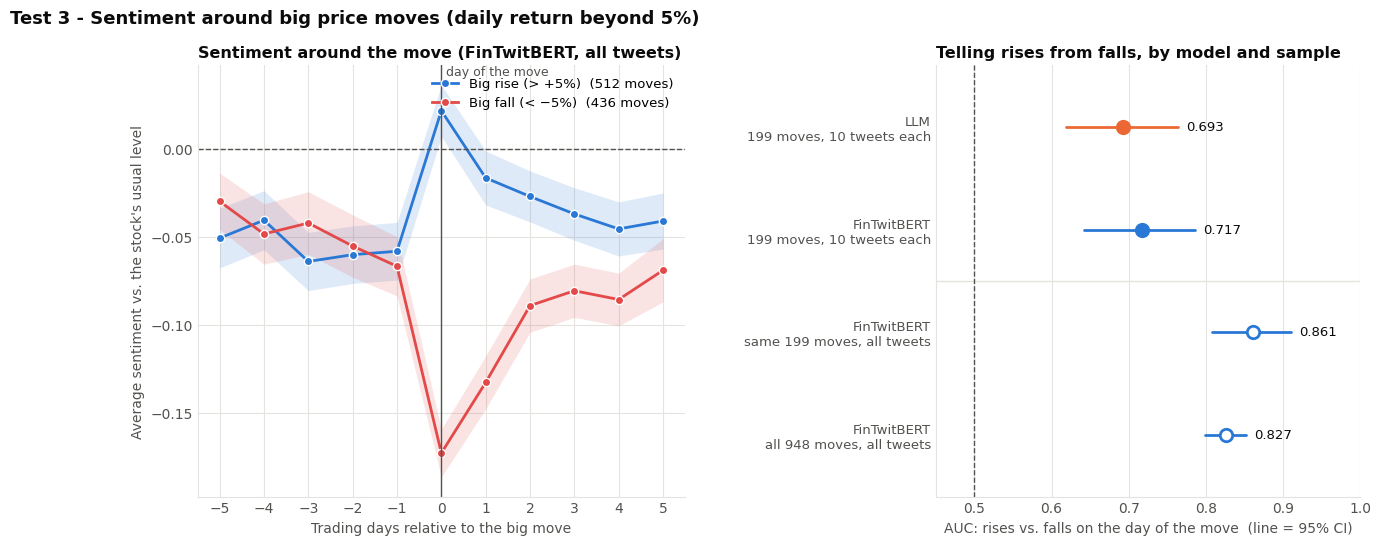

In [ ]:
RISE, FALL = '#2a78d6', '#e34948'                                     # rise = blue, fall = red
FINTWIT, LLM_COLOR = '#2a78d6', '#eb6834'
INK, INK_2, GRID = '#0b0b0b', '#52514e', '#e4e3df'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.6), gridspec_kw={'width_ratios': [1.15, 1], 'wspace': 0.55})

# Left panel: event study
for is_up, color, name in [(1, RISE, 'Big rise (> +5%)'), (0, FALL, 'Big fall (< −5%)')]:
    p = path.loc[is_up]
    n = int((events['is_up'] == is_up).sum())
    ax1.fill_between(p.index, p['mean'] - p['ci'], p['mean'] + p['ci'], color=color, alpha=0.15, linewidth=0)
    ax1.plot(p.index, p['mean'], color=color, linewidth=2, marker='o', markersize=6, markeredgecolor='white', label=f'{name}  ({n} moves)')
ax1.axhline(0, color=INK_2, linewidth=1, linestyle='--')
ax1.axvline(0, color=INK_2, linewidth=1)
ax1.text(0.1, ax1.get_ylim()[1], 'day of the move', color=INK_2, fontsize=9, va='top')
ax1.set_xticks(range(-5, 6))
ax1.set_xlabel('Trading days relative to the big move', color=INK_2)
ax1.set_ylabel("Average sentiment vs. the stock's usual level", color=INK_2)
ax1.set_title('Sentiment around the move (FinTwitBERT, all tweets)', loc='left', fontsize=11.5, fontweight='bold', color=INK)
ax1.legend(loc='upper right', frameon=False, fontsize=9.5)

# Right panel: can each model tell rises from falls, on the day of the move? (filled = same sample of tweets)
rows = [(f'FinTwitBERT\nall {len(day0)} moves, all tweets', FINTWIT, auc_all, True)]
if auc_llm is not None:                                               # LLM comparison available (previous cell)
    rows += [(f'FinTwitBERT\nsame {len(per_event)} moves, all tweets', FINTWIT, auc_ft_all, True),
             (f'FinTwitBERT\n{len(per_event)} moves, {N_TWEETS} tweets each', FINTWIT, auc_ft, False),
             (f'LLM\n{len(per_event)} moves, {N_TWEETS} tweets each', LLM_COLOR, auc_llm, False)]
for i, (label, color, (auc, low_i, high_i), hollow) in enumerate(rows):
    ax2.plot([low_i, high_i], [i, i], color=color, linewidth=2, solid_capstyle='round')
    ax2.scatter(auc, i, s=80, zorder=3, linewidth=2, color='white' if hollow else color, edgecolor=color)
    ax2.text(high_i + 0.01, i, f'{auc:.3f}', va='center', color=INK, fontsize=9.5)
if len(rows) > 2:
    ax2.axhline(1.5, color=GRID, linewidth=1)                         # separates "same 10 tweets" from "all tweets"
ax2.axvline(0.5, color=INK_2, linewidth=1, linestyle='--')
ax2.set_yticks(range(len(rows)), [r[0] for r in rows], fontsize=9.5)
ax2.set(xlim=(0.45, 1.0), ylim=(-0.6, len(rows) - 0.4))
ax2.set_xlabel('AUC: rises vs. falls on the day of the move  (line = 95% CI)', color=INK_2)
ax2.set_title('Telling rises from falls, by model and sample', loc='left', fontsize=11.5, fontweight='bold', color=INK)

for ax in (ax1, ax2):
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color(GRID)
    ax.tick_params(colors=INK_2, length=0)
    ax.grid(color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
ax2.grid(axis='y', visible=False)

fig.suptitle(f'Test 3 - Sentiment around big price moves (daily return beyond {THRESHOLD:.0%})', x=0.0, ha='left', fontsize=13, fontweight='bold', color=INK)
plt.show()

**Interpretation of Test 3.**
- **On the day of a big move, sentiment clearly separates rises from falls** (AUC 0.83 over 947 moves). The reaction is **asymmetric and persistent for falls**: sentiment drops to -0.17 on the day of a big fall and is still well below normal five days later, while after a big rise it barely rises above its usual level and returns to it within a day.
- **Before the move, sentiment says nothing about its direction**: the two curves overlap from day −5 to day −1, both slightly below normal. This confirms Test 2: tweets react to big moves, they do not anticipate their direction.
- **Robustness check of the model choice.** On the same 200 moves and the same 10 tweets per move, the LLM reads sentiment better than FinTwitBERT (AUC 0.70 vs 0.61, difference of +0.08, 95% interval [+0.02, +0.14], significant). This confirms, on our own data, the ranking found on StockEmotions.
- **But FinTwitBERT using all the tweets of the day does even better** (0.79 on the same 200 moves). Reading many tweets with a slightly weaker model beats reading a few with the best one.

### ***Step 3.7:*** *Which model do we choose, and why?*

**We choose FinTwitBERT to measure the sentiment of our 5.56 million tweets, and keep the LLM (gpt-oss-120b) as a robustness check.**

- **The best model we can run on the full sample.** Among the pre-trained transformers, FinTwitBERT separates bullish from bearish messages best on the 10,000 StockEmotions messages (AUC 0.757, against 0.700 for Twitter-RoBERTa and 0.633 for FinBERT). It was trained on financial social-media posts, so it knows both the finance vocabulary and the trader slang. FinBERT, trained on formal financial news, calls 80% of the messages neutral; Twitter-RoBERTa knows the slang but not the finance.
- **The LLM is more accurate, but it does not scale.** gpt-oss-120b has the highest AUC (0.838 against 0.766 for FinTwitBERT on the same 980 messages). But on Groq's free tier we can send about 20 tweets every 12 seconds, roughly 100 tweets per minute: scoring all 5,564,914 tweets would take about 39 days of non-stop requests, or a paid API. FinTwitBERT runs on our own computer, for free, on the whole sample.
- **Reproducible.** FinTwitBERT is a fixed set of weights that we download and run ourselves, so the same tweet always gets the same score. An API model can be changed or withdrawn by its provider.
- **Probabilities, not just labels.** For every tweet FinTwitBERT returns P(bullish), P(neutral) and P(bearish). This gives a continuous score, P(bullish) − P(bearish), that can be averaged by stock and day (Test 2, Task 4), and a confidence margin that flags ambiguous tweets (Step 1.7).
- **It works on our own data.** Its daily sentiment moves with same-day returns (Spearman 0.265 in Test 2) and separates big rises from big falls (AUC 0.83 over 947 moves in Test 3): averaging many tweets per day compensates for its errors on individual tweets.

**Known limitations, and how we deal with them.** FinTwitBERT leans bearish, because it reacts to words like "short" or "puts" whatever the author's position (Step 1.9), and it cannot read emojis (Step 2.1). We therefore rely mainly on *relative* measures (sentiment relative to each stock's own average, rankings across stocks) and re-check the key findings with the LLM on a subsample (Steps 1.9 and 3.6).

__________

# 3. Sentiment in the full sample: diagnostics and LLM robustness check

### ***Step 1.6:*** *Sentiment Analysis*

In [ ]:
fintwit = pipeline('text-classification',                                     # task: classify a text into labels
                   model='StephanAkkerman/FinTwitBERT-sentiment',             # which model to download from Hugging Face
                   top_k=None)                                                # return the probability of EVERY label, not just the best one

examples = [                                                                  # test tweets where we know the right answer
    '$AAPL beats earnings expectations, revenue up 12%',                      # formal, positive news -> bullish
    '$NFLX subscriber growth disappoints, guidance cut',                      # formal, negative news -> bearish
    '$AMZN reports earnings on Thursday after the close',                    # pure information -> neutral
    '$TSLA loading up on calls, to the moon 🚀🚀',                             # trader slang -> bullish
    '$SPY my puts are printing today',                                        # slang: puts gain when prices fall -> bearish
    'Walmart sign said "Use in case you are Short $NFLX". Even Walmart knows..',  # sarcasm from our data -> bullish on NFLX
]

results = fintwit(examples)                                                   # run the model on all examples: one list of {label, score} per tweet
table = pd.DataFrame([{d['label']: d['score'] for d in r} for r in results],  # one row per tweet, one column per label with its probability
                     index=examples)                                          # use the tweet text as the row name
table['prediction'] = table.idxmax(axis=1)                                    # the label with the highest probability = the model's answer
table.round(2)                                                                # show probabilities with 2 decimals

config.json:   0%|          | 0.00/857 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  439MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.79k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/226k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/713k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

,BULLISH,NEUTRAL,BEARISH,prediction
"$AAPL beats earnings expectations, revenue up 12%",0.98,0.02,0.00,BULLISH
"$NFLX subscriber growth disappoints, guidance cut",0.00,0.00,1.00,BEARISH
$AMZN reports earnings on Thursday after the close,0.01,0.99,0.00,NEUTRAL
"$TSLA loading up on calls, to the moon 🚀🚀",1.00,0.00,0.00,BULLISH
$SPY my puts are printing today,0.03,0.00,0.97,BEARISH
"Walmart sign said ""Use in case you are Short $NFLX"". Even Walmart knows..",0.09,0.34,0.57,BEARISH


We chose FinTwitBERT as our first model of choice for sentiment analysis. After testing the model on examples, we see that it classified 5 out of 6 tweets correctly.

It worked well on financial lingo/slang, however as many models, it struggles to classify sarcasm, so when it comes to classification, the model is unsure which category that type of tweet belongs to. So, it's important to look not only at the final predicted class, but also at the allocated probabilities to each class.

In [ ]:
# 1) Prepare the sample
has_text = tweets['n_words_no_tags'] > 0
sample = tweets[has_text].sample(10_000, random_state=42).copy()
sample['model_text'] = sample['clean'].str.replace(r'@\w+', '@USER', regex=True)

# 2) Function: always defined, because Step 2.1 (emojis) uses it again
def run_fintwit(texts, chunk=1_000, batch_size=32):
    rows = []
    for i in tqdm(range(0, len(texts), chunk)):
        out = fintwit(texts[i:i + chunk], batch_size=batch_size, truncation=True)
        rows += [{d['label']: d['score'] for d in r} for r in out]
    return pd.DataFrame(rows)

CACHE = 'fintwit_sample_10k.pkl'

if os.path.exists(CACHE):
    # 3a) Already computed: reload in seconds
    sample = pd.read_pickle(CACHE)
    print(f'Loaded saved results from {CACHE}')
else:
    # 3b) First time: run the model (~10 min), then save
    start = time.time()
    probs = run_fintwit(sample['model_text'].tolist())
    seconds = time.time() - start
    speed = len(sample) / seconds
    print(f'Speed: {speed:.0f} tweets/second ({seconds / 60:.1f} min for 10,000)')
    print(f'All {has_text.sum():,} tweets would take about {has_text.sum() / speed / 3600:.1f} hours on this computer')

    sample['p_bullish'] = probs['BULLISH'].values
    sample['p_neutral'] = probs['NEUTRAL'].values
    sample['p_bearish'] = probs['BEARISH'].values
    sample['label'] = probs.idxmax(axis=1).str.lower().values
    sample['score'] = sample['p_bullish'] - sample['p_bearish']
    sample.to_pickle(CACHE)

# 4) First results
print(f"\nAverage sentiment score: {sample['score'].mean():+.3f}")
print('\nShare of tweets per label:')
print(sample['label'].value_counts(normalize=True).round(3))

  0%|          | 0/10 [00:00<?, ?it/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Speed: 214 tweets/second (0.8 min for 10,000)
All 5,437,227 tweets would take about 7.1 hours on this computer

Average sentiment score: -0.110

Share of tweets per label:
label
bearish    0.455
bullish    0.340
neutral    0.204
Name: proportion, dtype: float64


The sentiment achieved is as follows:
- Average score: −0.11, so slightly bearish overall.
- 45.5% bearish, 34% bullish, 20% neutral.

The findings contradict what's known about StockTwits. When users tag their own posts, bullish tags far outnumber bearish ones. And only 20% of posts are flagged as neutral.

Either this period and these stocks really were more bearish than usual, or FinTwitBERT has a bias on our data. For example, it may read words like "short", "down", "puts" or "drop" as bearish even in neutral or bullish contexts, like the Walmart tweet. The model learned from more recent tweets (many about crypto), and our tweets go back to 2009, so its training data may not be perfect match.

___________

#### *Now let's check the model by reading its predictions: look at random tweets from each label and judge for ourselves whether the model is right and how confident is it in the predictions.*

In [ ]:
pd.set_option('display.max_colwidth', 200)                                    # show full tweet text in tables

# --- 1) Read 8 random tweets per predicted label ---
for lab in ['bearish', 'bullish', 'neutral']:                                 # one table per label
    print(f'\n===== Predicted {lab.upper()} =====')
    display(sample.loc[sample['label'] == lab,                                # keep only tweets with this predicted label
                       ['clean', 'p_bullish', 'p_neutral', 'p_bearish']]      # show the text and the 3 probabilities
                  .sample(8, random_state=1)                                  # 8 random ones, same every run
                  .round(2))

# --- 2) How confident is the model? ---
sample['confidence'] = sample[['p_bullish', 'p_neutral', 'p_bearish']].max(axis=1)  # probability of the winning label
print('\nConfidence of the predicted label:')
print(sample.groupby('label')['confidence'].describe(percentiles=[.25, .5, .75]).round(2))  # per label: mean, quartiles...
print(f"\nShare of tweets where the model is unsure (winning label < 60%): {(sample['confidence'] < 0.6).mean():.1%}")


===== Predicted BEARISH =====


,clean,p_bullish,p_neutral,p_bearish
1817714,"$FB $AAPL $NVDA $SPY you sound like you're JDuda, same ridiculous posts",0.03,0.41,0.56
3610768,"$SPX $SPY $QQQ Somebody needs to get their ass FIRED, they lucky I don't work there because I would be terminating people faster than Trump.",0.02,0.34,0.64
4988759,$TSLA TO UNDERGO MANAGEMENT REORGANIZATION: DJ CITES MEMO,0.00,0.02,0.98
4512572,$TSLA maybe back to 300 isn’t so crazy after all.,0.06,0.03,0.91
700877,$FB and it's red. beautiful,0.14,0.01,0.86
5189066,$TSLA Scary moves here...out for now,0.01,0.00,0.99
420391,watch for a gap fill on $spy back to 120.80. $$ $spx $dia $dja,0.22,0.05,0.74
3970256,"$TSLA Elon BITCHES get STITCHES. Did you buy the pump? I warned you, we are going back to 800. Did you listen, or were you too busy gobbling Elon's knob? Don't forget to swallow.",0.01,0.00,0.99



===== Predicted BULLISH =====


,clean,p_bullish,p_neutral,p_bearish
14816,$SPY $TSLA $AMZN $BABA $ADBE if it turns green will be a huge bounce,0.91,0.03,0.06
3054544,$NFLX $390 lets go,0.78,0.17,0.06
2854469,$NFLX she is on the move!!,0.88,0.10,0.01
1565888,$AAPL another $220 target price!!!! 🚀🚀🚀🚀🚀,0.76,0.03,0.22
3654702,$QQQ gap fill 50c higher,0.70,0.02,0.28
3662202,$SPY $QQQ $SOXX $IBB $XBI PM SPY up 15 Nasdaq up 43 Dow 155 (was 198 but $GS pulled it down ) so BULLS in control !!BTD BTD BTD !,0.87,0.04,0.09
5413120,"""@USER: $TSLA The fear was a great Buying opportunity yesterday!""",0.97,0.01,0.02
2760550,$AMZN She wants walk above $373,0.84,0.09,0.08



===== Predicted NEUTRAL =====


,clean,p_bullish,p_neutral,p_bearish
1915884,$SPY $AAPL $NFLX time for earnings season,0.07,0.86,0.07
2529638,"** $AMZN In the last one month, 10 Winners ( above 30 per) and 4 Losers ( below 30 per)",0.17,0.81,0.01
1563591,$AAPL bamboozled,0.25,0.42,0.32
2901024,$NFLX Watching this stock is like -,0.36,0.58,0.06
3147559,$NFLX spikes upward... is Google interested in an acquisition?,0.30,0.66,0.04
1579632,$AAPL $ROKU So here’s a screenshot after markets closed today. Still sitting pretty and I still have plenty of time left 🍏🤑💰,0.43,0.48,0.10
595108,"$DIS for the newbies who will undoubtedly say what about star wars or captain america, please remember this chart.",0.07,0.91,0.03
5032776,PRE Market Movers: $USG $INTC $BA $FB $GE $C $TSLA $BMY $MRK $FINL $DLTR $DAN $MO,0.24,0.72,0.04



Confidence of the predicted label:
          count  mean   std   min   25%   50%   75%  max
label                                                   
bearish  4554.0  0.84  0.17  0.34  0.72  0.91  0.98  1.0
bullish  3405.0  0.76  0.17  0.35  0.62  0.78  0.91  1.0
neutral  2041.0  0.75  0.18  0.36  0.60  0.77  0.92  1.0

Share of tweets where the model is unsure (winning label < 60%): 19.0%


**Reading the 8 random tweets per predicted label, FinTwitBERT's predictions are mostly correct.**

- The model is confident on most tweets: the median probability of the winning label is between 0.77 and 0.91, and only 19% of tweets fall below 60%. Bearish predictions are the most confident (median 0.91), so the high share of bearish tweets is not driven by borderline calls.

- The mistakes happen where the model hesitates. The clearest error, an insult to another user labelled bearish, gets 0.56 bearish vs 0.41 neutral, a gap of only 0.15 (ex: "$FB $AAPL $NVDA $SPY you sound like you're JDuda, same ridiculous posts"). A small gap between the top two probabilities therefore flags tweets that are ambiguous for a human reader too.

- The −0.11 average is therefore not an obvious model error. Since this check covers only 24 tweets, we test it more systematically below by measuring how many tweets are ambiguous, and whether the average changes when we keep only the clear ones.

__________

### ***Step 1.7:*** *Ambiguity check*
We move on to measure the gap between the model's top two probabilities for every tweet, then see whether the average sentiment changes when we keep only the clear ones.

For each tweet we compute the margin and the gap between the two highest probabilities. A margin below 0.2 means the model is torn between two labels, so we call the tweet ambiguous. We then check whether the average sentiment changes when only clear tweets are kept.

In [ ]:
probs_array = sample[['p_bullish', 'p_neutral', 'p_bearish']].to_numpy()     # the 3 probabilities as a grid of numbers, one row per tweet
sorted_probs = np.sort(probs_array, axis=1)                                   # sort each row from smallest to largest
sample['margin'] = sorted_probs[:, -1] - sorted_probs[:, -2]                  # highest minus second-highest probability

THRESHOLD = 0.2                                                               # below this margin, the tweet counts as ambiguous
sample['ambiguous'] = sample['margin'] < THRESHOLD                            # True / False for each tweet

# 1) How many tweets are ambiguous, overall and per label?
print(f"Ambiguous tweets (margin < {THRESHOLD}): {sample['ambiguous'].mean():.1%}")
print(sample.groupby('label')['ambiguous'].mean().round(3).rename('share ambiguous'))  # share of ambiguous tweets within each predicted label

# 2) The 8 most ambiguous tweets
pd.set_option('display.max_colwidth', 200)                                    # show the full tweet text
display(sample.nsmallest(8, 'margin')                                         # the 8 tweets with the smallest margin
              [['clean', 'p_bullish', 'p_neutral', 'p_bearish', 'margin']].round(2))

# 3) Does the result change if we keep only clear tweets?
clear = sample[~sample['ambiguous']]                                          # ~ means "not": keep only the clear tweets
comparison = pd.DataFrame({
    'All tweets':        [len(sample), sample['score'].mean()] + sample['label'].value_counts(normalize=True)[['bullish', 'neutral', 'bearish']].tolist(),  # size, average, label shares
    'Clear tweets only': [len(clear),  clear['score'].mean()]  + clear['label'].value_counts(normalize=True)[['bullish', 'neutral', 'bearish']].tolist(),   # same for clear tweets
}, index=['tweets', 'average score', 'share bullish', 'share neutral', 'share bearish'])  # row names
display(comparison.round(3))                                                  # side-by-side comparison

Ambiguous tweets (margin < 0.2): 13.6%
label
bearish    0.098
bullish    0.162
neutral    0.177
Name: share ambiguous, dtype: float64


,clean,p_bullish,p_neutral,p_bearish,margin
2254325,$AAPL Bounce or bull trap? You don't decide,0.18,0.41,0.41,0.0
3599970,$SPY $QQQ The only reason to raise rates is to avoid inflation (ONLY reason). We see stellar growth and little to no sign of inflation.,0.50,0.01,0.50,0.0
3849863,"$TSLA For all the Longs, Buy the calls and sell all the stocks you got if you have profits. The rest wait for dust to settle.",0.50,0.01,0.50,0.0
1325760,$AAPL let’s see sub 310 open,0.31,0.34,0.34,0.0
4805528,$TSLA That wall needs to hold,0.28,0.36,0.36,0.0
264063,$SPY $DIA $QQQ Do you have the nerve to be long through the weekend?,0.27,0.37,0.37,0.0
2225939,$AAPL just ran a scan 80% of stocks that met perimeters up 5% in 2 days.ave. winner 119% ave loser -9%.99.77% confidence this will happen.,0.37,0.37,0.26,0.0
5092803,$TSLA Just as soon as you think the vomiting is finished.....,0.04,0.48,0.48,0.0


,All tweets,Clear tweets only
tweets,10000.000,8643.000
average score,-0.110,-0.137
share bullish,0.340,0.330
share neutral,0.204,0.194
share bearish,0.455,0.475


The results of the ambiguity check show that 13.6% of tweets are ambiguous (margin below 0.2), meaning the model hesitates between two labels. Bearish predictions are the least often ambiguous (9.8%), compared with bullish (16.2%) and neutral (17.7%), consistent with bearish predictions being the most confident.

The most ambiguous tweets contain questions ("Bounce or bull trap?"), mixed advice ("buy the calls and sell all the stocks"), or metaphors ("just as soon as you think the vomiting is finished"). In these cases the model splits almost evenly between two labels, confirming text meaning ambiguity is captured by the margin.

Removing the ambiguous tweets does not weaken the bearish result, it slightly strengthens it. The average score moves from −0.110 to −0.137, and the share of bearish tweets rises from 45.5% to 47.5%.

To check that the result does not depend on the choice of threshold, we repeat the analysis with margins of 0.1, 0.2 and 0.3, removing 7.1%, 13.6% and 19.8% of tweets respectively.

The conclusion is the same in all cases: the average score stays negative and becomes more bearish as ambiguous tweets are removed (−0.123, −0.137 and −0.153, against −0.110 for all tweets). Bearish predictions are always the least ambiguous and neutral predictions the most. Thus, the leaning towards bearish tweets is not model uncertainty, it's the structure of the data.

_____________

### ***Step 1.8:*** *Where does the bearish sentiment come from?*

Now, let's break the average sentiment down by stock and by year. To identify which stocks drive the overall result, we recompute the average after removing each stock in turn (leave-one-out). Observing a large change indicates that the stock has a large influence. A tweet about two stocks counts for both stocks. Stocks with fewer than 100 tweets in the sample are flagged as unreliable, since their averages are too noisy.

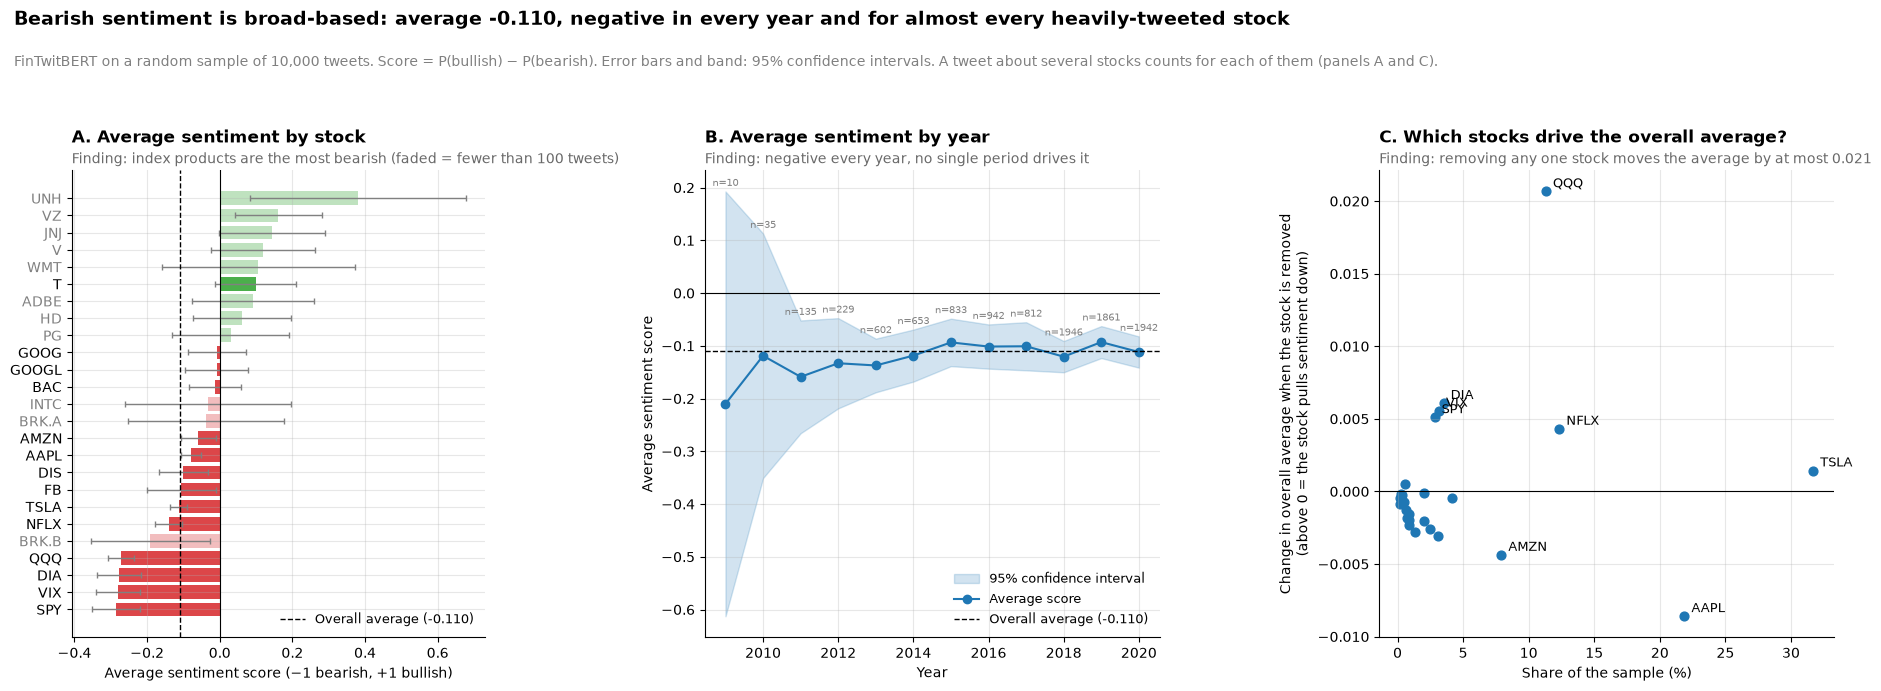

In [ ]:
overall = sample['score'].mean()                                              # overall average score (-0.110)

#  Data for panel A: average by stock with 95% confidence interval
per_stock = (sample[['message_id', 'score']].merge(tweet_stock, on='message_id')  # add the stock(s) to each classified tweet
                   .groupby('symbol')['score'].agg(['mean', 'std', 'size']))  # per stock: average, standard deviation, number of tweets
per_stock['ci'] = 1.96 * per_stock['std'] / np.sqrt(per_stock['size'])        # half-width of the 95% confidence interval (wide when few tweets)
per_stock = per_stock.sort_values('mean')                                     # most bearish at the bottom, most bullish at the top

# ---------- Data for panel B: average by year with 95% confidence interval ----------
per_year = sample.assign(year=sample['datetime'].dt.year).groupby('year')['score'].agg(['mean', 'std', 'size'])  # same, per year
per_year['ci'] = 1.96 * per_year['std'] / np.sqrt(per_year['size'])           # 95% confidence interval per year

# ---------- Data for panel C: leave-one-out ----------
loo = {}                                                                      # results collected here, one entry per stock
for sym in per_stock.index:                                                   # go through every stock
    ids = tweet_stock.loc[tweet_stock['symbol'] == sym, 'message_id']         # IDs of tweets filed under this stock
    inside = sample['message_id'].isin(ids)                                   # True for sample tweets about this stock
    loo[sym] = {'share': inside.mean() * 100,                                 # % of the sample about this stock
                'change': sample.loc[~inside, 'score'].mean() - overall}      # change in the average when it is removed
loo = pd.DataFrame(loo).T                                                     # one row per stock

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(19, 7), gridspec_kw={'width_ratios': [1, 1.1, 1.1]})  # 3 panels side by side

# ---------- Panel A ----------
reliable = per_stock['size'] >= 100                                           # True if at least 100 tweets
colors = [(0.84, 0.15, 0.16, 0.85 if r else 0.3) if m < 0 else (0.17, 0.63, 0.17, 0.85 if r else 0.3)  # red if negative, green if positive...
          for m, r in zip(per_stock['mean'], reliable)]                      # ...faded (transparent) if fewer than 100 tweets
ax1.barh(per_stock.index, per_stock['mean'], xerr=per_stock['ci'], color=colors,  # horizontal bars with confidence-interval lines
         error_kw=dict(ecolor='grey', lw=1, capsize=2))                      # grey error lines with small caps
ax1.axvline(overall, color='black', ls='--', lw=1, label=f'Overall average ({overall:+.3f})')  # dashed line at the overall average
ax1.axvline(0, color='black', lw=0.8)                                         # solid line at zero (neutral)
for sym in per_stock.index[~reliable]:                                        # for stocks with fewer than 100 tweets...
    ax1.get_yticklabels()[list(per_stock.index).index(sym)].set_color('grey') # ...grey out their name
ax1.set(xlabel='Average sentiment score (−1 bearish, +1 bullish)', ylabel='') # axis title
ax1.legend(loc='lower right', frameon=False, fontsize=9)                      # legend without a box
ax1.set_title('A. Average sentiment by stock', loc='left', fontsize=12, fontweight='bold', pad=20)  # bold panel title
ax1.text(0, 1.015, 'Finding: index products are the most bearish (faded = fewer than 100 tweets)', transform=ax1.transAxes, fontsize=10, color='dimgrey')  # finding line

# ---------- Panel B ----------
ax2.fill_between(per_year.index, per_year['mean'] - per_year['ci'], per_year['mean'] + per_year['ci'],  # shaded band = confidence interval
                 color='#1f77b4', alpha=0.2, label='95% confidence interval')
ax2.plot(per_year.index, per_year['mean'], 'o-', color='#1f77b4', label='Average score')  # average per year: line with dots
ax2.axhline(overall, color='black', ls='--', lw=1, label=f'Overall average ({overall:+.3f})')  # dashed line at the overall average
ax2.axhline(0, color='black', lw=0.8)                                         # solid line at zero
for y, row in per_year.iterrows():                                            # for each year...
    ax2.annotate(f'n={row["size"]:.0f}', (y, row['mean'] + row['ci']), textcoords='offset points', xytext=(0, 4),  # ...write the number of tweets above the band
                 ha='center', fontsize=7, color='grey')
ax2.set(xlabel='Year', ylabel='Average sentiment score')                      # axis titles
ax2.legend(loc='lower right', frameon=False, fontsize=9)                      # legend
ax2.set_title('B. Average sentiment by year', loc='left', fontsize=12, fontweight='bold', pad=20)  # bold panel title
ax2.text(0, 1.015, 'Finding: negative every year, no single period drives it', transform=ax2.transAxes, fontsize=10, color='dimgrey')  # finding line

# ---------- Panel C ----------
ax3.scatter(loo['share'], loo['change'], s=40, color='#1f77b4')               # one dot per stock
for sym, row in loo.iterrows():                                               # label only the important dots:
    if row['share'] > 5 or abs(row['change']) > 0.005:                        # big stocks (>5% of sample) or big influence (>0.005)
        ax3.annotate(sym, (row['share'], row['change']), textcoords='offset points', xytext=(5, 3), fontsize=9)
ax3.axhline(0, color='black', lw=0.8)                                         # zero line = no influence
ax3.set(xlabel='Share of the sample (%)',                                     # axis titles
        ylabel='Change in overall average when the stock is removed\n(above 0 = the stock pulls sentiment down)')
ax3.set_title('C. Which stocks drive the overall average?', loc='left', fontsize=12, fontweight='bold', pad=20)  # bold panel title
ax3.text(0, 1.015, f'Finding: removing any one stock moves the average by at most {loo["change"].abs().max():.3f}',  # finding line with the real number
         transform=ax3.transAxes, fontsize=10, color='dimgrey')

for ax in (ax1, ax2, ax3):                                                    # same styling for all panels
    ax.grid(alpha=0.3); ax.spines[['top', 'right']].set_visible(False)        # light grid, no top/right border

fig.suptitle(f'Bearish sentiment is broad-based: average {overall:+.3f}, negative in every year and for almost every heavily-tweeted stock',  # headline
             x=0.01, ha='left', fontsize=14, fontweight='bold')
fig.text(0.01, 0.9, f'FinTwitBERT on a random sample of {len(sample):,} tweets. Score = P(bullish) − P(bearish). '  # grey subtitle
         'Error bars and band: 95% confidence intervals. A tweet about several stocks counts for each of them (panels A and C).', fontsize=10, color='grey')
fig.tight_layout(rect=(0, 0, 1, 0.88))                                        # arrange panels, room at the top for titles
plt.show()                                                                    # display

Almost every stock with more than 100 tweets has a negative average score, with AT&T (+0.10) as the only exception.
- The most bearish are the market-wide products SPY, VIX, DIA and QQQ (around −0.28), likely because investors tweet about the index when they fear a crash or hedge by betting against it.
- Individual tech stocks are only mildly negative (AAPL −0.08, AMZN −0.06), and Tesla (−0.113) is almost exactly at the overall average.
- Every year is negative (between −0.09 and −0.16), with no year standing out. Removing any single stock moves the overall average by at most 0.021; Tesla, despite being 32% of the sample, changes it by only 0.001.


The confidence intervals confirm these patterns.
- Index products are clearly more bearish than the rest, while the positive averages of small defensive stocks (UNH, VZ, JNJ) have wide intervals that often include zero, so they cannot be trusted with so few tweets.
- The yearly averages all fall within overlapping intervals, meaning sentiment is statistically stable over time. Panel C shows that QQQ pulls the average down the most and AAPL pulls it up the most, but both effects are small.

**Conclusion:** according to FinTwitBERT, StockTwits sentiment in our sample is mildly bearish (−0.110). This result is robust as it holds after removing ambiguous tweets, in every year, and it does not depend on any single stock. It is strongest for index products.

### ***Step 1.9:*** *Robustness check with an LLM*

1) **Setup:** create a Groq account and API key, install the package, and test one call.
2) **The classification prompt:** write the instructions (zero-shot) and the examples (few-shot), and test them on the 6 example tweets from Task 1.
3) **Run on 1,000 tweets:** a random subset of your 10,000-tweet sample, so FinTwitBERT's answers already exist for the same tweets. Results are saved to disk as they come in, so nothing is lost if you hit a limit.
4) **Compare with FinTwitBERT:** How often do the two agree, and on which tweets? Is the LLM also bearish on average? Do they disagree mostly on the tweets FinTwitBERT found ambiguous?
5) **Redo the key Task 1 findings with the LLM labels:** average sentiment, index products vs single stocks. This checks that the conclusions don't depend on the model.

#### *1.9.1–1.9.2 Setup & Classification Prompt*

In [ ]:
import os, json, getpass, requests                                            # requests is used only to test the key

def groq_key_works(key):                                                      # ask Groq directly whether this key is accepted
    try:
        r = requests.get('https://api.groq.com/openai/v1/models',
                         headers={'Authorization': f'Bearer {key}'}, timeout=10)
        return r.status_code == 200                                           # 200 = valid key
    except Exception:
        return False

key = os.environ.get('GROQ_API_KEY', '').strip()                              # key already stored (may be empty or wrong)
while not (key.startswith('gsk_') and groq_key_works(key)):                   # keep asking until we have a working key
    if key:
        print('That key was rejected by Groq. Please paste it again.')
    key = getpass.getpass('Paste your Groq API key (starts with gsk_): ').strip()  # hidden box; .strip() removes stray spaces/newlines
os.environ['GROQ_API_KEY'] = key                                              # save the working key for this session (never in the notebook)
print('Groq key works ✅')
client = Groq(max_retries=5)                                                  # connection to Groq; retries automatically if we hit the rate limit
LLM_MODEL = 'openai/gpt-oss-120b'                                             # OpenAI's open-weight model, 120 billion parameters
SYSTEM_PROMPT = (                                                             # the instructions the LLM receives before the tweets
    "You are a financial sentiment classifier for StockTwits messages. "
    "For each message, classify its implication for the future price of the stock(s) mentioned:\n"
    "- bullish: the author expects the price to rise, or reports news that is clearly good for the stock "
    "(buying, holding long, calls, optimism, strong earnings, upgrades)\n"
    "- bearish: the author expects the price to fall, or reports news that is clearly bad for the stock "
    "(selling, shorting, puts, pessimism, weak earnings, downgrades)\n"
    "- neutral: no clear implication for the price (neutral news, questions, facts, lists of tickers)\n"
    "Read slang, emojis and sarcasm as an experienced trader would.\n"
    'Reply with JSON only: {"labels": ["bullish" | "bearish" | "neutral", ...]}, '
    "with exactly one label per message, in the same order."
)
FEW_SHOT = [                                                                  # invented examples (not from our data) with their correct labels
    ('$NVDA added to my position on this dip, target 520 🎯', 'bullish'),
    ('$SPY this bounce is a bull trap, adding puts', 'bearish'),
    ('$MSFT dividend goes ex tomorrow', 'neutral'),
    ('$NFLX guidance was awful, get out while you can 📉', 'bearish'),
    ("What's everyone's price target on $AMD?", 'neutral'),
    ('$F red all day and I love it, my puts are printing 😂', 'bearish'),
]
FEW_SHOT_MESSAGES = [                                                         # the examples written as a mini-conversation the LLM "remembers"
    {'role': 'user', 'content': '\n'.join(f'{i + 1}. {t}' for i, (t, _) in enumerate(FEW_SHOT))},
    {'role': 'assistant', 'content': json.dumps({'labels': [l for _, l in FEW_SHOT]})},
]
LABEL_TO_SCORE = {'bullish': 1, 'neutral': 0, 'bearish': -1}                  # same -1 / 0 / +1 scale as before

def llm_classify_batch(texts, few_shot=False, max_attempts=3):
    """Send a batch of tweets to the LLM in one request; return one label per tweet (None if it fails)."""
    messages = [{'role': 'system', 'content': SYSTEM_PROMPT}]                 # 1) the instructions
    if few_shot:
        messages += FEW_SHOT_MESSAGES                                         # 2) the examples (few-shot only)
    numbered = '\n'.join(f'{i + 1}. {t[:500]}' for i, t in enumerate(texts))  # 3) the tweets, numbered, cut at 500 characters
    messages.append({'role': 'user', 'content': numbered})
    for _ in range(max_attempts):                                             # try up to 3 times
        try:
            response = client.chat.completions.create(
                model=LLM_MODEL, messages=messages,
                temperature=0,                                                # 0 = always the most likely answer (reproducible)
                reasoning_effort='low',                                       # think briefly: saves tokens (and quota)
                response_format={'type': 'json_object'})
            labels = json.loads(response.choices[0].message.content).get('labels', [])  # read the list of labels
            labels = [str(l).lower().strip() for l in labels]                 # tidy them: 'Bullish ' -> 'bullish'
            if len(labels) == len(texts) and all(l in LABEL_TO_SCORE for l in labels):  # one valid label per tweet?
                return labels                                                 # success
        except Exception as e:                                                # network problem, bad JSON...
            print('Retrying after error:', type(e).__name__, e, '| cause:', repr(e.__cause__))  # show the real underlying cause
    return [None] * len(texts)                                                # give up: mark these tweets as missing, not wrong

# Test on the same 6 tweets we used for FinTwitBERT
test_tweets = [
    '$AAPL beats earnings expectations, revenue up 12%',
    '$NFLX subscriber growth disappoints, guidance cut',
    '$AMZN reports earnings on Thursday after the close',
    '$TSLA loading up on calls, to the moon 🚀🚀',
    '$SPY my puts are printing today',
    'Walmart sign said "Use in case you are Short $NFLX". Even Walmart knows..',
]
fintwit_test = [max(r, key=lambda d: d['score'])['label'].lower() for r in fintwit(test_tweets)]  # FinTwitBERT's answer, for comparison
display(pd.DataFrame({'FinTwitBERT': fintwit_test,
                      'LLM zero-shot': llm_classify_batch(test_tweets),
                      'LLM few-shot': llm_classify_batch(test_tweets, few_shot=True)},
                     index=test_tweets))

Groq key works ✅


,FinTwitBERT,LLM zero-shot,LLM few-shot
"$AAPL beats earnings expectations, revenue up 12%",bullish,bullish,bullish
"$NFLX subscriber growth disappoints, guidance cut",bearish,bearish,bearish
$AMZN reports earnings on Thursday after the close,neutral,neutral,neutral
"$TSLA loading up on calls, to the moon 🚀🚀",bullish,bullish,bullish
$SPY my puts are printing today,bearish,bearish,bearish
"Walmart sign said ""Use in case you are Short $NFLX"". Even Walmart knows..",bearish,bearish,bearish


**The LLM (GPT-OSS 120B on Groq) agrees with FinTwitBERT on all six test tweets.** In a first version it labelled "$AAPL beats earnings expectations" as neutral, because our prompt treated all news as neutral; we adjusted the prompt so that clearly good or bad news counts as bullish or bearish, as FinTwitBERT does, which makes the comparison fair. All models misread the sarcastic Walmart tweet (really bullish on NFLX), showing that sarcasm remains difficult even for a large language model. Zero-shot and few-shot give identical answers on these examples.

#### *1.9.3 Classify 1,000 tweets with the LLM*

Classify 1,000 tweets with the LLM. We draw 1,000 random tweets from the 10,000 already classified by FinTwitBERT and classify them with GPT-OSS 120B, zero-shot and few-shot, in batches of 25. Results are saved after every batch so the run can be resume

In [ ]:
# zero-shot version
N_LLM = 1_000                                                                 # number of tweets sent to the LLM
llm_sample = sample.sample(N_LLM, random_state=42).copy()                    # 1,000 random tweets from the 10,000 (same ones every run)

def classify_with_llm(df, few_shot, path, batch_size=25, pause=12):
    """Classify df['clean'] in batches; save progress to `path` after each batch so the run can resume."""
    done = pd.read_pickle(path) if os.path.exists(path) else pd.Series(dtype=object)  # labels already obtained (if any)
    todo = df.index[~df.index.isin(done.dropna().index)]                     # tweets still to classify (new or previously failed)
    print(f'{len(df) - len(todo)} already done, {len(todo)} to classify')
    for i in tqdm(range(0, len(todo), batch_size)):                           # go through the remaining tweets 25 at a time
        idx = todo[i:i + batch_size]                                          # the row numbers of this batch
        labels = llm_classify_batch(df.loc[idx, 'clean'].tolist(), few_shot=few_shot)  # ask the LLM
        done = pd.concat([done.drop(idx, errors='ignore'),                    # replace any old (failed) answers for these tweets...
                          pd.Series(labels, index=idx, dtype=object)])        # ...with the new ones
        done.to_pickle(path)                                                  # save progress to disk
        time.sleep(pause)                                                     # wait, to stay under the tokens-per-minute limit
    return done.reindex(df.index)                                             # labels in the same order as df

#  Zero-shot
llm_sample['llm_zero'] = classify_with_llm(llm_sample, few_shot=False, path='llm_zero_1k.pkl')
print(f"Missing labels: {llm_sample['llm_zero'].isna().sum()}")
print(llm_sample['llm_zero'].value_counts(normalize=True).round(3))

1000 already done, 0 to classify


0it [00:00, ?it/s]

Missing labels: 0
llm_zero
bullish    0.404
neutral    0.319
bearish    0.277
Name: proportion, dtype: float64


In [ ]:
# Few-shot version
llm_sample['llm_few'] = classify_with_llm(llm_sample, few_shot=True, path='llm_few_1k.pkl')
print(f"Missing labels: {llm_sample['llm_few'].isna().sum()}")
print(llm_sample['llm_few'].value_counts(normalize=True).round(3))

1000 already done, 0 to classify


0it [00:00, ?it/s]

Missing labels: 0
llm_few
bullish    0.378
neutral    0.353
bearish    0.269
Name: proportion, dtype: float64


#### *1.9.4 Compare with FinTwitBERT*

In [ ]:
FT_LABEL = 'label'        # Task 1 column with FinTwitBERT's label (bullish/bearish/neutral)
FT_CONF  = 'confidence'   # FinTwitBERT's confidence (highest of the 3 probabilities)

df = llm_sample.dropna(subset=['llm_zero', 'llm_few']).copy()             # only tweets the LLM labelled
df[FT_CONF] = df[['p_bullish', 'p_neutral', 'p_bearish']].max(axis=1)     # (re)compute confidence from the probabilities
df['ft'] = df[FT_LABEL].str.lower()

# 1) How often do they agree? (the full crosstab is panel B of the figure below)
for a, b in [('ft', 'llm_zero'), ('ft', 'llm_few'), ('llm_zero', 'llm_few')]:
    print(f'{a:>8} vs {b:<8}  agreement {(df[a] == df[b]).mean():.1%}   '
          f'kappa {cohen_kappa_score(df[a], df[b]):.2f}')

# 2) Is the LLM also bearish on average? (-1 / 0 / +1 scale; label shares are panel A of the figure below)
avg = {m: df[m].map(LABEL_TO_SCORE).mean() for m in ['ft', 'llm_zero', 'llm_few']}
print('\nAverage sentiment:', {k: round(v, 3) for k, v in avg.items()})

# 3) Do they disagree mostly where FinTwitBERT was unsure? (agreement by confidence is panel C of the figure below)
df['agree'] = df['ft'] == df['llm_few']
df['ft_conf_bin'] = pd.qcut(df[FT_CONF], 4, labels=['lowest 25%', 'low', 'high', 'highest 25%'])
print('Avg FinTwitBERT confidence when they agree:   ', round(df.loc[df.agree, FT_CONF].mean(), 3))
print('Avg FinTwitBERT confidence when they disagree:', round(df.loc[~df.agree, FT_CONF].mean(), 3))

# 4) Which tweets? A few disagreements to read yourself
pd.set_option('display.max_colwidth', 150)
display(df.loc[~df.agree, ['clean', 'ft', FT_CONF, 'llm_zero', 'llm_few']].sample(15, random_state=1))

      ft vs llm_zero  agreement 64.3%   kappa 0.47
      ft vs llm_few   agreement 63.8%   kappa 0.46
llm_zero vs llm_few   agreement 88.8%   kappa 0.83


LLM few-shot,bearish,bullish,neutral
FinTwitBERT,,,
bearish,230,104,121
bullish,30,247,71
neutral,9,27,161



Average sentiment: {'ft': np.float64(-0.107), 'llm_zero': np.float64(0.127), 'llm_few': np.float64(0.109)}


,ft,llm_zero,llm_few
bearish,0.455,0.277,0.269
bullish,0.348,0.404,0.378
neutral,0.197,0.319,0.353


,agreement,tweets
ft_conf_bin,,
lowest 25%,0.464,250
low,0.572,250
high,0.652,250
highest 25%,0.864,250


Avg FinTwitBERT confidence when they agree:    0.822
Avg FinTwitBERT confidence when they disagree: 0.718


,clean,ft,confidence,llm_zero,llm_few
698149,$FB This would have been great for ICs a few weeks ago.,bullish,0.545573,neutral,neutral
3856582,@USER will be fun to see if $TSLA shorts are burned again .,neutral,0.478096,bullish,bullish
4312157,$TSLA gonna keep squeezing higher until we get a blow off top confirmation......,bearish,0.701667,bullish,bullish
1542154,"$SPY $NQ_F two month down, 4 months to get back, now the catalyst, $AAPL earnings. $QQQ $GOOGL",bearish,0.696721,neutral,neutral
3577972,$QQQ Let’s see some action. Holding a 159.5 straddle,bullish,0.736117,neutral,neutral
247903,"@USER calling an end to the bear market .... again. He recently did this, reversed course when the market sold off and now is again declaring ...",bearish,0.916801,bullish,bullish
5151914,$TSLA O'Leary ?? give me a break HE IS old vintage cobweb thinking. He should stick 2oil &coal...Someone remind him $TSLA =HTech ENERGY Co.,bullish,0.496296,neutral,neutral
2332675,"""@USER: ""@USER: $AAPL minuette 3 of minute 3 up? DonÂ´t worry,430 area is a though but superable barrier",bearish,0.552144,bullish,neutral
2023357,"$AAPL I see more and more people at the hospital with $AAPL watches. CRNAs, nurses and many other Docs",bullish,0.755629,neutral,neutral
4908839,$TSLA Musk should sell pimp juice. That would definitely be profitable.,bearish,0.488810,neutral,neutral


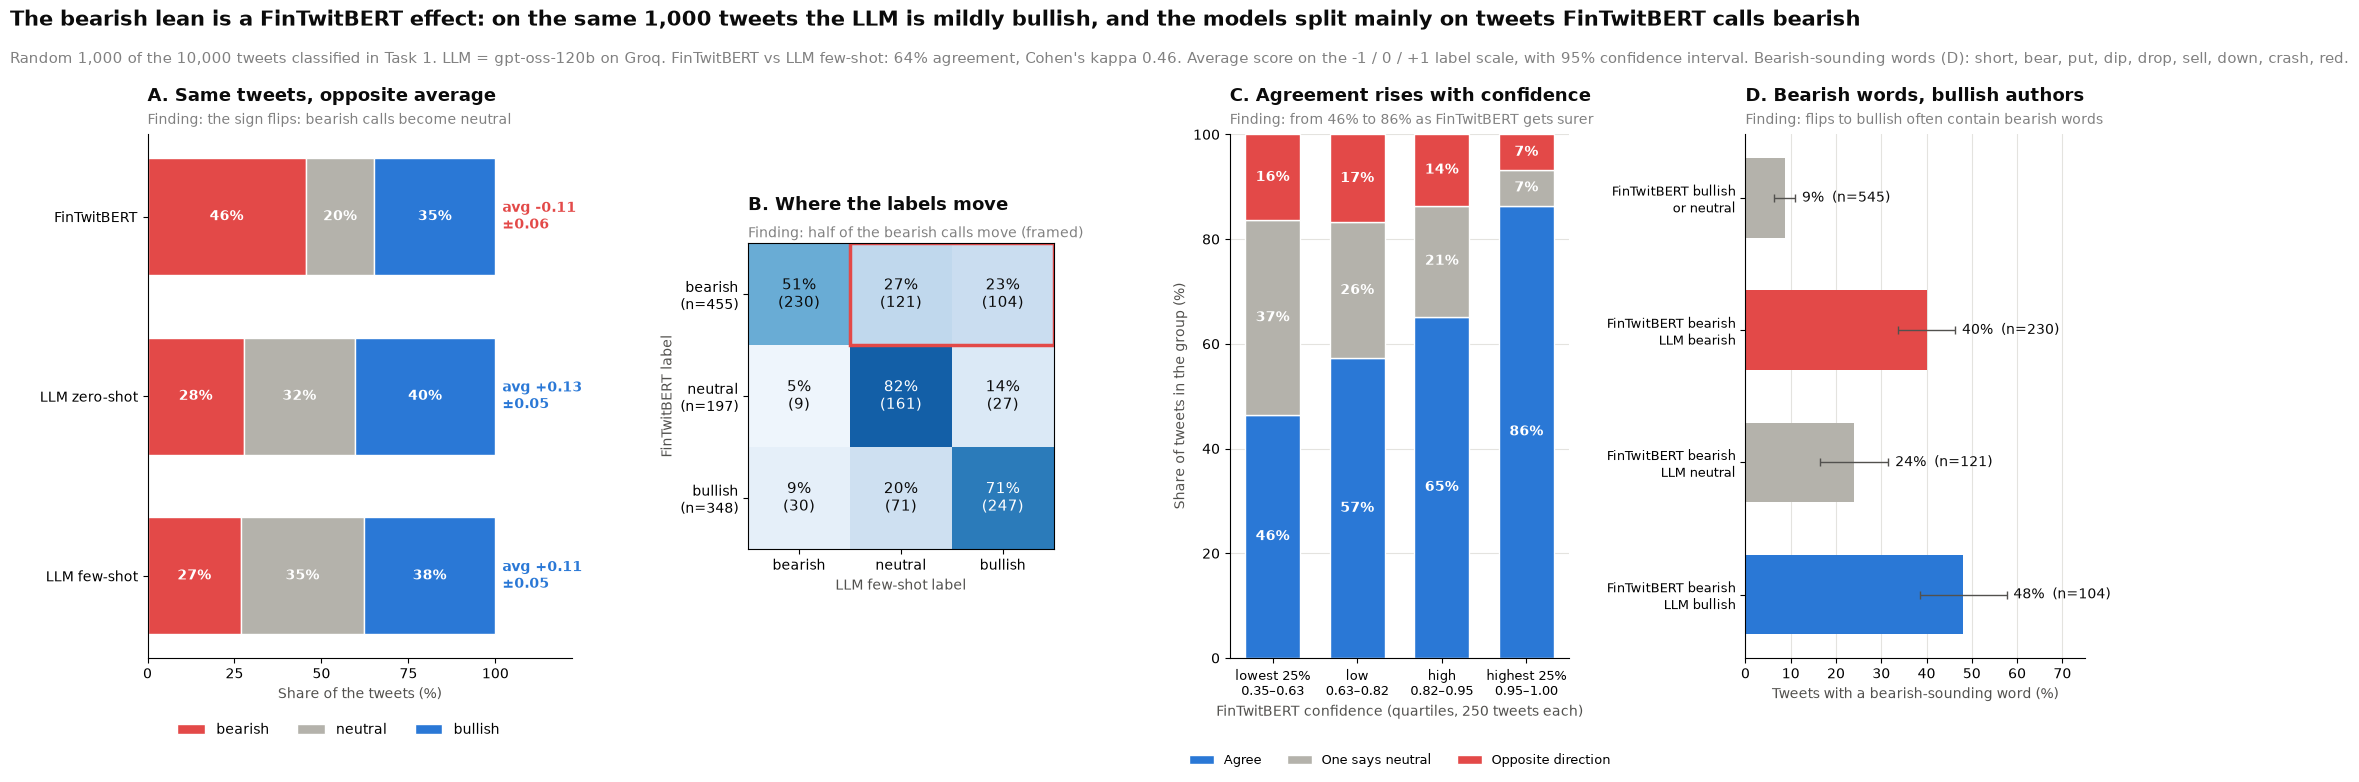

In [ ]:
LABELS = ['bearish', 'neutral', 'bullish']                                    # order used in every panel
LAB_COLORS = {'bearish': '#e34948', 'neutral': '#b4b2ab', 'bullish': '#2a78d6'}
MODELS = {'ft': 'FinTwitBERT', 'llm_zero': 'LLM zero-shot', 'llm_few': 'LLM few-shot'}
INK, INK_2, GRID = '#0b0b0b', '#52514e', '#e4e3df'
BEAR_WORDS = r'(?i)\b(?:shorts?|shorting|shorted|bears?|bearish|puts?|dips?|drop\w*|down|sell\w*|crash\w*|red)\b'  # words that sound bearish

n = len(df)
kappa = cohen_kappa_score(df['ft'], df['llm_few'])

fig, axes = plt.subplots(1, 4, figsize=(25, 6.8), gridspec_kw={'width_ratios': [1.25, 0.9, 1, 1], 'wspace': 0.5})
ax1, ax2, ax3, ax4 = axes
fig.text(0.07, 1.04, f'The bearish lean is a FinTwitBERT effect: on the same {n:,} tweets the LLM is mildly bullish, '
         'and the models split mainly on tweets FinTwitBERT calls bearish', fontsize=15, fontweight='bold', color=INK)
fig.text(0.07, 0.985, f'Random 1,000 of the 10,000 tweets classified in Task 1. LLM = gpt-oss-120b on Groq. '
         f'FinTwitBERT vs LLM few-shot: {df["agree"].mean():.0%} agreement, Cohen\'s kappa {kappa:.2f}. '
         'Average score on the -1 / 0 / +1 label scale, with 95% confidence interval. Bearish-sounding words (D): short, bear, put, dip, drop, sell, down, crash, red.', fontsize=10.5, color='grey')

def panel_title(ax, title, finding):
    ax.set_title(title, loc='left', fontsize=13, fontweight='bold', color=INK, pad=24)
    ax.text(0, 1.02, f'Finding: {finding}', transform=ax.transAxes, fontsize=10, color='grey')

# Panel A: label shares and average score for each model
shares = pd.DataFrame({name: df[col].value_counts(normalize=True) for col, name in MODELS.items()}).T[LABELS] * 100
left = np.zeros(len(shares))
for lab in LABELS:
    ax1.barh(shares.index, shares[lab], left=left, color=LAB_COLORS[lab], label=lab, edgecolor='white', height=0.65)
    for y, (l, w) in enumerate(zip(left, shares[lab])):
        ax1.text(l + w / 2, y, f'{w:.0f}%', ha='center', va='center', color='white', fontsize=10, fontweight='bold')
    left += shares[lab].values
for y, col in enumerate(MODELS):                                              # average score +- 95% CI at the end of each bar
    sc = df[col].map(LABEL_TO_SCORE)
    ci = 1.96 * sc.std() / np.sqrt(len(sc))
    ax1.text(102, y, f'avg {sc.mean():+.2f}\n±{ci:.2f}', va='center', fontsize=10,
             color=LAB_COLORS['bearish'] if sc.mean() < 0 else LAB_COLORS['bullish'], fontweight='bold')
ax1.invert_yaxis(); ax1.set_xlim(0, 122); ax1.set_xticks([0, 25, 50, 75, 100])
ax1.set_xlabel('Share of the tweets (%)', color=INK_2)
ax1.legend(ncol=3, frameon=False, loc='upper center', bbox_to_anchor=(0.45, -0.1))
panel_title(ax1, 'A. Same tweets, opposite average', 'the sign flips: bearish calls become neutral')

# Panel B: for each FinTwitBERT label, what the LLM says
ct = pd.crosstab(df['ft'], df['llm_few'], normalize='index').loc[LABELS, LABELS] * 100
counts = pd.crosstab(df['ft'], df['llm_few']).loc[LABELS, LABELS]
ax2.imshow(ct.values, cmap='Blues', vmin=0, vmax=100)
for i in range(3):
    for j in range(3):
        ax2.text(j, i, f'{ct.iat[i, j]:.0f}%\n({counts.iat[i, j]})', ha='center', va='center', fontsize=10.5,
                 color='white' if ct.iat[i, j] > 55 else INK)
ax2.add_patch(plt.Rectangle((0.5, -0.5), 2, 1, fill=False, edgecolor=LAB_COLORS['bearish'], linewidth=2.5))  # frame the bearish -> not bearish cells
ax2.set_xticks(range(3), LABELS); ax2.set_yticks(range(3), [f'{l}\n(n={counts.loc[l].sum()})' for l in LABELS])
ax2.set_xlabel('LLM few-shot label', color=INK_2); ax2.set_ylabel('FinTwitBERT label', color=INK_2)
panel_title(ax2, 'B. Where the labels move', 'half of the bearish calls move (framed)')

# Panel C: agreement and type of disagreement by FinTwitBERT confidence
kind = np.select([df['agree'],
                  (df['ft'] == 'neutral') | (df['llm_few'] == 'neutral')],
                 ['Agree', 'One says neutral'], 'Opposite direction')
comp = pd.crosstab(df['ft_conf_bin'], kind, normalize='index')[['Agree', 'One says neutral', 'Opposite direction']] * 100
ranges = df.groupby('ft_conf_bin', observed=True)['confidence'].agg(['min', 'max'])
bottom = np.zeros(4)
for k, c in zip(comp.columns, ['#2a78d6', '#b4b2ab', '#e34948']):
    ax3.bar(range(4), comp[k], bottom=bottom, color=c, width=0.65, label=k, edgecolor='white')
    for x, (b, h) in enumerate(zip(bottom, comp[k])):
        if h > 6:
            ax3.text(x, b + h / 2, f'{h:.0f}%', ha='center', va='center', color='white', fontsize=10, fontweight='bold')
    bottom += comp[k].values
ax3.set_xticks(range(4), [f'{q}\n{lo:.2f}–{hi:.2f}' for q, (lo, hi) in zip(comp.index, ranges.values)], fontsize=9)
ax3.set_ylim(0, 100); ax3.set_ylabel('Share of tweets in the group (%)', color=INK_2)
ax3.set_xlabel('FinTwitBERT confidence (quartiles, 250 tweets each)', color=INK_2)
ax3.legend(ncol=3, frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.16), fontsize=9)
panel_title(ax3, 'C. Agreement rises with confidence', 'from 46% to 86% as FinTwitBERT gets surer')

# Panel D: do bearish-sounding words explain the flips?
df['bear_words'] = df['clean'].str.contains(BEAR_WORDS)
groups = {'FinTwitBERT bullish\nor neutral':        df['ft'] != 'bearish',
          'FinTwitBERT bearish\nLLM bearish':        (df['ft'] == 'bearish') & (df['llm_few'] == 'bearish'),
          'FinTwitBERT bearish\nLLM neutral':        (df['ft'] == 'bearish') & (df['llm_few'] == 'neutral'),
          'FinTwitBERT bearish\nLLM bullish':        (df['ft'] == 'bearish') & (df['llm_few'] == 'bullish')}
share = pd.Series({g: df.loc[m, 'bear_words'].mean() * 100 for g, m in groups.items()})
sizes = pd.Series({g: m.sum() for g, m in groups.items()})
ci_w = 1.96 * np.sqrt(share / 100 * (1 - share / 100) / sizes) * 100
ax4.barh(range(4), share.values, xerr=ci_w.values, color=['#b4b2ab', '#e34948', '#b4b2ab', '#2a78d6'], height=0.6,
         error_kw={'ecolor': INK_2, 'elinewidth': 1, 'capsize': 3})
for y, (v, c, s) in enumerate(zip(share.values, ci_w.values, sizes.values)):
    ax4.text(v + c + 1.5, y, f'{v:.0f}%  (n={s})', va='center', fontsize=10, color=INK)
ax4.set_yticks(range(4), share.index, fontsize=9.5); ax4.invert_yaxis()
ax4.set_xlim(0, 75); ax4.set_xlabel('Tweets with a bearish-sounding word (%)', color=INK_2)
panel_title(ax4, 'D. Bearish words, bullish authors', 'flips to bullish often contain bearish words')

for ax in (ax1, ax3, ax4):
    ax.spines[['top', 'right']].set_visible(False)
for ax in (ax3, ax4):
    ax.grid(axis='x' if ax is ax4 else 'y', color=GRID, linewidth=0.8); ax.set_axisbelow(True)
plt.show()

FinTwitBERT and the LLM agree on 64% of the 1,000 tweets (moderate kappa at 0.46). The zero-shot and few-shot LLM agree on 89%, so providing examples in the prompt does not improve accuracy.

On the same tweets, the average sentiment flips sign: −0.11 with FinTwitBERT versus +0.11 with the LLM.
- The confidence intervals don't overlap, so the difference is real.
- The change comes almost entirely from the bearish class, which drops from 46% to 27% of tweets, while neutral rises from 20% to 35% with percent of bullish sentiment barely moving.
- The LLM doesn't see more optimism, just less pessimism.

The LLM confirms only half of FinTwitBERT's bearish calls, relabelling the rest as neutral (27%) or bullish (23%). The reverse almost never happens: only 9% of FinTwitBERT's bullish tweets become bearish.

Agreement rises from 46% in the least confident quartile to 86% in the most confident. But opposite-direction errors persist (14–17%) even at fairly high confidence. That's why removing ambiguous tweets in Step 1.7 couldn't detect the bias.

One reason for this trend is the vocabulary. Words like short, bear, put, dip, or sell appear in 48% of the tweets FinTwitBERT calls bearish but the LLM calls bullish, versus 9% of other tweets. FinTwitBERT reacts to these words regardless of the author's position. For example, it reads "will be fun to see if $TSLA shorts are burned again" as bearish, although the author is bullish.

The LLM has its own weakness. It's more cautious and sometimes calls clearly bullish tweets neutral ("$DIS go green"). Its errors pull the average toward zero, while FinTwitBERT's errors often point in the wrong direction.

**Conclusion:** the bearish lean from Task 1 is mainly a FinTwitBERT bias, not a feature of StockTwits, which revises our Step 1.8 conclusion. The overall level of sentiment is model-dependent. Analyses based on relative changes, like Test 2, are much less affected. Step 1.9.5 checks whether the other Task 1 findings, such as index products being the most bearish, still hold with the LLM labels.

#### *1.9.5 Redo the key Task 1 findings with the LLM labels*

In [ ]:
#### 5) Redo the key Task 1 findings with the LLM labels
INDEX = ['SPY', 'QQQ', 'DIA', 'VIX']                                          # market-wide products (as in Task 1)

def avg_ci(s):
    """Average on the -1/0/+1 scale, 95% CI half-width, and number of tweets."""
    s = s.map(LABEL_TO_SCORE)
    return pd.Series({'avg': s.mean(), 'ci': 1.96 * s.std() / np.sqrt(len(s)), 'n': len(s)})

# a) Index products vs single stocks (a tweet filed under several stocks counts for each, as in Task 1)
by_group = df[['message_id', 'ft', 'llm_few']].merge(tweet_stock, on='message_id')
by_group['group'] = np.where(by_group['symbol'].isin(INDEX), 'Index products', 'Single stocks')
groups = pd.concat({m: by_group.groupby('group')[m].apply(avg_ci).unstack()
                    for m in ['ft', 'llm_few']}, axis=1)
display(groups.round(3))

for m, name in [('ft', 'FinTwitBERT'), ('llm_few', 'LLM few-shot')]:            # gap between the two groups, per model
    gap = groups.loc['Index products', (m, 'avg')] - groups.loc['Single stocks', (m, 'avg')]
    print(f'{name:<13} index minus single stocks: {gap:+.3f}')

# b) By year
by_year = pd.concat({m: df.groupby(df['datetime'].dt.year)[m].apply(avg_ci).unstack()
                     for m in ['ft', 'llm_few']}, axis=1)
display(by_year.round(3))
print('Years where the LLM average is below zero:', (by_year[('llm_few', 'avg')] < 0).sum(), 'of', len(by_year))

ft               llm_few              
                  avg     ci      n     avg     ci      n
group                                                    
Index products -0.324  0.109  204.0  -0.025  0.099  204.0
Single stocks  -0.070  0.057  951.0   0.136  0.051  951.0

FinTwitBERT   index minus single stocks: -0.253
LLM few-shot  index minus single stocks: -0.160


ft               llm_few              
            avg     ci      n     avg     ci      n
datetime                                           
2009     -1.000    NaN    1.0   0.000    NaN    1.0
2010     -0.667  0.653    3.0  -0.333  1.307    3.0
2011     -0.111  0.416   18.0   0.167  0.363   18.0
2012      0.000  0.370   23.0  -0.043  0.337   23.0
2013     -0.136  0.229   59.0   0.085  0.203   59.0
2014     -0.098  0.213   61.0   0.066  0.183   61.0
2015     -0.147  0.202   68.0   0.044  0.156   68.0
2016     -0.122  0.154  123.0   0.081  0.137  123.0
2017     -0.182  0.191   77.0   0.117  0.181   77.0
2018     -0.174  0.131  184.0   0.043  0.123  184.0
2019      0.000  0.130  193.0   0.192  0.113  193.0
2020     -0.089  0.127  190.0   0.168  0.115  190.0

Years where the LLM average is below zero: 2 of 12


The patterns seen in the first run of Task 1 are persistent as well with the LLM, but the level is not.

Both models find index products more bearish than single stocks. The gap shrinks from −0.25 with FinTwitBERT to −0.16 with the LLM.

But the interpretation changes in relation to index products and single stocks. FinTwitBERT shows index products as bearish (−0.32) and single stocks as mildly bearish (−0.07). The LLM shows index products as neutral (−0.03 ± 0.10, where the interval includes zero), and single stocks as mildly bullish (+0.14 ± 0.05). So the Task 1 finding shifts from seeing index products as more bearish to being less positive than single stocks.

It's also telling that the correction is larger for index products (+0.30) than for single stocks (+0.21). That fits the keyword explanation from Step 1.9.4: index tweets are full of words like puts, shorts, and hedges, which is exactly where FinTwitBERT overreacts.

In terms of yearly data, it seems to be stable across both models, yet the sign shifts in later years. Here, we ignore 2009–2012, which have only 1 to 23 tweets, an insignificant amount to come to conclusions. From 2013 onward, FinTwitBERT is negative or zero every year, while the LLM is positive every year (between +0.04 and +0.19). The two lines move roughly in parallel, with the LLM about 0.2 higher each year, which is the same shift we measured in Step 1.9.4. Neither model shows a trend or a single year driving the result, so "sentiment is stable over time" holds. "Negative in every year" turns out to be a FinTwitBERT-specific finding.

Bottom line for Step 1.9.5 is that the relative findings from Task 1 don't depend on the model.
Index products are less positive than single stocks, and sentiment is stable over time. Overall, we see that StockTwits is bearish, and the strength depends on the model. With the LLM, the sample is mildly bullish overall, with index products close to neutral.

# 4. Text processing, vocabulary and word clouds

### ***Step 2.1:*** *Does FinTwitBERT read emojis?*

To count words and build word clouds we need the words in standard form. We work on the 10,000 tweets classified by FinTwitBERT, since word clouds require the presence of sentiment labels. We convert emojis and emoticons to words (🚀 → "rocket", :) → "smile"), shorten elongated words ("soooo" → "so"), keep hashtag words without the #, and remove mentions, numbers and punctuation. Tickers are kept and written in uppercase ($amzn → $AMZN), and capital letters are kept. The result is stored in a new column, text_norm, so the original clean text used by the model is unchanged.

In [ ]:
#checks the 15 most common emojis in the sample and shows, for each one, whether FinTwitBERT knows it or sees an "unknown" token instead
emoji_counts = Counter(e['emoji'] for t in sample['clean'] for e in emoji.emoji_list(t))  # every emoji in the sample, counted
tok = fintwit.tokenizer                                                       # the tokenizer the model uses to read text

rows = []
for e, n in emoji_counts.most_common(15):                                     # the 15 most frequent emojis
    pieces = tok.tokenize(e)                                                  # how the model cuts this emoji into pieces it knows
    rows.append({'emoji': e,
                 'name': emoji.demojize(e),                                   # its name, e.g. :rocket:
                 'times in sample': n,                                        # how often it appears
                 'model sees': pieces,                                        # what the model actually reads
                 'known': tok.unk_token not in pieces})                       # True unless the model sees [UNK] (= unknown)
check = pd.DataFrame(rows)
display(check)

known_share = (check['times in sample'] * check['known']).sum() / check['times in sample'].sum()  # weighted by frequency
print(f'Share of emoji occurrences (top 15) the model can read: {known_share:.0%}')

# Normalize the text for word counts and word clouds (the model's input 'clean' is left unchanged)
EMOTICONS = {                                                                 # common text emoticons -> words
    r'(?<!\S)[:;=]-?\)+(?!\S)':  ' smile ',
    r'(?<!\S)[:;=]-?\(+(?!\S)':  ' sad ',
    r'(?<!\S)[:;=]-?D+(?!\S)':   ' laugh ',
    r'(?<!\S)[:;=]-?[pP](?!\S)': ' tongue ',
    r'(?<!\S)<3+(?!\S)':         ' heart ',
}
TICKER = re.compile(r'\$[A-Za-z][A-Za-z.]*')                                  # $ + letters, e.g. $amzn, $BRK.B

def normalize_token(tok):
    """One word -> its standard form ('' if it should be removed)."""
    if TICKER.fullmatch(tok.rstrip('.')):                                     # a ticker...
        return tok.rstrip('.').upper()                                        # ...kept, in uppercase ($amzn -> $AMZN)
    if any(ch.isdigit() for ch in tok):                                       # numbers and prices (300, 10k, 2nd, $95)...
        return ''                                                             # ...removed
    tok = tok.replace("'", '')                                                # apostrophes: don't -> dont
    return re.sub(r'[^A-Za-z_]+', ' ', tok).strip(' _')                       # punctuation -> space; keep letters and _ (emoji names)

def normalize(text):
    """Standard form: emojis/emoticons as words, no mentions/numbers/punctuation, tickers in uppercase."""
    for pattern, word in EMOTICONS.items():                                   # :) -> smile, :( -> sad ...
        text = re.sub(pattern, word, text)
    text = emoji.demojize(text, delimiters=(' ', ' '))                        # 🚀 -> ' rocket ', 😂 -> ' face_with_tears_of_joy '
    text = re.sub(r'@\w+', ' ', text)                                         # remove mentions (@user)
    text = re.sub(r'#(\w+)', r' \1 ', text)                                   # hashtags: keep the word, drop the # (#BTFD -> BTFD)
    text = re.sub(r'([A-Za-z])\1{2,}', r'\1\1', text)                         # elongated words: soooo -> soo
    words = (normalize_token(t) for t in text.split())                        # standardize word by word
    return re.sub(r'\s+', ' ', ' '.join(words)).strip()                       # many spaces -> one

sample['text_norm'] = sample['clean'].map(normalize)                          # new column
print(f"Tweets empty after normalization: {(sample['text_norm'] == '').sum()}")
display(sample[['clean', 'text_norm']].sample(8, random_state=3))

,emoji,name,times in sample,model sees,known
0,🚀,:rocket:,128,[[UNK]],False
1,😂,:face_with_tears_of_joy:,91,[[UNK]],False
2,🔥,:fire:,58,[[UNK]],False
3,🤑,:money-mouth_face:,47,[[UNK]],False
4,🤣,:rolling_on_the_floor_laughing:,33,[[UNK]],False
5,🐻,:bear:,30,[[UNK]],False
6,💰,:money_bag:,29,[[UNK]],False
7,🍀,:four_leaf_clover:,24,[[UNK]],False
8,🤔,:thinking_face:,21,[[UNK]],False
9,💵,:dollar_banknote:,20,[[UNK]],False


Share of emoji occurrences (top 15) the model can read: 0%
Tweets empty after normalization: 0


,clean,text_norm
1226143,@USER @USER @USER @USER @USER @USER @USER @USER @USER Markets always D same never Change $SPY $VIX,Markets always D same never Change $SPY $VIX
2795675,$AMZN today = a nightmare for swing traders: 3 consecutive Harmonic Figures leading nowhere,$AMZN today a nightmare for swing traders consecutive Harmonic Figures leading nowhere
5432620,$TSLA let us have at least 198,$TSLA let us have at least
546201,#Update(12) $DIS Sep-28 111 Calls Up +267%. sincealerted on: Sep 13. View Details:,Update $DIS Calls Up sincealerted on Sep View Details
3257636,$nflx !120.50 got filled,$NFLX got filled
3301755,$NFLX not like it has not already been ugly from Ah an PM fake out s,$NFLX not like it has not already been ugly from Ah an PM fake out s
1964128,"@USER starting to run for cover if they still can? A close above $95 could send them into hibernation. The party is over here, $AAPL up.",starting to run for cover if they still can A close above could send them into hibernation The party is over here $AAPL up
2681253,"$AMZN will missed the ER for sure, Big holders have reaction before G",$AMZN will missed the ER for sure Big holders have reaction before G


**Emoji check:** FinTwitBERT's tokenizer does not recognise any of the 15 most common emojis (all become [UNK]), so the model ignored them in Task 1. We therefore reclassify the tweets containing emojis after converting the emojis to words (🚀 → "rocket"), and measure how much the results change.

In [ ]:
def emojis_to_words(text):
    """Replace each emoji by its name in plain words, so the model can read it (🚀 -> ' rocket ')."""
    text = emoji.demojize(text, delimiters=(' ', ' '))                        # 😂 -> ' face_with_tears_of_joy '
    return re.sub(r'(?<=\w)_(?=\w)', ' ', text)                               # underscores between letters -> spaces: 'face with tears of joy'

has_emoji = sample['clean'].map(lambda t: emoji.emoji_count(t) > 0)          # True if the tweet contains at least one emoji

# --- 1) Reclassify only the tweets that contain emojis (or reload the saved results) ---
EMOJI_FILE = 'fintwit_emoji_reclass.pkl'                                      # file where the new labels are saved
emoji_rows = sample[has_emoji].copy()                                         # the ~470 tweets with at least one emoji
emoji_rows['model_text_emoji'] = emoji_rows['model_text'].map(emojis_to_words)  # same model text, but emojis written as words

if os.path.exists(EMOJI_FILE):                                                # already computed in an earlier run?
    saved = pd.read_pickle(EMOJI_FILE)                                        # reload the new labels and scores
    emoji_rows[['label_emoji', 'score_emoji']] = saved.loc[emoji_rows.index, ['label_emoji', 'score_emoji']]
    print(f'Reloaded from {EMOJI_FILE}')
else:                                                                         # first run: compute and save
    probs_emoji = run_fintwit(emoji_rows['model_text_emoji'].tolist())        # run FinTwitBERT again on these tweets
    emoji_rows['label_emoji'] = probs_emoji.idxmax(axis=1).str.lower().values # new predicted label
    emoji_rows['score_emoji'] = (probs_emoji['BULLISH'] - probs_emoji['BEARISH']).values  # new sentiment score
    emoji_rows[['label_emoji', 'score_emoji']].to_pickle(EMOJI_FILE)          # save so we never have to rerun
    print(f'Computed and saved to {EMOJI_FILE}')

# --- 2) How much changes for these tweets? ---
changed = emoji_rows['label'] != emoji_rows['label_emoji']                    # True if the label changed
print(f'Tweets with emojis: {len(emoji_rows)}')
print(f'Label changed: {changed.mean():.1%}')
print(f"Average score of these tweets: {emoji_rows['score'].mean():+.3f} (raw emojis) -> {emoji_rows['score_emoji'].mean():+.3f} (emojis as words)")
display(pd.crosstab(emoji_rows['label'], emoji_rows['label_emoji'],           # table: old label (rows) vs new label (columns)
                    rownames=['raw emojis'], colnames=['emojis as words']))

# --- 3) Examples of tweets whose label changed ---
display(emoji_rows.loc[changed, ['model_text', 'label', 'label_emoji']].sample(min(8, changed.sum()), random_state=1))

# --- 4) Effect on the overall average ---
new_scores = sample['score'].copy()                                           # copy of all 10,000 scores
new_scores.loc[emoji_rows.index] = emoji_rows['score_emoji']                  # replace the scores of the emoji tweets with the new ones
print(f"Overall average: {sample['score'].mean():+.3f} (raw emojis) -> {new_scores.mean():+.3f} (emojis as words)")

Reloaded from fintwit_emoji_reclass.pkl
Tweets with emojis: 470
Label changed: 24.7%
Average score of these tweets: +0.108 (raw emojis) -> -0.108 (emojis as words)


emojis as words,bearish,bullish,neutral
raw emojis,,,
bearish,173,4,7
bullish,43,150,50
neutral,6,6,31


,model_text,label,label_emoji
1445106,$AAPL 7 SEVEN 7 TRADING DAYS LEFT IN THE YEAR 😎,bullish,neutral
4057426,$TSLA send it 🚀🤑,bullish,bearish
2522606,$AMZN nasdaq crosses 8k 🙏🙏 see this back to 2200?,bullish,neutral
4838714,$TSLA Tesla semi pro-driver 👍🏻,bullish,neutral
3879387,$TSLA Woahhhhhh. 😱,neutral,bearish
2907396,$NFLX bu bu bu but 😂😂😂,bullish,neutral
3889776,$TSLA 🥵🥵,bullish,bearish
4433565,$TSLA 🤣🤣🤣,bullish,neutral


Overall average: -0.110 (raw emojis) -> -0.120 (emojis as words)


To test the importance of information carried by the emojis, we reclassified the 470 tweets containing emojis (4.7% of the sample) after converting emojis to their names (🚀 → "rocket"). A quarter of the messages change label, but the examples show that the conversion often introduces errors ("send it 🚀🤑" becomes bearish). Emoji names are literal descriptions ("face screaming in fear", "exploding head"), so while negative connotation can be imposed by the description, the usage in the text is intended to be positive. We therefore stick with the original classification. The overall average barely changes (−0.110 vs −0.120), so our conclusions are unaffected.

### ***Step 2.2:*** *Tokenization, stopword removal and lemmatization*


Reiterating the constraints set up at Step 1.3:

- Tickers are kept exactly as they are, not removed or lemmatized. Known tickers written without a dollar sign get it back ("AMZN" → "$AMZN").
- Words written entirely in capitals ("SELL", "GOOD") stay in capitals, since shouting carries meaning. Words with only a first capital letter ("Surprised" at the start of a sentence) are lowercased, because that capital only means "start of a sentence". Otherwise "Surprised" and "surprised" would count as two different words.
- Directional words ("up", "down", "above", "below", "over", "under") and negations ("not", "no", "dont", "cant"...) are kept. NLTK treats them as filler, but in finance, direction is the core signal ("SPY up 2%"), and removing a negation can reverse the meaning of a tweet.
- We add apostrophe-free forms ("im", "thats"), since Step 2.1 removed apostrophes, and a few slang fillers ("lol", "gonna", "u").
- Option and market words ("calls", "puts", "shorts", "bulls", "bears") are protected from lemmatization, so they are not turned into verbs. Common expressions ("trailing stop", "buy the dip", "short squeeze", "all time high") are merged into single tokens so they count as one concept.

In [ ]:

for pkg in ['stopwords', 'wordnet', 'omw-1.4']:                               # download the resources once
    nltk.download(pkg, quiet=True)

STOPWORDS = set(stopwords.words('english'))                                   # ~180 common words: the, is, and, we...
STOPWORDS |= {w.replace("'", '') for w in STOPWORDS}                          # add apostrophe-free versions: don't -> dont
STOPWORDS |= {'im', 'ive', 'id', 'ill', 'youre', 'hes', 'shes', 'thats', 'theres', 'lets',  # extra contractions
              'u', 'ur', 'gonna', 'wanna', 'gotta', 'yeah', 'lol'}            # common slang fillers
STOPWORDS -= {'up', 'down', 'above', 'below', 'over', 'under'}                # keep directional words (meaningful in finance)
STOPWORDS -= {'not', 'no', 'nor', 'dont', 'doesnt', 'didnt', 'isnt', 'arent', 'wasnt', 'werent',   # keep negations: they flip the meaning
              'cant', 'couldnt', 'wont', 'wouldnt', 'shouldnt', 'havent', 'hasnt', 'hadnt'}
lemmatizer = WordNetLemmatizer()                                              # create the lemmatizer

# --- Finance-specific fixes ---
FINANCE_PHRASES = {                                                           # multi-word expressions glued into one token
    r'trailing stops?':  'trailing_stop',                                     # ? = the s is optional (stop or stops)
    r'stop loss(es)?':   'stop_loss',
    r'buy(ing)? the dip': 'buy_the_dip',
    r'short squeeze':    'short_squeeze',
    r'price targets?':   'price_target',
    r'all time highs?':  'all_time_high',
    r'bull traps?':      'bull_trap',
    r'bear traps?':      'bear_trap',
    r'dead cat bounce':  'dead_cat_bounce',
    r'to the moon':      'to_the_moon',
}
PROTECTED = {'calls', 'puts', 'shorts', 'longs', 'bulls', 'bears',            # finance words NOT lemmatized (calls = options, not "to call")
             'options', 'futures', 'earnings', 'sales'}
KNOWN_TICKERS = set(tweet_stock['symbol'].unique()) - {'T', 'V', 'HD', 'PG'}  # our dataset's tickers, minus ambiguous short ones

def lemmatize_word(word):
    """Dictionary form of a word: try it as a verb first (buying -> buy), then as a noun (stocks -> stock)."""
    lemma = lemmatizer.lemmatize(word, pos='v')                               # try as a verb
    return lemma if lemma != word else lemmatizer.lemmatize(word, pos='n')    # if unchanged, try as a noun

def process_token(tok):
    """Keep tickers; add $ to known tickers written without it; keep phrases; drop stopwords; lemmatize the rest."""
    if tok.startswith('$'):                                                   # a ticker ($TSLA)...
        return tok                                                            # ...kept exactly as it is
    if tok in KNOWN_TICKERS:                                                  # a known ticker written without $ (AMZN)...
        return '$' + tok                                                      # ...gets its $ back ($AMZN)
    if '_' in tok:                                                            # a glued phrase (buy_the_dip) or an emoji name (face_with_tears_of_joy)...
        return tok                                                            # ...kept as it is
    shout = tok.isupper() and len(tok) > 1                                    # True if the whole word is in capitals (SELL)
    low = tok.lower()                                                         # lowercase version, used for lookups
    if low in STOPWORDS:                                                      # a stopword...
        return None                                                           # ...is dropped
    lemma = low if low in PROTECTED else lemmatize_word(low)                  # protected finance words keep their form
    return lemma.upper() if shout else lemma                                  # back to capitals if it was shouted

def tokenize_tweet(text):
    """Glue finance phrases, split the tweet into words, and process each one."""
    for pattern, phrase in FINANCE_PHRASES.items():                           # each finance expression...
        text = re.sub(rf'\b{pattern}\b', phrase, text, flags=re.IGNORECASE)   # ...replaced by its glued version, ignoring upper/lower case
    tokens = (process_token(t) for t in text.split())                         # tokenization: split on spaces, process each word
    return [t for t in tokens if t]                                           # keep only the words that were not dropped

# --- Apply to the sample ---
sample['tokens'] = sample['text_norm'].map(tokenize_tweet)                    # new column: a list of words per tweet

# --- How much did stopword removal take out? ---
n_before = sample['text_norm'].str.split().str.len().sum()                    # total words before
n_after  = sample['tokens'].str.len().sum()                                   # total words after
print(f'Words before: {n_before:,} | after: {n_after:,} | removed as stopwords: {1 - n_after / n_before:.1%}')
print(f"Tweets with no words left: {(sample['tokens'].str.len() == 0).sum()}")

# --- Before / after examples ---
display(sample[['text_norm', 'tokens']].sample(8, random_state=5))

Words before: 147,656 | after: 96,616 | removed as stopwords: 34.6%
Tweets with no words left: 0


,text_norm,tokens
275333,$SPY $QQ $IWM $DIA $UVXY Fear Greed Index,"[$SPY, $QQ, $IWM, $DIA, $UVXY, fear, greed, index]"
5387329,trading $TSLA from an $AAPL chart is not a strategy I would suggest lol,"[trade, $TSLA, $AAPL, chart, not, strategy, would, suggest]"
922102,$VUZI Once the $VZ PR Details out shorts have nothing left gig is up $VZ not playing games here this is R E A L AR device battle $T VZ,"[$VUZI, $VZ, PR, detail, shorts, nothing, leave, gig, up, $VZ, not, play, game, r, e, l, AR, device, battle, $T, $VZ]"
4494944,$TSLA call time dashing_away,"[$TSLA, call, time, dashing_away]"
1227523,GOOD WATCH Seismic Shift What Could It Mean For Stocks $SPY $VXX $IWM $QQ $VIX,"[GOOD, WATCH, seismic, shift, could, mean, stock, $SPY, $VXX, $IWM, $QQ, $VIX]"
3346180,$NFLX i seem to have the right puts at Trailing stops in Enjoying the elevator ride down,"[$NFLX, seem, right, puts, trailing_stop, enjoy, elevator, ride, down]"
2793169,$AMZN should I buy some AMZN now Dont look like a good idea but still not sure,"[$AMZN, buy, $AMZN, dont, look, like, good, idea, still, not, sure]"
845729,$GOOGL Entered a few put spreads for earlier today The return on the premiums are rather good and I have over a buffer,"[$GOOGL, enter, put, spread, earlier, today, return, premium, rather, good, over, buffer]"


Tokenization and stopword removal reduce the sample from 142,016 to 96,214 words: about a third of all words (32.3%) were stopwords, and only one tweet is left with no words.

Some limits remain: singular option terms ("put spreads", "call time") cannot be distinguished from the verbs "put" and "call" without understanding the sentence, and the phrase list only covers the most common expressions.

### ***Step 2.3:*** *Number of Unique Words*

We count the number of different words (the vocabulary) after each cleaning stage, to show how much each step reduces the volume of words present, and look at the most frequent words.

,unique words,total words,used only once
1. Raw text,"30,512","156,672",70.3%
"2. After cleaning (HTML, links)","28,845","154,957",68.7%
"3. After normalization (emojis, punctuation, numbers)","15,669","147,656",53.8%
4. After stopwords + lemmatization,"10,419","96,616",52.4%


Final unique words: 10,419, of which tickers: 1,177
Final unique words if capitals were ignored: 9,583 (keeping capitals adds 836 words)


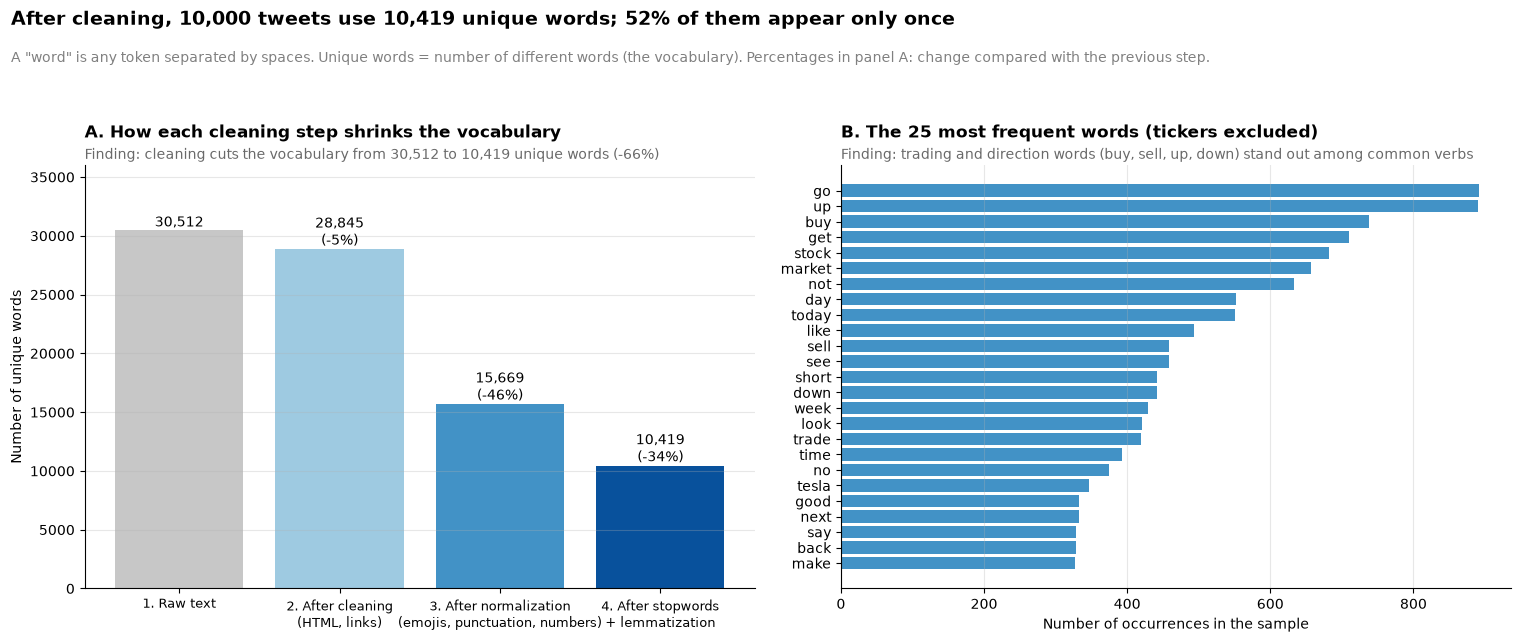

In [ ]:

def vocabulary(token_lists):
    """Count every word in a column of word lists: returns {word: number of occurrences}."""
    return Counter(w for tokens in token_lists for w in tokens)               # go through every word of every tweet

stages = {                                                                    # the vocabulary at each cleaning stage
    '1. Raw text':                       vocabulary(sample['message'].str.split()),     # original tweets, split on spaces
    '2. After cleaning\n(HTML, links)':  vocabulary(sample['clean'].str.split()),       # after Task 1 cleaning
    '3. After normalization\n(emojis, punctuation, numbers)': vocabulary(sample['text_norm'].str.split()),  # after Step 2.1
    '4. After stopwords\n+ lemmatization': vocabulary(sample['tokens']),                # after Step 2.2 (already lists of words)
}
final = stages['4. After stopwords\n+ lemmatization']                         # the final vocabulary

# --- 1) Summary table ---
summary = pd.DataFrame({name: {'unique words': len(v),                        # number of different words
                               'total words': sum(v.values()),                # total number of words
                               'used only once': sum(1 for c in v.values() if c == 1) / len(v)}  # share of words appearing once
                        for name, v in stages.items()}).T                     # one row per stage
summary.index = [i.replace('\n', ' ') for i in summary.index]                 # remove line breaks from the row names
display(summary.style.format({'unique words': '{:,.0f}', 'total words': '{:,.0f}', 'used only once': '{:.1%}'}))

# --- 2) Tickers and the effect of keeping capitals ---
lower_final = Counter()                                                       # final vocabulary if capitals were ignored
for w, c in final.items():
    lower_final[w if w.startswith('$') else w.lower()] += c                   # SELL and sell merged (tickers left as they are)
n_tickers = sum(1 for w in final if w.startswith('$'))                        # how many unique words are tickers
print(f'Final unique words: {len(final):,}, of which tickers: {n_tickers:,}')
print(f'Final unique words if capitals were ignored: {len(lower_final):,} '
      f'(keeping capitals adds {len(final) - len(lower_final):,} words)')

# --- 3) Figure ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5))                       # two panels side by side

# Panel A: vocabulary size at each stage
sizes = [len(v) for v in stages.values()]                                     # unique words per stage
bars = ax1.bar(range(len(sizes)), sizes, color=['#c7c7c7', '#9ecae1', '#4292c6', '#08519c'])  # one bar per stage, darker = cleaner
for i, (bar, n) in enumerate(zip(bars, sizes)):                               # write the value above each bar...
    label = f'{n:,}' if i == 0 else f'{n:,}\n({n / sizes[i - 1] - 1:+.0%})'   # ...plus the % change from the previous stage
    ax1.text(bar.get_x() + bar.get_width() / 2, n, label, ha='center', va='bottom', fontsize=10)
ax1.set_xticks(range(len(sizes)), list(stages.keys()), fontsize=9)            # stage names under the bars
ax1.set(ylabel='Number of unique words', ylim=(0, max(sizes) * 1.18))         # axis title, room above the bars for labels
ax1.set_title('A. How each cleaning step shrinks the vocabulary', loc='left', fontsize=12, fontweight='bold', pad=20)
ax1.text(0, 1.015, f'Finding: cleaning cuts the vocabulary from {sizes[0]:,} to {sizes[-1]:,} unique words ({sizes[-1] / sizes[0] - 1:+.0%})',
         transform=ax1.transAxes, fontsize=10, color='dimgrey')

# Panel B: most frequent words
top = [(w, c) for w, c in final.most_common() if not w.startswith('$')][:25][::-1]  # 25 most frequent non-ticker words, reversed so the biggest is on top
ax2.barh([w for w, _ in top], [c for _, c in top], color='#4292c6')           # horizontal bars
ax2.set(xlabel='Number of occurrences in the sample')                         # axis title
ax2.set_title('B. The 25 most frequent words (tickers excluded)', loc='left', fontsize=12, fontweight='bold', pad=20)
ax2.text(0, 1.015, 'Finding: trading and direction words (buy, sell, up, down) stand out among common verbs',
         transform=ax2.transAxes, fontsize=10, color='dimgrey')

for ax in (ax1, ax2):                                                         # same styling for both panels
    ax.grid(alpha=0.3, axis='y' if ax is ax1 else 'x'); ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(f'After cleaning, {len(sample):,} tweets use {len(final):,} unique words; {summary.iloc[-1]["used only once"]:.0%} of them appear only once',
             x=0.01, ha='left', fontsize=14, fontweight='bold')              # headline built from the real numbers
fig.text(0.01, 0.9, 'A "word" is any token separated by spaces. Unique words = number of different words (the vocabulary). '
         'Percentages in panel A: change compared with the previous step.', fontsize=10, color='grey')
fig.tight_layout(rect=(0, 0, 1, 0.88))                                        # arrange panels, room at the top for titles
plt.show()                                                                    # display

Cleaning reduces the vocabulary by almost two-thirds, from 30,512 to 11,110 unique words. We see that normalization is the most important step (−44%), because it merges variants of the same word into one. Stopword removal and lemmatization remove another 32%. Removing HTML codes and links changes the vocabulary little (−5%).

The vocabulary has a very long tail. 55% of the final words appear only once. 1,220 of the unique words are tickers, far more than our 25 stocks, since users mention many other companies. Keeping fully capitalised words adds only 842 words (8%).

Among the most frequent words, trading actions and market direction stand out (buy, sell, short, trade, up, down) alongside very common verbs (go, get, see). Negations ("not", "no") also rank high, because we kept them on purpose.

### ***Step 2.4:*** *Word clouds for bullish vs bearish tweets*

Using FinTwitBERT labels and keeping only clearly classified tweets, as borderline classifications will blur the view, we create word clouds. Tickers are left out as they are not sentiment words and may dominate the clouds.

The problem with plain word clouds: very common words ("go", "stock", "market", "buy") appear in both groups, therefore we draw two rows:
- Top row, most frequent words: the classic word cloud
- Bottom row, distinctive words: only words that are at least 1.5 times more frequent in one group than in the other, relative to the group's total number of words. For example, if "drop" makes up 0.3% of bearish words but only 0.1% of bullish words, it's 3× more typical of bearish tweets, so it goes in the bearish cloud.
- Words with fewer than 10 occurrences are ignored, because they're too rare to judge. This row shows what really separates the two groups.

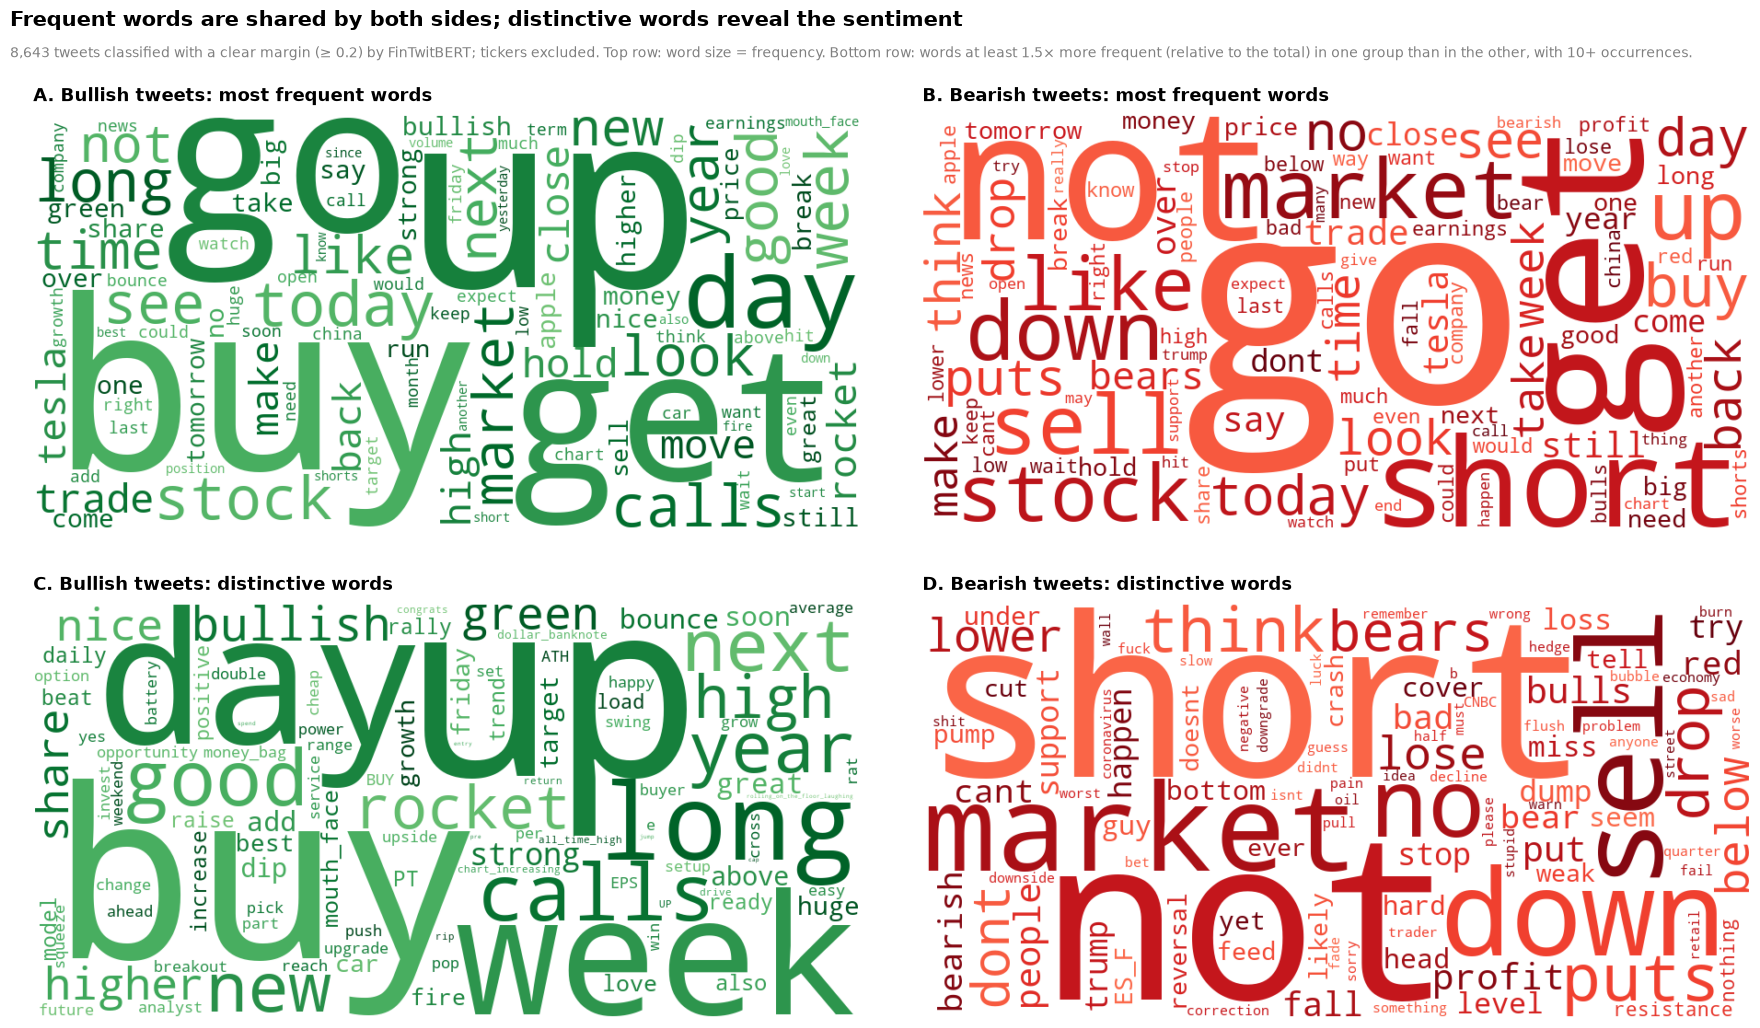

Most frequent words overall: go, up, buy, get, not, market, stock, sell, day, today
Distinctive words: 255 bullish, 260 bearish


In [ ]:

MIN_MARGIN = 0.2                                                              # keep only clearly classified tweets
MIN_COUNT = 10                                                                # ignore words with fewer than 10 occurrences in total
RATIO = 1.5                                                                   # "distinctive" = at least 1.5x more frequent in one group

clear = sample[sample['margin'] >= MIN_MARGIN]                                # tweets where the model clearly preferred one label

def word_counts(label):
    """Count the words (tickers excluded) of all clear tweets with a given label."""
    tokens = clear.loc[clear['label'] == label, 'tokens']                     # the word lists of those tweets
    return Counter(w for t in tokens for w in t if not w.startswith('$'))     # count every word except tickers

bull, bear = word_counts('bullish'), word_counts('bearish')                   # word counts for each group
n_bull, n_bear = sum(bull.values()), sum(bear.values())                       # total number of words in each group

def distinctive(a, n_a, b, n_b):
    """Words at least RATIO times more frequent (relative to the group's total) in group a than in group b."""
    out = {}
    for w, c in a.items():                                                    # each word of group a and its count
        if c + b.get(w, 0) < MIN_COUNT:                                       # too rare overall...
            continue                                                          # ...skip it
        ratio = (c / n_a) / ((b.get(w, 0) + 1) / n_b)                         # share in a divided by share in b (+1 avoids dividing by 0)
        if ratio >= RATIO:                                                    # clearly more typical of group a...
            out[w] = c                                                        # ...keep it, sized by its count
    return out

bull_only = distinctive(bull, n_bull, bear, n_bear)                           # words typical of bullish tweets
bear_only = distinctive(bear, n_bear, bull, n_bull)                           # words typical of bearish tweets

GREENS = LinearSegmentedColormap.from_list('greens', plt.cm.Greens(np.linspace(0.5, 1, 256)))  # greens without the palest shades (readable)
REDS   = LinearSegmentedColormap.from_list('reds',   plt.cm.Reds(np.linspace(0.5, 1, 256)))    # same for reds

def cloud(freqs, cmap):
    """Build a word cloud from a {word: count} dictionary."""
    return WordCloud(width=900, height=450, background_color='white', colormap=cmap,  # size, background, colours
                     max_words=100, prefer_horizontal=0.9, random_state=42).generate_from_frequencies(freqs)  # 100 words max, same layout every run

fig, axes = plt.subplots(2, 2, figsize=(18, 10.5),                           # 2 rows x 2 columns
                         gridspec_kw={'hspace': 0.18, 'wspace': 0.06})        # space between rows (hspace) and columns (wspace)
panels = [(axes[0, 0], bull, GREENS, 'A. Bullish tweets: most frequent words'),
          (axes[0, 1], bear, REDS,   'B. Bearish tweets: most frequent words'),
          (axes[1, 0], bull_only, GREENS, 'C. Bullish tweets: distinctive words'),
          (axes[1, 1], bear_only, REDS,   'D. Bearish tweets: distinctive words')]
for ax, freqs, cmap, title in panels:                                         # draw each of the 4 clouds
    ax.imshow(cloud(freqs, cmap), interpolation='bilinear')                   # show the cloud as an image
    ax.set_title(title, loc='left', fontsize=13, fontweight='bold', pad=10)   # bold panel title
    ax.axis('off')                                                            # no axes and no frame around the picture
fig.suptitle('Frequent words are shared by both sides; distinctive words reveal the sentiment',  # headline
             x=0.01, ha='left', fontsize=15, fontweight='bold')
fig.text(0.01, 0.935, f'{len(clear):,} tweets classified with a clear margin (≥ {MIN_MARGIN}) by FinTwitBERT; tickers excluded. '  # grey subtitle
         f'Top row: word size = frequency. Bottom row: words at least {RATIO}× more frequent (relative to the total) in one group '
         f'than in the other, with {MIN_COUNT}+ occurrences.', fontsize=10, color='grey')
fig.subplots_adjust(left=0.02, right=0.98, top=0.88, bottom=0.02)             # margins around the whole figure
plt.show()                                                                    # display

top_overall = [w for w, _ in (bull + bear).most_common(10)]                   # 10 most frequent words across both groups
print('Most frequent words overall:', ', '.join(top_overall))
print(f'Distinctive words: {len(bull_only)} bullish, {len(bear_only)} bearish')

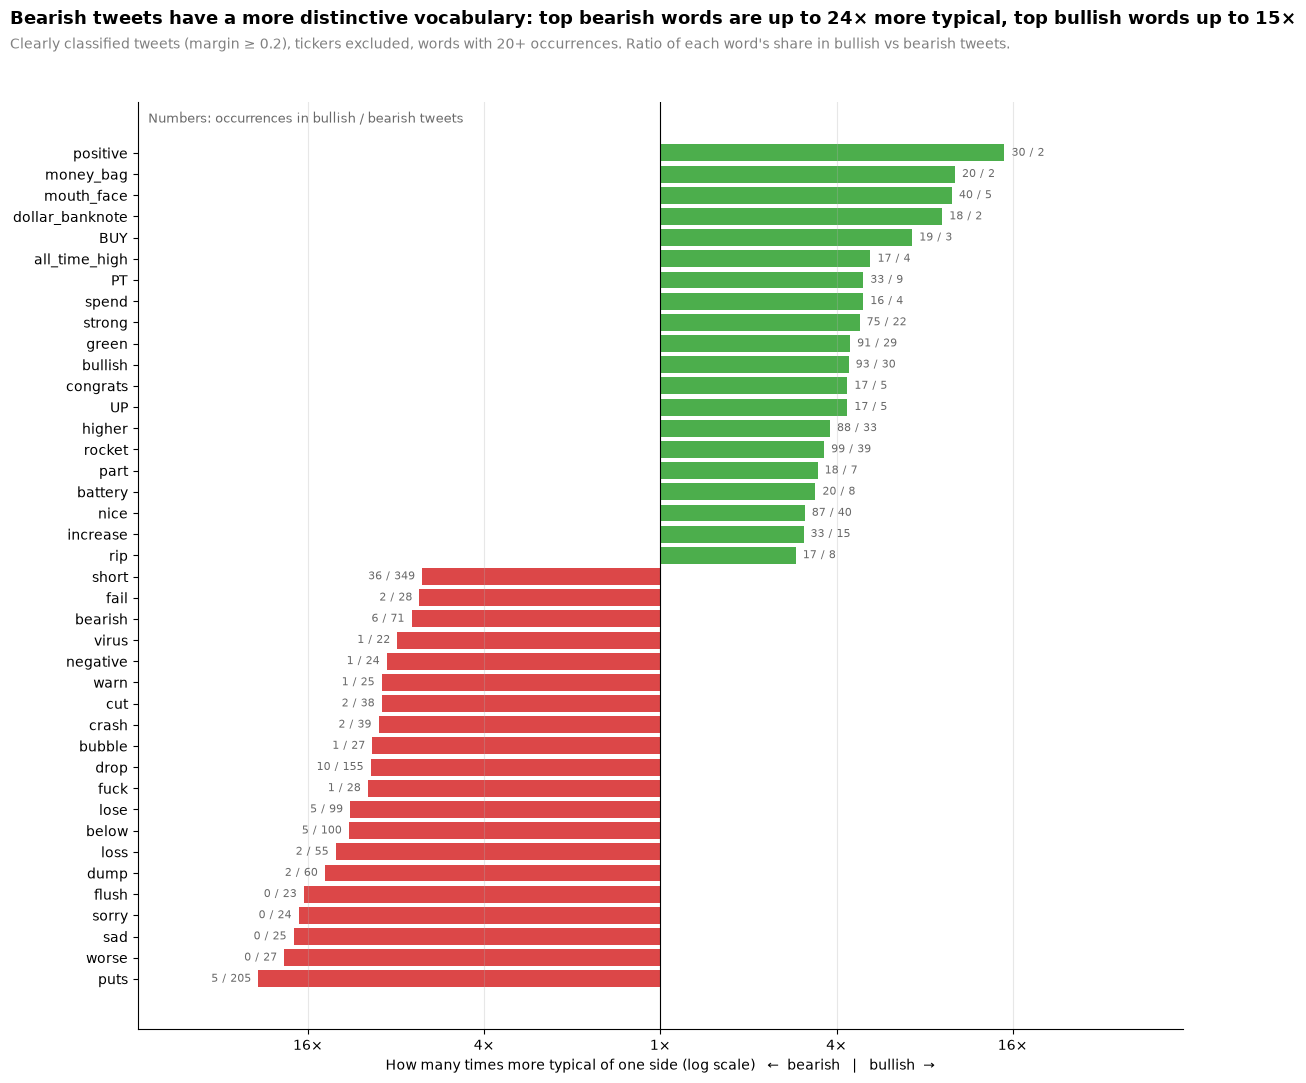

In [ ]:
MIN_TOTAL = 20                                                                # only words with at least 20 occurrences (reliable ratios)
TOP_N = 20                                                                    # number of words shown on each side

vocab = set(bull) | set(bear)                                                 # all words used in either group
V = len(vocab)                                                                # vocabulary size (used for smoothing)
rows = []
for w in vocab:                                                               # for every word...
    cb, cr = bull.get(w, 0), bear.get(w, 0)                                   # ...its count in bullish and bearish tweets
    if cb + cr < MIN_TOTAL:                                                   # too rare...
        continue                                                              # ...skip it
    log_ratio = np.log2(((cb + 1) / (n_bull + V)) / ((cr + 1) / (n_bear + V)))  # share in bullish / share in bearish, on a log2 scale (+1 avoids dividing by 0)
    rows.append({'word': w, 'bullish': cb, 'bearish': cr, 'log_ratio': log_ratio})
dist = pd.DataFrame(rows)                                                     # one row per word

top = pd.concat([dist.nsmallest(TOP_N, 'log_ratio'),                          # the 20 most bearish words (most negative ratio)
                 dist.nlargest(TOP_N, 'log_ratio')]).sort_values('log_ratio') # + the 20 most bullish words, sorted for the chart

fig, ax = plt.subplots(figsize=(12, 11))
colors = np.where(top['log_ratio'] > 0, '#2ca02c', '#d62728')                 # green for bullish words, red for bearish words
ax.barh(top['word'], top['log_ratio'], color=colors, alpha=0.85)              # horizontal bars
for y, (_, r) in enumerate(top.iterrows()):                                   # write the counts next to each bar
    right = r['log_ratio'] > 0
    ax.text(r['log_ratio'] + (0.08 if right else -0.08), y, f"{r['bullish']:,.0f} / {r['bearish']:,.0f}",
            va='center', ha='left' if right else 'right', fontsize=8, color='dimgrey')
ax.axvline(0, color='black', lw=0.8)                                          # centre line = equally typical of both sides
lim = top['log_ratio'].abs().max() * 1.3                                      # symmetric x-axis range with room for the labels
ax.set_xlim(-lim, lim)
step = max(1, int(np.ceil(2 * np.floor(lim) / 8)))                            # tick spacing: at most ~8 ticks so labels stay readable
ticks = np.arange(-np.floor(lim // step) * step, np.floor(lim) + 1, step)     # tick positions (in log2 units)
ax.set_xticks(ticks, [f'{2 ** abs(t):.0f}×' if t else '1×' for t in ticks])   # show them as "2×", "4×", "8×"...
ax.set_xlabel('How many times more typical of one side (log scale)   ←  bearish   |   bullish  →')
ax.text(0.01, 0.99, 'Numbers: occurrences in bullish / bearish tweets', transform=ax.transAxes, fontsize=9, color='dimgrey', va='top')
ax.grid(alpha=0.3, axis='x'); ax.spines[['top', 'right']].set_visible(False)

max_bear = 2 ** -top['log_ratio'].min()                                       # strongest bearish ratio (e.g. 40x)
max_bull = 2 ** top['log_ratio'].max()                                        # strongest bullish ratio (e.g. 13x)
fig.suptitle(f'Bearish tweets have a more distinctive vocabulary: top bearish words are up to {max_bear:.0f}× more typical, '
             f'top bullish words up to {max_bull:.0f}×', x=0.01, ha='left', fontsize=13, fontweight='bold')


fig.text(0.01, 0.945, f'Clearly classified tweets (margin ≥ {MIN_MARGIN}), tickers excluded, words with {MIN_TOTAL}+ occurrences. '
         'Ratio of each word\'s share in bullish vs bearish tweets.', fontsize=10, color='grey')
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

The most frequent words are shared by both bearish and bullish clouds, with words like "go", "get", "stock", "market" and "today" dominating. Even "buy" and "up" appear in bearish tweets, and "short" in bullish ones, because context changes their meaning ("not a buy", "puts up 50%"). Plain word frequency therefore separates bullish from bearish tweets only partly.

Distinctive words reveal the sentiment more clearly:

- **Bullish tweets** use long positions and optimism ("calls", "long", "bullish", "strong", "higher", "increase", "positive"), fundamentals and targets ("EPS", "PT" for price target), forward-looking time words ("next", "week", "year"), shouted words ("BUY", "UP"), and money emojis (money_bag, money_mouth_face, dollar_banknote, rocket).
- **Bearish tweets** use short positions ("puts", "short", "bears"), losses and declines ("drop", "lose", "loss", "dump", "crash", "bubble", "below"), negative emotions and swearing ("sad", "sorry", "worse", "fail"), macro fears ("virus", "economy", "Trump"), and many negations ("not", "no", "dont", "cant").

Bearish vocabulary is more distinctive.
- The top bearish words are up to 24 times more typical of bearish tweets ("puts": 204 vs 5), and several never appear in bullish tweets ("sad", "sorry", "worse", "flush").
- The top bullish words reach at most 15 times, and common ones like "calls" are only twice as typical.
- Bearish talk is specific to losses and bad news, while bullish talk overlaps more with ordinary market discussion.
    - "market" itself is typical of bearish tweets, consistent with Task 1, where index products were the most bearish.

These results support our choices around data cleaning: negations are among the strongest bearish markers, capitalised "BUY" and "UP" are clearly bullish, and emojis carry sentiment.

Two caveats apply:
- The labels come from FinTwitBERT, so the words partly reflect what the model reacts to, not only what investors mean. For example, a tweet may be labelled bearish simply because it contains "puts".
- The money emojis are strongly bullish even though the model cannot read emojis. The model classified these tweets from their words, so the emojis simply accompany bullish text.

# 5. Media attention: measurement and return tests

Tone-based counts in this section (positive, neutral and negative tweets) use FinTwitBERT labels, which Step 1.9 showed lean bearish, so their levels should be read with caution.

### ***Step 4.1:*** *Create a single panel*

Here we merge tweet, tweet_stock and sentiment scores in a single dataframe, where each row is a stock mention (so the same message can appear in more than one row).

In [ ]:
PARQUET_PATH = Path("fintwitbert_scores.parquet")

sentiment = pd.read_parquet(PARQUET_PATH)

print(f"Loaded {len(sentiment):,} predictions")
print(sentiment.dtypes)
display(sentiment.head())

Loaded 5,564,914 predictions
message_id      int64
neg           float32
pos           float32
neu           float32
score         float32
dtype: object


,message_id,neg,pos,neu,score
0,229729267,0.008175,0.119647,0.872178,0.111472
1,229707089,0.855883,0.056811,0.087306,-0.799072
2,229689416,0.101286,0.876043,0.022672,0.774757
3,229686076,0.921240,0.051292,0.027468,-0.869948
4,229680970,0.180718,0.758438,0.060844,0.577721


In [ ]:
assert tweets["message_id"].is_unique
assert sentiment["message_id"].is_unique
sentiment_min = sentiment[["message_id", "neg", "pos", "neu", "score"]].copy()

# Reduce memory usage
float_cols = ["neg", "pos", "neu", "score"]
sentiment_min[float_cols] = sentiment_min[float_cols].astype("float32")

# Hard classification
sentiment_min["label"] = (sentiment_min[["neg", "pos", "neu"]].idxmax(axis=1).map({
        "neg": "negative",
        "pos": "positive",
        "neu": "neutral",}).astype("category"))

probabilities = sentiment_min[["neg", "pos", "neu"]].to_numpy()     # Confidence and model uncertainty
ordered = np.sort(probabilities, axis=1)

sentiment_min["confidence"] = ordered[:, -1]
sentiment_min["margin"] = ordered[:, -1] - ordered[:, -2]
sentiment_min["ambiguous"] = sentiment_min["margin"] < 0.20

In [ ]:
tweet_meta = tweets[["message_id", "user", "year", "n_stocks","datetime"]].copy()

tweet_meta["year"] = tweet_meta["year"].astype("int16")
tweet_meta["n_stocks"] = tweet_meta["n_stocks"].astype("uint8")

tweet_stock_min = tweet_stock[["message_id", "symbol"]].copy()
tweet_stock_min["symbol"] = tweet_stock_min["symbol"].astype("category")

In [ ]:
same_order = np.array_equal(tweet_meta["message_id"].to_numpy(), sentiment_min["message_id"].to_numpy(),)
print("Tweets and sentiment in identical order:", same_order)

if same_order:
    tweet_level = tweet_meta.copy()
    for column in ["neg", "pos", "neu", "score","label", "confidence", "margin", "ambiguous"]:
        tweet_level[column] = sentiment_min[column].to_numpy()

else:       # Safe fallback if the order differs
    tweet_level = tweet_meta.merge(sentiment_min, on="message_id", how="left", validate="one_to_one", indicator=True)

    if not tweet_level["_merge"].eq("both").all():
        raise ValueError("Some tweets have no matching sentiment prediction.")

    tweet_level = tweet_level.drop(columns="_merge")

Tweets and sentiment in identical order: False


In [ ]:
panel = tweet_stock_min.merge(tweet_level, on="message_id", how="left", validate="many_to_one", indicator=True)

if not panel["_merge"].eq("both").all():
    missing = panel["_merge"].ne("both").sum()
    raise ValueError(f"{missing:,} tweet–stock rows failed to match.")

panel = panel.drop(columns="_merge")

assert len(panel) == len(tweet_stock)
assert panel["label"].notna().all()
print("Final shape:", panel.shape)
display(panel.head())

*Output removed for privacy (raw rows with user identifiers).*

In [ ]:
pd.to_pickle(panel, "task4_panel.pkl")

### ***Step 4.2:*** *Research design and sample controls*

The merged panel contains one row per **tweet-ticker pair**. A tweet that names several tickers therefore appears several times; ticker-level counts are correct, but the sum across tickers is larger than the number of unique tweets. This distinction is caused by co-mentions which are relevant to this analysis.

The analysis uses two frequencies:

- **Annual, 2010-2019:** literal total, positive, neutral, and negative tweet counts.
- **Monthly, January 2010-June 2020:** factor construction and rankings. July-December 2009 are retained only as pre-sample history. The first and last partial months are excluded, and months with a severe platform-wide collection collapse are flagged algorithmically.

This is because an annual frequency could flatten information, hence monthly frequency was considered ideal. Daily frequency has not been considered as too noisy for the analysis at hand.

Calendar months are formed in `America/New_York`, which avoids assigning posts near midnight UTC to the wrong US-market month.

Descriptive rankings retain every ticker supplied by the scraping stage. The future return test excludes `SPY`, `QQQ`, and `DIA` (ETFs) and `VIX` (an index) from stock portfolios; `BRK.A`/`BRK.B` and `GOOG`/`GOOGL` remain separate traded share classes.


In [ ]:
# Use operation to avoid big reruns and set some hyperparameters

GAP_THRESHOLD = 0.35       # severe decline relative to the prior six-month median
BAA_WINDOW = 12            # prior valid months; current month is never in its own baseline
BAA_MIN_HISTORY = 5        # monthly data avoid losing the first two annual observations
POLARIZATION_PRIOR = 20.0  # reliability shrinkage for thin bull/bear samples
NON_COMMON_EQUITY = {"SPY": "ETF", "QQQ": "ETF", "DIA": "ETF", "VIX": "index"}

panel = pd.read_pickle("task4_panel.pkl")
timestamp = pd.to_datetime(panel["datetime"], utc=True)
panel["month"] = (timestamp.dt.tz_convert("America/New_York").dt.tz_localize(None).dt.to_period("M"))
panel["calendar_year"] = panel["month"].dt.year.astype("int16")
panel["fractional_weight"] = (1.0 / panel["n_stocks"]).astype("float32")

### ***Step 4.3:*** *Annual tweet and sentiment counts*

The table below provides total counts of tweets. `total_tweets` counts tweet-ticker pairs; the three sentiment counts partition that total. `unique_users` is reported alongside volume because attention generated by 10,000 independent users is economically different from 10,000 messages generated by a small promotional cluster.


In [ ]:
if panel is not None:
    annual_base = panel.loc[panel["calendar_year"].between(2010, 2019)]
    annual_stats = (annual_base.groupby(["calendar_year", "symbol"], observed=True, sort=False)
        .agg(total_tweets=("message_id", "size"), unique_users=("user", "nunique"),
             average_score=("score", "mean"), score_dispersion=("score", "std")))
    annual_labels = (annual_base.groupby(["calendar_year", "symbol", "label"], observed=True, sort=False)
        .size().unstack("label", fill_value=0)
        .reindex(columns=["negative", "positive", "neutral"], fill_value=0))
    annual_counts = annual_labels.join(annual_stats).reset_index().rename(columns={"calendar_year": "year"})
    annual_counts["total_rank"] = (annual_counts.groupby("year")["total_tweets"]
        .rank(method="min", ascending=False).astype(int))

In [ ]:
# Create a table for tweets per stock in year t, split by sentiment, ranked by total attention
YEAR = 2019                                                                     # year t shown in the table and in the next figure
NEG, NEU, POS = '#e34948', '#c9c8c3', '#2a78d6'                                 # bearish = red, neutral = grey, bullish = blue
count_columns_annual = ["symbol", "total_tweets", "negative", "positive", "neutral", "unique_users", "average_score", "total_rank"]
counts_2019 = (annual_counts.loc[annual_counts["year"].eq(YEAR), count_columns_annual]).sort_values("total_rank").reset_index(drop=True)
# Total tweets for every stock and year (rows sorted by 2019 attention)
tweets_by_year = annual_counts.pivot(index="symbol", columns="year", values="total_tweets").fillna(0).astype(int)

# Present a concise table for the results
table = (counts_2019[["total_rank", "symbol", "total_tweets", "negative", "neutral", "positive", "unique_users", "average_score"]]
         .rename(columns={"total_rank": "Rank", "symbol": "Ticker", "total_tweets": "Tweets", "negative": "Negative",
                          "neutral": "Neutral", "positive": "Positive", "unique_users": "Users", "average_score": "Avg. score"}))
display(table.style.hide(axis="index")
        .format({c: "{:,}" for c in ["Tweets", "Negative", "Neutral", "Positive", "Users"]} | {"Avg. score": "{:+.2f}"})
        .bar(subset=["Tweets"], color="#d6e4f5", vmin=0)
        .map(lambda v: f"color: {POS if v > 0 else NEG}", subset=["Avg. score"])
        .set_caption(f"Tweets per ticker in {YEAR}, split by FinTwitBERT label"))

Rank,Ticker,Tweets,Negative,Neutral,Positive,Users,Avg. score
1,TSLA,"363,827","164,186","72,008","127,633","18,650",-0.10
2,AAPL,"177,539","76,053","38,522","62,964","15,213",-0.07
3,NFLX,"114,190","57,253","20,967","35,970","10,980",-0.17
4,QQQ,"101,214","51,205","25,958","24,051","4,981",-0.24
5,AMZN,"99,532","38,982","24,951","35,599","8,471",-0.04
6,DIS,"61,233","22,115","12,998","26,120","6,955",+0.04
7,FB,"29,880","11,463","6,647","11,770","5,853",-0.01
8,BAC,"28,455","10,058","8,269","10,128","4,717",-0.01
9,DIA,"28,166","13,364","9,251","5,551","1,927",-0.25
10,VIX,"19,428","9,678","6,006","3,744","2,157",-0.26


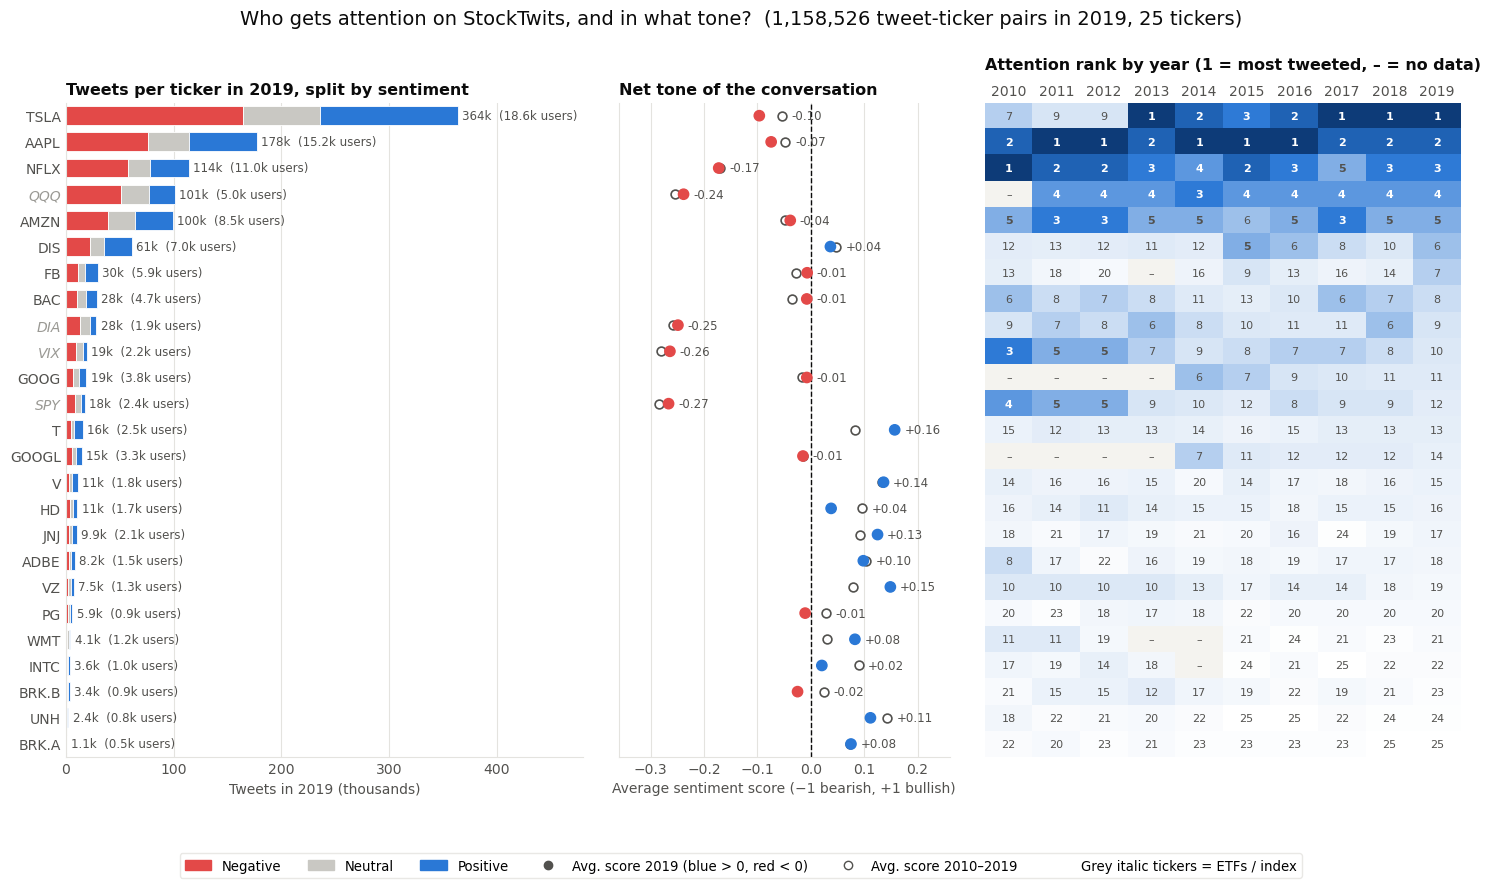

In [ ]:
# Now showcase the tweets per stock in year t, split by sentiment, ranked by total attention in graphical form
NEG, NEU, POS = '#e34948', '#c9c8c3', '#2a78d6'                                 # bearish = red, neutral = grey, bullish = blue (same as Test 2)
INK, INK_2, GRID = '#0b0b0b', '#52514e', '#e4e3df'
YEAR = 2019

counts = (annual_counts.loc[annual_counts["year"].eq(YEAR)].assign(symbol=lambda d: d["symbol"].astype(str)).sort_values("total_rank").reset_index(drop=True))
order = counts["symbol"].tolist()                                               # every panel uses the 2019 ranking, top = most tweeted
y = np.arange(len(order))
avg_all_years = (annual_counts.assign(symbol=annual_counts["symbol"].astype(str)).groupby("symbol")["average_score"].mean().reindex(order))
ranks = (annual_counts.assign(symbol=annual_counts["symbol"].astype(str)).pivot(index="symbol", columns="year", values="total_rank").reindex(order))   # NaN = no tweets that year (data gap)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 8.5), sharey=True, gridspec_kw={"width_ratios": [1.25, 0.8, 1.15], "wspace": 0.08})

# Panel A: volume in 2019, split by sentiment
left = np.zeros(len(counts))
for col, color in [("negative", NEG), ("neutral", NEU), ("positive", POS)]:
    ax1.barh(y, counts[col] / 1e3, left=left, color=color, height=0.72, edgecolor="white", linewidth=0.6)
    left += counts[col] / 1e3
for yi, (tot, users) in enumerate(zip(counts["total_tweets"], counts["unique_users"])):
    ax1.text(tot / 1e3 + 4, yi, f"{tot / 1e3:,.0f}k  ({users / 1e3:,.1f}k users)" if tot >= 1e4
             else f"{tot / 1e3:,.1f}k  ({users / 1e3:,.1f}k users)", va="center", fontsize=8.5, color=INK_2)
ax1.set_xlim(0, counts["total_tweets"].max() / 1e3 * 1.32)
ax1.set_xlabel(f"Tweets in {YEAR} (thousands)", color=INK_2)
ax1.set_title(f"Tweets per ticker in {YEAR}, split by sentiment", loc="left", fontsize=11.5, fontweight="bold", color=INK)

# Panel B: net tone = average FinTwitBERT score (-1 bearish ... +1 bullish)
score = counts["average_score"]
ax2.scatter(avg_all_years, y, s=40, facecolor="white", edgecolor=INK_2, linewidth=1.2, zorder=2)
ax2.scatter(score, y, s=55, color=np.where(score > 0, POS, NEG), zorder=3)
for yi, (s, a) in enumerate(zip(score, avg_all_years)):
    ax2.text(max(s, a) + 0.018, yi, f"{s:+.2f}", va="center", fontsize=8.5, color=INK_2)
ax2.axvline(0, color=INK, linestyle="--", linewidth=1)
ax2.set_xlim(-0.36, 0.26)
ax2.set_xlabel("Average sentiment score (−1 bearish, +1 bullish)", color=INK_2)
ax2.set_title("Net tone of the conversation", loc="left", fontsize=11.5, fontweight="bold", color=INK)

# Panel C: rank by total tweets in every year (1 = most tweeted)
cmap = LinearSegmentedColormap.from_list("rank", ["#0d3b78", POS, "#d6e4f5", "white"])   # dark = top of the ranking
cmap.set_bad("#f4f3ef")
ax3.imshow(ranks.to_numpy(dtype=float), aspect="auto", cmap=cmap, norm=LogNorm(vmin=1, vmax=25),
           extent=(-0.5, ranks.shape[1] - 0.5, len(order) - 0.5, -0.5))
for (yi, xi), r in np.ndenumerate(ranks.to_numpy(dtype=float)):
    ax3.text(xi, yi, "–" if np.isnan(r) else f"{r:.0f}", ha="center", va="center", fontsize=8,
             color="white" if r <= 4 else INK_2, fontweight="bold" if r <= 5 else None)
ax3.set_xticks(range(ranks.shape[1]), ranks.columns)
ax3.xaxis.tick_top()
ax3.set_title("Attention rank by year (1 = most tweeted, – = no data)", loc="left", fontsize=11.5,
              fontweight="bold", color=INK, pad=24)

ax1.set_yticks(y, order)
ax1.set_ylim(len(order) - 0.5, -0.5)
for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(GRID)
    ax.grid(axis="x", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
for ax in (ax1, ax2, ax3):
    ax.tick_params(colors=INK_2, length=0)
ax3.spines[:].set_visible(False)
for lbl in ax1.get_yticklabels():                                               # ETFs / index in grey: not stocks, dropped from return tests
    if lbl.get_text() in NON_COMMON_EQUITY:
        lbl.set_color("#9a9994"); lbl.set_fontstyle("italic")

handles = [Patch(color=NEG, label="Negative"), Patch(color=NEU, label="Neutral"), Patch(color=POS, label="Positive"),
           Line2D([], [], marker="o", linestyle="", color=INK_2, label=f"Avg. score {YEAR} (blue > 0, red < 0)"),
           Line2D([], [], marker="o", linestyle="", markerfacecolor="white", markeredgecolor=INK_2,
                  label="Avg. score 2010–2019"),
           Patch(facecolor="white", edgecolor="white", label="Grey italic tickers = ETFs / index")]
fig.legend(handles=handles, loc="lower center", ncol=6, frameon=True, edgecolor=GRID,
           bbox_to_anchor=(0.5, -0.04), fontsize=9.5)
fig.suptitle(f"Who gets attention on StockTwits, and in what tone?  "
             f"({counts['total_tweets'].sum():,} tweet-ticker pairs in {YEAR}, {len(order)} tickers)",
             fontsize=14, color=INK, y=0.99)
plt.show()

**Left:** how many tweets each ticker received in 2019, and how many were negative, neutral or positive.
**Middle:** the net tone, i.e. the average FinTwitBERT score (filled dot = 2019, hollow dot = 2010–2019 average).
**Right:** the ticker's attention rank in every year, so we can see whether 2019 is typical.

**Takeaways:**
- **Attention is extremely concentrated.** TSLA alone accounts for 31% of all 2019 tweet-ticker pairs, and the top five (TSLA, AAPL, NFLX, QQQ, AMZN) for 74%. The bottom ten tickers each get fewer than 11k tweets.
- **The top of the ranking barely moves.** Since 2013 the same five names have filled ranks 1–5 almost every year, so volume mostly reflects which stocks are *always* popular, not news. This is why we later build an *abnormal* attention measure (Step 4.5).
- **Tone differs a lot by type of security.** The index products (QQQ, DIA, VIX, SPY) are the most bearish (−0.24 to −0.27), probably because they are used to talk about market crashes and hedging. Defensive, dividend-paying names (T, VZ, V, JNJ) are the most bullish (+0.13 to +0.16). Tone is stable over time: the 2019 dot is usually close to the 2010–2019 average.
- **Gaps (–)** come from data collection (e.g. GOOG only exists as a separate ticker from 2014, and FB has no tweets in 2013), not from zero interest.

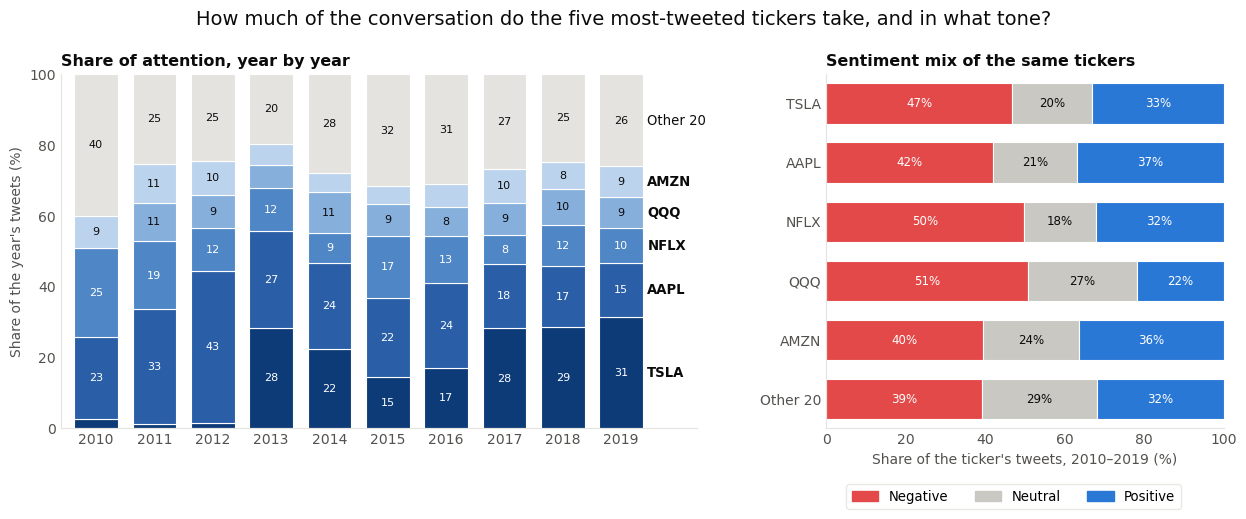

In [ ]:
# How much of the conversation do the five most-tweeted tickers take, year by year?
INK, INK_2, GRID = '#0b0b0b', '#52514e', '#e4e3df'
TOP_COLORS = ['#0d3b78', '#2a5fa8', '#4f86c6', '#86afdc', '#bcd3ee']            # one blue shade per top-5 ticker, dark = most tweeted

ac = annual_counts.assign(symbol=annual_counts["symbol"].astype(str))
top = ac.loc[ac["year"].eq(2019)].nsmallest(5, "total_rank")["symbol"].tolist()   # TSLA, AAPL, NFLX, QQQ, AMZN
ac["group"] = ac["symbol"].where(ac["symbol"].isin(top), f"Other {ac['symbol'].nunique() - 5}")
groups = top + [ac["group"].loc[~ac["symbol"].isin(top)].iloc[0]]

share = (ac.pivot_table(index="year", columns="group", values="total_tweets", aggfunc="sum")[groups].fillna(0)
         .pipe(lambda d: d.div(d.sum(axis=1), axis=0)) * 100)                   # % of all tweet-ticker pairs in each year

fig, ax1 = plt.subplots(figsize=(11, 4.6))

# Each bar = 100% of the year's tweets, split by ticker
bottom = np.zeros(len(share))
for g, color in zip(groups, TOP_COLORS + ['#e4e3df']):
    ax1.bar(share.index, share[g], bottom=bottom, color=color, width=0.75, edgecolor="white", linewidth=0.8)
    for x, b, v in zip(share.index, bottom, share[g]):
        if v >= 7:
            ax1.text(x, b + v / 2, f"{v:.0f}", ha="center", va="center", fontsize=8,
                     color="white" if color in TOP_COLORS[:3] else INK)
    ax1.text(share.index[-1] + 0.45, bottom[-1] + share[g].iloc[-1] / 2, g, va="center", fontsize=9.5,
             color=INK, fontweight="bold" if g in top else None)                 # direct labels instead of a legend
    bottom += share[g].to_numpy()
ax1.set_xticks(share.index)
ax1.set_xlim(share.index[0] - 0.6, share.index[-1] + 1.3)
ax1.set_ylim(0, 100)
ax1.set_ylabel("Share of the year's tweets (%)", color=INK_2)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color(GRID)
ax1.tick_params(colors=INK_2, length=0)
fig.suptitle("How much of the conversation do the five most-tweeted tickers take?", fontsize=14, color=INK, y=1.02)
plt.show()

**Left:** each bar is 100% of that year's tweets; the blocks show how much went to each of the five most-tweeted tickers of 2019, with the remaining 20 tickers in grey. **Right:** for the same tickers, the share of their tweets that FinTwitBERT labels negative, neutral or positive (2010–2019 pooled).

- **Five tickers take about three quarters of the conversation every year** (60–80%), so attention is concentrated throughout, not just in 2019.
- **The leader changes over time:** AAPL dominated until 2012 (43% of tweets in 2012), TSLA took over from 2013 and reached 31% by 2019.
- **The most-tweeted names are also the most bearish:** half of NFLX and QQQ tweets are negative, against 39% for the other 20 tickers. QQQ also has the fewest positive tweets (22%), consistent with index products being used to discuss downturns and hedging.

### ***Step 4.4:*** *Why raw volume is not enough*

Two concentration facts materially affect factor design:

- The panel contains **5,564,914 unique tweets** and **6,410,078 tweet-ticker pairs**. About **12.0% of tweets mention more than one ticker**, creating roughly **23.6% of all pairs**.
- The top **1% of users generate 46.7% of tweets**, while the five most-mentioned tickers account for about **73.9% of pairs**. TSLA and AAPL alone represent approximately 28.1% and 19.1%.

Raw counts therefore mix broad attention with repeated activity by a small number of accounts, multi-ticker market discussions, platform growth, and stock-specific attention. A more robust specification should preserve raw volume as a **benchmark** while separately measuring **breadth** and **disagreement**.

#### **Three candidate factors**
We selected three candidate factors:

**1. Raw relative attention (RA).** For ticker $i$ in month $t$,

$$RA_{i,t}=\frac{N_{i,t}}{\sum_j N_{j,t}}.$$

The within-month share removes the growth in platform activity. It is transparent and intuitive but remains too sensitive to prolific users and multi-ticker posts.

**2. Broad abnormal attention (BAA).** Each multi-ticker tweet receives weight $1/k$, and each user's total contribution to a ticker-month is capped at one unit. Let $B_{i,t}$ be this breadth measure and $s^B_{i,t}$ its cross-sectional share. Then

$$BAA_{i,t}=\log\!\left(\frac{s^B_{i,t}}{\operatorname{median}(s^B_{i,t-1},\ldots,s^B_{i,t-12})}\right).$$

Only earlier valid months enter the rolling median. Five prior valid months are sufficient at the beginning of the sample; the trailing window then expands to 12. After a collection gap, the estimator uses the last 12 **valid** months and therefore neither resets nor treats missing platform data as zero. Because we work with months, the 5 initial months for which the window is too small do not represent a problem. For a year design a shrinking-expansion design would have been preferable. It is also important to note that 2017 is a gap year in the data and, while not returning null, it is advisable to consider the prediction of 2018 with attention as they are based on the 2016 median.

This adapts the abnormal-search-volume design of [Da, Engelberg, and Gao (2011)](https://doi.org/10.1111/j.1540-6261.2011.01679.x) to social-media breadth. It is the strongest candidate because it measures *unexpected, widely distributed* attention compared to baseline instead of merely raw activity.

**3. Sentiment disagreement.**
Sentiment disagreement is measured as the cross-sectional standard deviation of users’ average sentiment scores for each stock-month.
Each user contributes one observation, preventing hyperactive accounts from mechanically increasing measured disagreement. Stock-months with fewer than ten users are excluded because dispersion estimates based on very small audiences are unreliable.

### ***Step 4.5:*** *Monthly construction, rankings, and portfolio assignments*

In this step, we aggregate the data once to the user-ticker-month level to reduce the dataset to a small balanced panel. We add saving checkpoints for future data preservation and safety.

In [ ]:
def robust_zscore(values):
    # Cross-sectional median/MAD score with a standard-deviation fallback.
    valid_values = values.dropna()
    result = pd.Series(np.nan, index=values.index, dtype="float64")
    if valid_values.empty:
        return result
    center = valid_values.median()
    scale = 1.4826 * (valid_values - center).abs().median()
    if not np.isfinite(scale) or scale <= 1e-12:
        center = valid_values.mean()
        scale = valid_values.std(ddof=0)
    result.loc[valid_values.index] = (
        0.0 if (not np.isfinite(scale) or scale <= 1e-12)
        else (valid_values - center) / scale
    )
    return result

After, prepare the variables for the three-factor model.

In [ ]:
#1. CREATE A COMPLETE MONTH–STOCK GRID
# Every month x every ticker, so that a stock with zero tweets in a month is recorded as zero attention instead of disappearing.
symbols = sorted(panel["symbol"].astype(str).unique())
months = pd.period_range(panel["month"].min(), panel["month"].max(), freq="M")
full_index = pd.MultiIndex.from_product([months, symbols], names=["month", "symbol"])

# 2. IDENTIFY MONTHS WITH POOR DATA COVERAGE
# The panel has one row per tweet-ticker pair, so count each message once to measure total platform activity.
month_quality = (panel.drop_duplicates("message_id").groupby("month", observed=True).size().to_frame("unique_tweets")
                 .reindex(months, fill_value=0))                             # missing calendar months get zero activity
month_quality.index.name = "month"

# Normal activity = median of the previous six months (shift(1): the current month never judges itself).
month_quality["previous_6m_median"] = (month_quality["unique_tweets"].shift(1).rolling(window=6, min_periods=3).median())

# 1 = same activity as the recent median, 0.20 = only 20% of normal activity was collected.
month_quality["coverage_ratio"] = (month_quality["unique_tweets"] / month_quality["previous_6m_median"])

# Collection gap = activity below GAP_THRESHOLD (35%) of the recent median.
month_quality["is_collection_gap"] = (month_quality["coverage_ratio"].lt(GAP_THRESHOLD))

# The first and last months are only partly covered by the data, so they are never usable either.
is_partial_boundary_month = month_quality.index.isin([months.min(), months.max()])
month_quality["usable_for_factor"] = ~(month_quality["is_collection_gap"] | is_partial_boundary_month)


# 3. CALCULATE BASIC STOCK-MONTH STATISTICS
stock_month = (panel.groupby(["month", "symbol"], observed=True, sort=False).agg(
        raw_attention=("message_id", "size"),                               # Candidate 1: number of tweets mentioning the stock.
        unique_users=("user", "nunique"),                                   # Candidate 3: minimum of 10 users for disagreement.
        crosslisted_share=("n_stocks", lambda values: values.gt(1).mean()), # Share of tweets mentioning more than one ticker (Step 4.6 movers chart).
        )
    .reindex(full_index)  # re-add stock-month combinations with no tweets
)

# Count negative, positive and neutral tweets (used for net tone).
label_counts = (panel.groupby(["month", "symbol", "label"], observed=True, sort=False).size()
    .unstack("label", fill_value=0)
    .reindex(full_index, fill_value=0)
    .reindex(columns=["negative", "positive", "neutral"], fill_value=0)
)
stock_month = stock_month.join(label_counts)

# Missing activity values mean zero tweets, not unknown values.
count_columns = ["raw_attention", "unique_users", "negative", "positive", "neutral"]
stock_month[count_columns] = (stock_month[count_columns].fillna(0))

# 4. CREATE ONE OBSERVATION PER USER, STOCK, AND MONTH
# A prolific user may post hundreds of messages about the same stock; summarising each user in one row stops them from dominating.
user_stock_month = (panel.groupby(["month", "symbol", "user"], observed=True, sort=False)
    .agg(user_tweets=("message_id", "size"),                    # tweets by this user about this stock (for author HHI)
         user_fractional_attention=("fractional_weight", "sum"), # multi-ticker tweets count 1/k
         user_mean_score=("score", "mean"))                      # user's average sentiment (for disagreement)
    .reset_index()
)

# 5. BROAD ATTENTION: each user's contribution is capped at one unit, so posting 100 times does not create 100 units.
user_stock_month["capped_attention"] = (user_stock_month["user_fractional_attention"].clip(upper=1.0))

# 6. AUTHOR CONCENTRATION (Herfindahl index): squared share of each user in the stock's monthly tweets.
user_stock_month["tweet_share_sq"] = (user_stock_month["user_tweets"] / user_stock_month.groupby(["month", "symbol"], observed=True)
                                      ["user_tweets"].transform("sum")).pow(2)

# 7. AGGREGATE USER-LEVEL MEASURES
user_stats = (user_stock_month.groupby(["month", "symbol"], observed=True, sort=False)
    .agg(broad_attention=("capped_attention", "sum"),        # Candidate 2 input
         author_hhi=("tweet_share_sq", "sum"),               # high = a few users write most tweets
         sentiment_disagreement=("user_mean_score", "std"))  # Candidate 3: dispersion of users' average sentiment
)

# 8. ADD USER STATISTICS TO THE STOCK-MONTH TABLE
stock_month = (stock_month.join(user_stats).reset_index())
stock_month["broad_attention"] = (stock_month["broad_attention"].fillna(0))  # no tweets = zero broad attention

# 9. ADD THE MONTHLY DATA-QUALITY FLAG
stock_month = stock_month.merge(month_quality.reset_index()[["month", "usable_for_factor"]], on="month", how="left", validate="many_to_one")

In [ ]:
# Candidate 1: raw within-month share and rank.
stock_month["raw_attention_share"] = (stock_month["raw_attention"] / stock_month.groupby("month")["raw_attention"].transform("sum"))
stock_month["raw_attention_percentile"] = (stock_month.groupby("month")["raw_attention"].rank(method="average", pct=True))

In [ ]:
# Candidate 2: Broad Abnormal Attention
number_of_symbols = len(symbols)  # Number of tickers in the analysis.

# Share of the month's total broad attention received by each stock.
# +0.5 avoids log(0) for stocks with zero attention; the denominator gets +0.5 x number of stocks so shares still add up to one.
broad_total = (stock_month.groupby("month")["broad_attention"].transform("sum"))
stock_month["broad_attention_share"] = (stock_month["broad_attention"] + 0.5) / (broad_total + 0.5 * number_of_symbols)

# Keep only months with reliable data: a month with missing StockTwits data is not genuinely low attention.
valid = stock_month.loc[stock_month["usable_for_factor"]].sort_values(["symbol", "month"]).copy()

# Normal attention = median share over the previous 12 valid months (at least 5), excluding the current month.
valid["expected_broad_share"] = (valid.groupby("symbol", observed=True)["broad_attention_share"].transform(
        lambda values: values.shift(1).rolling(window=BAA_WINDOW, min_periods=BAA_MIN_HISTORY).median()))

# BAA > 0: attention above the stock's own norm; BAA = 0: at the norm; BAA < 0: below the norm.
valid["broad_abnormal_attention"] = np.log(valid["broad_attention_share"] / valid["expected_broad_share"])

# Monthly percentile rank of BAA across stocks.
valid["baa_percentile"] = (valid.groupby("month")["broad_abnormal_attention"].rank(method="average", pct=True))

# Merge back: excluded months stay in stock_month (for auditing) but have missing BAA, so they never enter rankings or portfolios.
stock_month = stock_month.merge(valid[["month", "symbol", "broad_abnormal_attention", "baa_percentile"]],
                                on=["month", "symbol"], how="left", validate="one_to_one")

In [ ]:
#Candidate 3: user-level sentiment disagreement
MIN_USERS_FOR_DISAGREEMENT = 10 # dispersion across fewer than 10 users is too noisy

stock_month["sentiment_disagreement"] = (stock_month["sentiment_disagreement"].where(stock_month["unique_users"] >= MIN_USERS_FOR_DISAGREEMENT))
stock_month["disagreement_percentile"] = (stock_month.groupby("month")["sentiment_disagreement"].rank(method="average", pct=True))

# Remove factor values in unreliable months.
stock_month.loc[~stock_month["usable_for_factor"], ["raw_attention_percentile", "baa_percentile", "disagreement_percentile"]] = np.nan

# Net tone: +1 = all positive, -1 = all negative.
classified = stock_month[["negative", "positive", "neutral"]].sum(axis=1).replace(0, np.nan)
stock_month["net_tone"] = (stock_month["positive"] - stock_month["negative"]) / classified

In [ ]:
#time and asset-type variables
stock_month["calendar_year"] = (stock_month["month"].dt.year.astype("int16"))

# ETFs and the VIX stay in the descriptive analysis but are excluded from stock-return portfolios.
stock_month["eligible_for_portfolio"] = ~stock_month["symbol"].isin(NON_COMMON_EQUITY)

In [ ]:
# Monthly analysis sample
analysis_month = stock_month.loc[stock_month["month"].between(pd.Period("2010-01", "M"), pd.Period("2020-06", "M"))].copy()

In [ ]:
# Convert the percentiles of each factor in rankings
for factor in ["raw_attention_percentile", "baa_percentile", "disagreement_percentile"]:
    rank_column = factor.replace("_percentile", "_rank")

    analysis_month[rank_column] = (analysis_month.groupby("month")[factor].rank(method="min", ascending=False))

In [ ]:
#Create annual factor summaries
# Keep reliable months from complete calendar years.
annual_factor_source = analysis_month.loc[analysis_month["usable_for_factor"] & analysis_month["calendar_year"].between(2010, 2019)]

annual_factors = (annual_factor_source.groupby(["calendar_year", "symbol"], observed=True).agg(
        raw_relative_attention=("raw_attention_percentile", "mean"),    # average monthly percentile of Candidate 1
        broad_abnormal_attention=("baa_percentile", "mean"),            # average monthly percentile of Candidate 2
        sentiment_disagreement=("disagreement_percentile", "mean"),     # average monthly percentile of Candidate 3
        mean_net_tone=("net_tone", "mean"),                             # supporting diagnostics for the Step 4.6 charts
        mean_author_hhi=("author_hhi", "mean"),
        mean_crosslisted_share=("crosslisted_share", "mean")).reset_index().rename(columns={"calendar_year": "year"}))

# Rank of each stock within the year (1 = highest) for every factor.
annual_factor_names = ["raw_relative_attention", "broad_abnormal_attention", "sentiment_disagreement"]
for factor in annual_factor_names:
    annual_factors[f"{factor}_rank"] = (annual_factors.groupby("year")[factor].rank(method="min", ascending=False))

annual_summary = annual_counts.merge(annual_factors, on=["year", "symbol"], how="left", validate="one_to_one")  # add annual tweet counts

### ***Step 4.6:*** *Empirical Ranking Diagnostics*

Before choosing a factor for the return tests, we assess the following: month reliability (Fig. 1); do the three candidates for the factor model measure different things and stability of their rankings (Fig. 2); how do 2019 rankings differ (Figs. 3–5); does the two design choices behind BAA (count users vs tweets) plus comparing each stock with its own history matters (Figs. 6–7).

Three distinctions guide the reading:
1. **Level vs. shock.** Raw attention measures how much a stock is *usually* discussed; BAA measures how much *more than usual* it is discussed.
2. **Breadth vs. repetition.** Raw counts can be inflated by prolific users and multi-ticker tweets; BAA caps each user at one unit per stock-month and splits multi-ticker tweets.
3. **Attention vs. disagreement.** Disagreement measures how dispersed users' opinions are, not how much they talk or whether they are negative.

In [ ]:
# Data and graph preparation for future steps
NEG, NEU, POS = '#e34948', '#c9c8c3', '#2a78d6'                                 # same palette as Steps 4.3 and Test 2
INK, INK_2, GRID, ETF_GREY = '#0b0b0b', '#52514e', '#e4e3df', '#9a9994'
FACTORS = {"raw_attention_percentile": "Raw attention",                         # monthly percentile columns built in Step 4.5
           "baa_percentile": "Broad abnormal attention (BAA)",
           "disagreement_percentile": "Sentiment disagreement"}
FACTOR_COLORS = {"raw_attention_percentile": "#7b5ea7", "baa_percentile": POS, "disagreement_percentile": "#e8a33d"}
ranking_year = 2019

def style(ax, grid="x"):
    """Light axes in the notebook style: no top/right frame, soft grid behind the data."""
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(GRID)
    ax.tick_params(colors=INK_2, length=0)
    if grid:
        ax.grid(axis=grid, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

def title(ax, text, **kw):
    ax.set_title(text, loc="left", fontsize=11.5, fontweight="bold", color=INK, **kw)

def grey_etf_labels(ax):
    """ETFs and the VIX index in grey italics: they stay in the descriptive rankings but never enter stock portfolios."""
    for lbl in ax.get_yticklabels():
        if lbl.get_text() in NON_COMMON_EQUITY:
            lbl.set_color(ETF_GREY); lbl.set_fontstyle("italic")

def ci95(values):
    values = pd.Series(values).dropna()
    return 1.96 * values.std() / np.sqrt(len(values))

# One month x ticker grid per factor, reliable months only
valid_months = analysis_month.loc[analysis_month["usable_for_factor"]].copy()
wide = {f: valid_months.pivot(index="month", columns="symbol", values=f).sort_index() for f in FACTORS}

def consecutive_months(frame):
    """(previous, current) rows for every pair of consecutive calendar months, so Aug-2017 is never compared with Jan-2018."""
    for month in frame.index:
        if month - 1 in frame.index:
            yield frame.loc[month - 1], frame.loc[month]

# 1) Do the factors measure the same thing? Cross-sectional Spearman correlation in every month, then averaged
factor_pairs = [("raw_attention_percentile", "baa_percentile"), ("raw_attention_percentile", "disagreement_percentile"),
                ("baa_percentile", "disagreement_percentile")]
pair_corr = pd.DataFrame({(a, b): valid_months.groupby("month")[[a, b]]
                          .apply(lambda d: d[a].corr(d[b], method="spearman") if d.dropna().shape[0] >= 5 else np.nan)
                          for a, b in factor_pairs})

# 2) How sticky is each ranking? Spearman correlation between this month's ranking and last month's
persistence = {f: pd.Series([prev.corr(cur, method="spearman") for prev, cur in consecutive_months(wide[f])
                             if pd.concat([prev, cur], axis=1).dropna().shape[0] >= 5]) for f in FACTORS}

# 3) Same idea in plain words: what share of this month's top 5 is still in the top 5 next month?
def top5_stay_rate(frame):
    rates = []
    for prev, cur in consecutive_months(frame):
        both = prev.dropna().index.intersection(cur.dropna().index)
        if len(both) >= 10:
            rates.append(len(set(prev[both].nlargest(5).index) & set(cur[both].nlargest(5).index)) / 5)
    return np.mean(rates)
top5_stay = pd.Series({f: top5_stay_rate(wide[f]) for f in FACTORS})
n_tickers = int(valid_months.groupby("month")["symbol"].nunique().median())

# 2019 annual view of every ticker (used by the ranking charts)
year_view = annual_summary.loc[annual_summary["year"].eq(ranking_year)].copy()
year_view["symbol"] = year_view["symbol"].astype(str)
year_view["rank_change"] = year_view["raw_relative_attention_rank"] - year_view["broad_abnormal_attention_rank"]  # + = better under BAA

#### *4.6.1 Which months are reliable?*

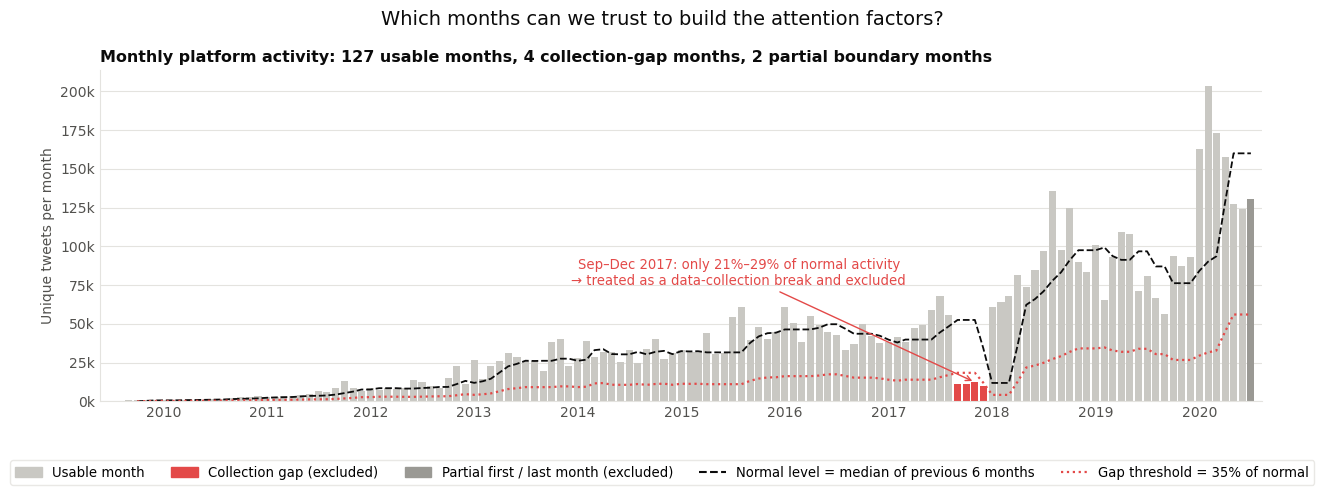

In [ ]:
# Figure 1: which months are reliable enough to build the factors?
mq = month_quality.copy()
x = mq.index.to_timestamp()
is_boundary = mq.index.isin([mq.index.min(), mq.index.max()])
bar_colors = np.where(mq["is_collection_gap"], NEG, np.where(is_boundary, ETF_GREY, NEU))

fig, ax = plt.subplots(figsize=(15, 4.3))
ax.bar(x, mq["unique_tweets"] / 1e3, width=25, color=bar_colors)
ax.plot(x, mq["previous_6m_median"] / 1e3, color=INK, linestyle="--", linewidth=1.3)
ax.plot(x, GAP_THRESHOLD * mq["previous_6m_median"] / 1e3, color=NEG, linestyle=":", linewidth=1.6)

gaps = mq.loc[mq["is_collection_gap"]]
ax.annotate(f"{gaps.index.min().strftime('%b')}–{gaps.index.max().strftime('%b %Y')}: only "
            f"{gaps['coverage_ratio'].min():.0%}–{gaps['coverage_ratio'].max():.0%} of normal activity\n"
            f"→ treated as a data-collection break and excluded",
            xy=(gaps.index[len(gaps) // 2].to_timestamp(), gaps["unique_tweets"].max() / 1e3),
            xytext=(-170, 70), textcoords="offset points", fontsize=9.5, color=NEG, ha="center",
            arrowprops=dict(arrowstyle="->", color=NEG))

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}k"))
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlim(x.min() - pd.Timedelta(days=40), x.max() + pd.Timedelta(days=40))
ax.set_ylabel("Unique tweets per month", color=INK_2)
style(ax, grid="y")
title(ax, f"Monthly platform activity: {mq['usable_for_factor'].sum()} usable months, "
          f"{len(gaps)} collection-gap months, 2 partial boundary months")

fig.legend(handles=[Patch(color=NEU, label="Usable month"), Patch(color=NEG, label="Collection gap (excluded)"),
                    Patch(color=ETF_GREY, label="Partial first / last month (excluded)"),
                    Line2D([], [], color=INK, linestyle="--", label="Normal level = median of previous 6 months"),
                    Line2D([], [], color=NEG, linestyle=":", linewidth=1.6, label=f"Gap threshold = {GAP_THRESHOLD:.0%} of normal")],
           loc="lower center", ncol=5, frameon=True, edgecolor=GRID, bbox_to_anchor=(0.5, -0.1), fontsize=9.5)
fig.suptitle("Which months can we trust to build the attention factors?", fontsize=14, color=INK, y=1.02)
plt.show()

Each bar is one month of unique tweets. The dashed line is the "normal" level (median of the previous six months); the dotted red line is 35% of that. A month that falls below the red line is a collection gap.

Only **Sep–Dec 2017** fall below it, with just 21–29% of normal activity. Because the drop hits every ticker at the same time, it is a data-collection break, not an economic event: these months are kept for auditing but excluded from baselines, rankings, annual scores and portfolios. The first and last months (Jul 2009, Jul 2020) are partial by construction and excluded too. 2017 annual results therefore rest on 8 months only.

#### *4.6.2 Do the three factors measure different things?*

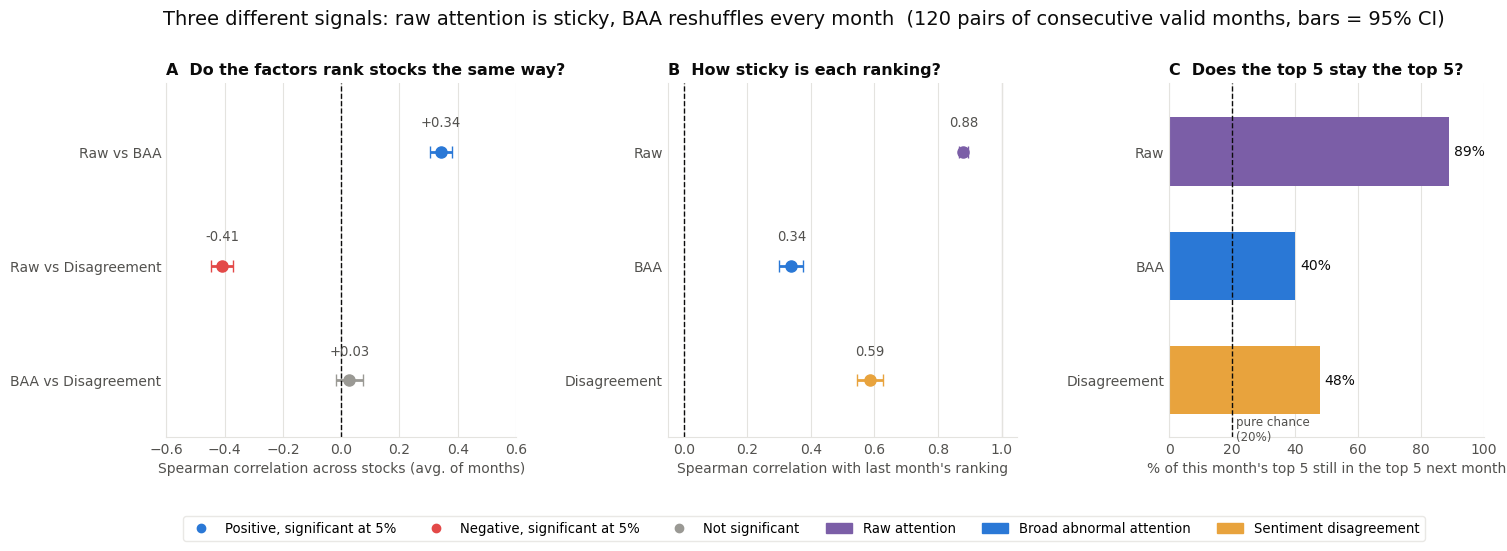

In [ ]:
# Figure 2: do the three candidate factors measure different things, and how quickly do their rankings change?
SHORT = {"raw_attention_percentile": "Raw", "baa_percentile": "BAA", "disagreement_percentile": "Disagreement"}
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 4.6), gridspec_kw={"width_ratios": [1, 1, 0.9], "wspace": 0.45})

# Panel A: average monthly correlation between each pair of factors, with 95% CI (coloured = different from 0)
for yi, (a, b) in enumerate(factor_pairs):
    m, ci = pair_corr[(a, b)].mean(), ci95(pair_corr[(a, b)])
    color = (POS if m > 0 else NEG) if abs(m) > ci else ETF_GREY
    ax1.errorbar(m, yi, xerr=ci, fmt="o", color=color, markersize=8, capsize=4, linewidth=2)
    ax1.text(m, yi - 0.22, f"{m:+.2f}", ha="center", fontsize=9.5, color=INK_2)
ax1.axvline(0, color=INK, linestyle="--", linewidth=1)
ax1.set_yticks(range(len(factor_pairs)), [f"{SHORT[a]} vs {SHORT[b]}" for a, b in factor_pairs])
ax1.set_ylim(len(factor_pairs) - 0.5, -0.6)
ax1.set_xlim(-0.6, 0.6)
ax1.set_xlabel("Spearman correlation across stocks (avg. of months)", color=INK_2)
title(ax1, "A  Do the factors rank stocks the same way?")

# Panel B: average correlation between this month's ranking and last month's, with 95% CI
for yi, f in enumerate(FACTORS):
    m, ci = persistence[f].mean(), ci95(persistence[f])
    ax2.errorbar(m, yi, xerr=ci, fmt="o", color=FACTOR_COLORS[f], markersize=8, capsize=4, linewidth=2)
    ax2.text(m, yi - 0.22, f"{m:.2f}", ha="center", fontsize=9.5, color=INK_2)
ax2.axvline(0, color=INK, linestyle="--", linewidth=1)
ax2.axvline(1, color=GRID, linewidth=1)
ax2.set_yticks(range(len(FACTORS)), [SHORT[f] for f in FACTORS])
ax2.set_ylim(len(FACTORS) - 0.5, -0.6)
ax2.set_xlim(-0.05, 1.05)
ax2.set_xlabel("Spearman correlation with last month's ranking", color=INK_2)
title(ax2, "B  How sticky is each ranking?")

# Panel C: the same idea in plain words
ax3.barh(range(len(FACTORS)), 100 * top5_stay, color=[FACTOR_COLORS[f] for f in FACTORS], height=0.6)
for yi, v in enumerate(top5_stay):
    ax3.text(100 * v + 1.5, yi, f"{v:.0%}", va="center", fontsize=10, color=INK)
ax3.axvline(100 * 5 / n_tickers, color=INK, linestyle="--", linewidth=1)
ax3.text(100 * 5 / n_tickers + 1, len(FACTORS) - 0.45, f"pure chance\n({5 / n_tickers:.0%})", fontsize=8.5, color=INK_2, va="bottom")
ax3.set_yticks(range(len(FACTORS)), [SHORT[f] for f in FACTORS])
ax3.set_ylim(len(FACTORS) - 0.5, -0.6)
ax3.set_xlim(0, 100)
ax3.set_xlabel("% of this month's top 5 still in the top 5 next month", color=INK_2)
title(ax3, "C  Does the top 5 stay the top 5?")

for ax in (ax1, ax2, ax3):
    style(ax)
fig.legend(handles=[Line2D([], [], marker="o", linestyle="", color=POS, label="Positive, significant at 5%"),
                    Line2D([], [], marker="o", linestyle="", color=NEG, label="Negative, significant at 5%"),
                    Line2D([], [], marker="o", linestyle="", color=ETF_GREY, label="Not significant"),
                    Patch(color=FACTOR_COLORS["raw_attention_percentile"], label="Raw attention"),
                    Patch(color=FACTOR_COLORS["baa_percentile"], label="Broad abnormal attention"),
                    Patch(color=FACTOR_COLORS["disagreement_percentile"], label="Sentiment disagreement")],
           loc="lower center", ncol=6, frameon=True, edgecolor=GRID, bbox_to_anchor=(0.5, -0.13), fontsize=9.5)
fig.suptitle(f"Three different signals: raw attention is sticky, BAA reshuffles every month  "
             f"({len(persistence['baa_percentile'])} pairs of consecutive valid months, bars = 95% CI)",
             fontsize=14, color=INK, y=1.04)
plt.show()

*Panel A:* each month we correlate the factor rankings across stocks and average over the 122 reliable months (coloured = significantly different from zero, grey = not). *Panel B:* how similar each month's ranking is to the previous month's (1 = identical). *Panel C:* the same idea in plain words: what share of this month's top 5 is still in the top 5 next month (pure chance would be 20%).

- **The three measures capture different things.** Raw attention and BAA are only moderately related (**+0.34**). Raw attention and disagreement are negatively related (**−0.41**): heavily discussed stocks show *less* dispersion in user sentiment. That could mean consensus, but also partly measurement, since users who post often about a stock get averaged into a less extreme score. BAA and disagreement are unrelated (**+0.03**, not significant), so unusual attention does not mean users disagree.
- **Raw attention is a stable level, BAA is a shock.** Raw rankings barely move (**0.88**; **89%** of the top 5 stay there next month). BAA reshuffles (**0.34**; only **40%** stay, double chance but far from permanent), which is what we want from a measure of *new* information. Disagreement sits in between (**0.59**, **48%**).

#### *4.6.3 The 2019 rankings*

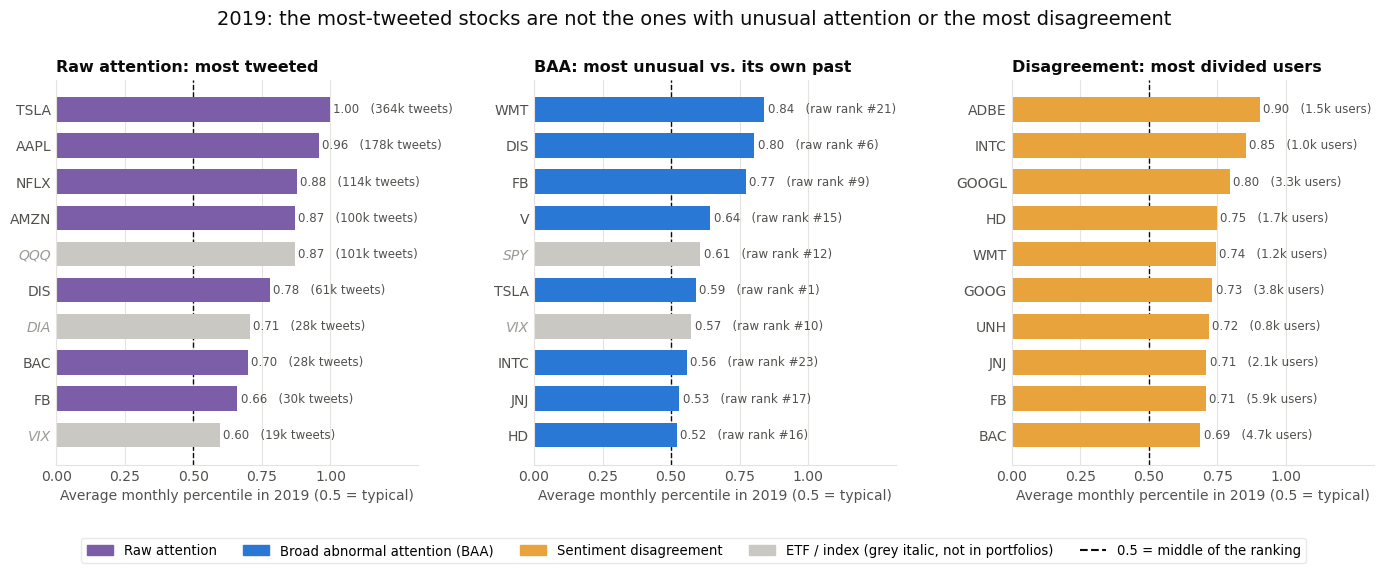

In [ ]:
# Figure 3: the 2019 top ten under each factor (replaces the three top-ten tables)
panels = [("raw_relative_attention", "raw_attention_percentile", "Raw attention: most tweeted",
           lambda r: f"{r['total_tweets'] / 1e3:,.0f}k tweets"),
          ("broad_abnormal_attention", "baa_percentile", "BAA: most unusual vs. its own past",
           lambda r: f"raw rank #{r['raw_relative_attention_rank']:.0f}"),
          ("sentiment_disagreement", "disagreement_percentile", "Disagreement: most divided users",
           lambda r: f"{r['unique_users'] / 1e3:,.1f}k users")]

fig, axes = plt.subplots(1, 3, figsize=(17, 5), gridspec_kw={"wspace": 0.32})
for ax, (col, factor, name, note) in zip(axes, panels):
    top10 = year_view.nlargest(10, col).iloc[::-1]                              # reversed so #1 is drawn at the top
    is_etf = top10["symbol"].isin(NON_COMMON_EQUITY)
    ax.barh(top10["symbol"], top10[col], color=np.where(is_etf, NEU, FACTOR_COLORS[factor]), height=0.68, zorder=2)
    for yi, (_, r) in enumerate(top10.iterrows()):
        ax.text(r[col] + 0.012, yi, f"{r[col]:.2f}   ({note(r)})", va="center", fontsize=8.5, color=INK_2)
    ax.axvline(0.5, color=INK, linestyle="--", linewidth=1, zorder=1.5)
    ax.set_xlim(0, 1.32)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
    ax.set_xlabel("Average monthly percentile in 2019 (0.5 = typical)", color=INK_2)
    title(ax, name)
    style(ax)
    grey_etf_labels(ax)

fig.legend(handles=[Patch(color=FACTOR_COLORS[f], label=FACTORS[f]) for f in FACTORS] +
                   [Patch(color=NEU, label="ETF / index (grey italic, not in portfolios)"),
                    Line2D([], [], color=INK, linestyle="--", label="0.5 = middle of the ranking")],
           loc="lower center", ncol=5, frameon=True, edgecolor=GRID, bbox_to_anchor=(0.5, -0.1), fontsize=9.5)
fig.suptitle(f"{ranking_year}: the most-tweeted stocks are not the ones with unusual attention or the most disagreement",
             fontsize=14, color=INK, y=1.02)
plt.show()

Each panel shows the ten highest tickers under one factor, measured as the average of their monthly percentiles in 2019 (1 = top every month, 0.5 = middle). Grey bars are ETFs/index (described, but never in portfolios).

- **Raw attention** is led by TSLA (0.997, i.e. first almost every month, with 364k tweets from 18.7k users), then AAPL, NFLX, AMZN and QQQ. Three of the ten are market-wide instruments (QQQ, DIA, VIX).
- **BAA** looks completely different: **WMT** is first despite being only the 21st most-tweeted ticker. A score of 0.84 means WMT's abnormal attention averaged the 84th percentile across 2019, not that it got 84% more tweets. DIS and FB are both popular *and* unusual; TSLA drops to 6th because huge attention is normal for TSLA. SPY and VIX also rank high, a sign that part of the 2019 signal is market-wide.
- **Disagreement** is led by ADBE, INTC and GOOGL, none of which is heavily tweeted. With only ~1–1.5k users, the top two are also the least precisely measured, which is why the user count is printed next to each bar.

#### *4.6.4 Who gains and who loses when we switch from raw attention to BAA?*

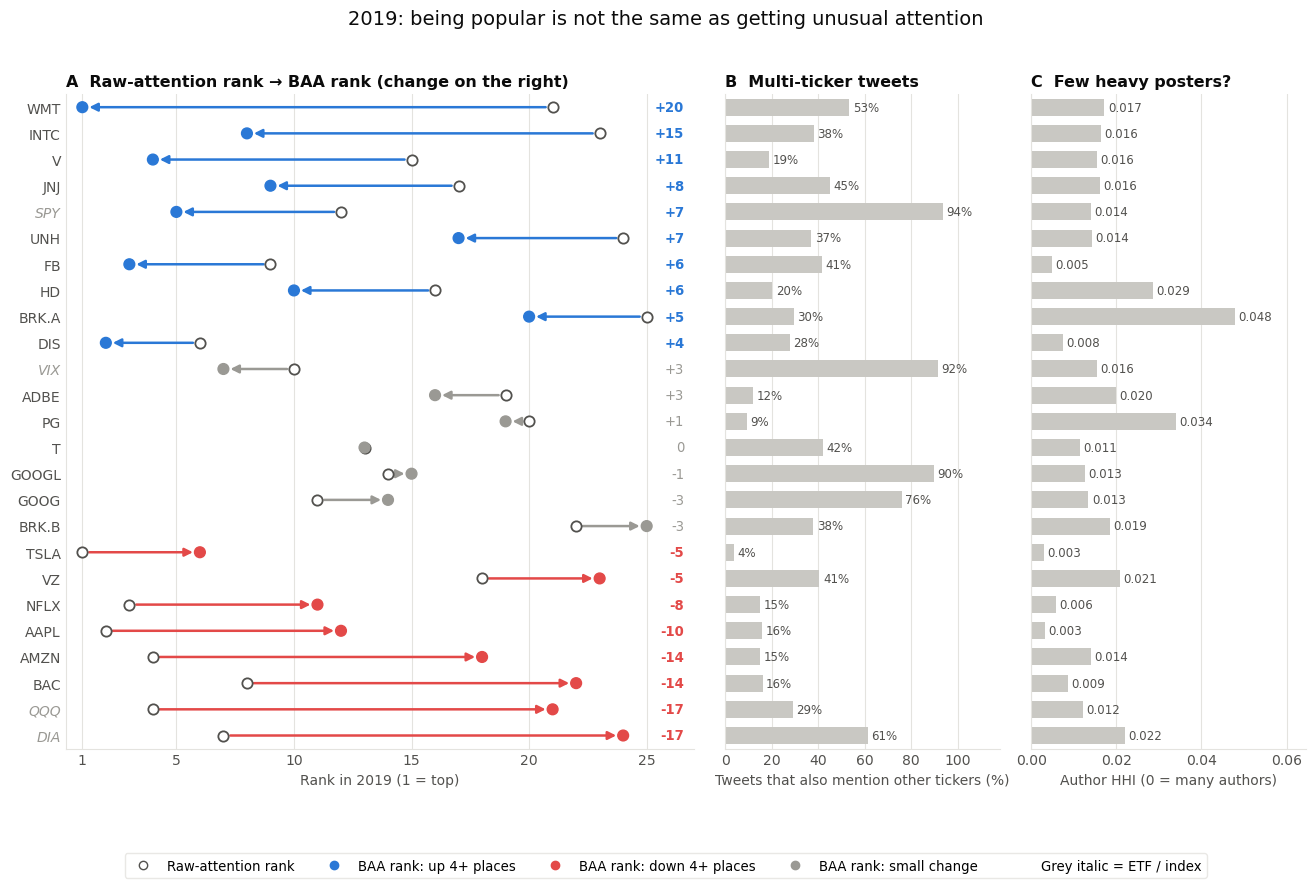

In [ ]:
# Figure 4: who gains and who loses when we switch from raw attention to BAA, and is it explained by heavy posters or multi-ticker tweets?
BIG_MOVE = 4                                                                    # a change of 4+ places counts as a big move
mv = year_view.dropna(subset=["rank_change"]).sort_values(["rank_change", "raw_relative_attention_rank"], ascending=[False, True])
y = np.arange(len(mv))
move_color = np.where(mv["rank_change"] >= BIG_MOVE, POS, np.where(mv["rank_change"] <= -BIG_MOVE, NEG, ETF_GREY))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 8.5), sharey=True,
                                    gridspec_kw={"width_ratios": [1.6, 0.7, 0.7], "wspace": 0.08})

# Panel A: raw rank (hollow) -> BAA rank (filled), rank 1 on the left
for yi, (_, r), c in zip(y, mv.iterrows(), move_color):
    ax1.annotate("", xy=(r["broad_abnormal_attention_rank"], yi), xytext=(r["raw_relative_attention_rank"], yi),
                 arrowprops=dict(arrowstyle="-|>", color=c, linewidth=1.8, shrinkA=5, shrinkB=5, mutation_scale=12))
    ax1.text(26.6, yi, f"{r['rank_change']:+.0f}" if r["rank_change"] else "0", va="center", ha="right", fontsize=9.5,
             color=c, fontweight="bold" if c != ETF_GREY else None)
ax1.scatter(mv["raw_relative_attention_rank"], y, s=55, facecolor="white", edgecolor=INK_2, linewidth=1.3, zorder=3)
ax1.scatter(mv["broad_abnormal_attention_rank"], y, s=60, color=move_color, zorder=4)
ax1.set_xlim(0.3, 27)
ax1.set_xticks([1, 5, 10, 15, 20, 25])
ax1.set_xlabel("Rank in 2019 (1 = top)", color=INK_2)
title(ax1, "A  Raw-attention rank → BAA rank (change on the right)")

# Panels B and C: the two mechanical explanations for a move
ax2.barh(y, 100 * mv["mean_crosslisted_share"], color=NEU, height=0.65)
ax3.barh(y, mv["mean_author_hhi"], color=NEU, height=0.65)
for yi, (s, h) in enumerate(zip(mv["mean_crosslisted_share"], mv["mean_author_hhi"])):
    ax2.text(100 * s + 1.5, yi, f"{s:.0%}", va="center", fontsize=8.5, color=INK_2)
    ax3.text(h + 0.0008, yi, f"{h:.3f}", va="center", fontsize=8.5, color=INK_2)
ax2.set_xlim(0, 118)
ax3.set_xlim(0, mv["mean_author_hhi"].max() * 1.35)
ax2.set_xlabel("Tweets that also mention other tickers (%)", color=INK_2)
ax3.set_xlabel("Author HHI (0 = many authors)", color=INK_2)
title(ax2, "B  Multi-ticker tweets")
title(ax3, "C  Few heavy posters?")

ax1.set_yticks(y, mv["symbol"])
ax1.set_ylim(len(mv) - 0.5, -0.5)
for ax in (ax1, ax2, ax3):
    style(ax)
grey_etf_labels(ax1)

fig.legend(handles=[Line2D([], [], marker="o", linestyle="", markerfacecolor="white", markeredgecolor=INK_2, label="Raw-attention rank"),
                    Line2D([], [], marker="o", linestyle="", color=POS, label=f"BAA rank: up {BIG_MOVE}+ places"),
                    Line2D([], [], marker="o", linestyle="", color=NEG, label=f"BAA rank: down {BIG_MOVE}+ places"),
                    Line2D([], [], marker="o", linestyle="", color=ETF_GREY, label="BAA rank: small change"),
                    Patch(facecolor="white", edgecolor="white", label="Grey italic = ETF / index")],
           loc="lower center", ncol=5, frameon=True, edgecolor=GRID, bbox_to_anchor=(0.5, -0.05), fontsize=9.5)
fig.suptitle(f"{ranking_year}: being popular is not the same as getting unusual attention", fontsize=14, color=INK, y=0.98)
plt.show()

*Panel A:* each arrow goes from a ticker's raw-attention rank (hollow dot) to its BAA rank (filled dot); rank 1 is on the left, so an arrow pointing left is an improvement. Blue = up 4+ places, red = down 4+, grey = small change. *Panel B* and *Panel C* show the two mechanical things BAA corrects for, on the same rows: the share of multi-ticker tweets and author concentration (HHI; higher = a few users write most tweets).

- **Winners** (WMT +20, INTC +15, V +11, JNJ +8) were not heavily discussed, but their 2019 attention was high *for them*.
- **Losers** (QQQ and DIA −17, AMZN and BAC −14, AAPL −10, NFLX −8) are always heavily discussed, so 2019 was business as usual.
- **Panels B and C show the moves are mostly about the stock's own history, not the mechanics.** AAPL and TSLA have the lowest author concentration (HHI 0.003) and few multi-ticker tweets (16% and 4%), yet both fall: heavy attention is simply normal for them. WMT rises by 20 places even though 53% of its tweets mention other tickers. DIA is the exception where mechanics matter: a high HHI (0.022) and 61% multi-ticker tweets mean its raw rank partly reflects repeated market commentary.

#### *4.6.5 Disagreement is not negativity*

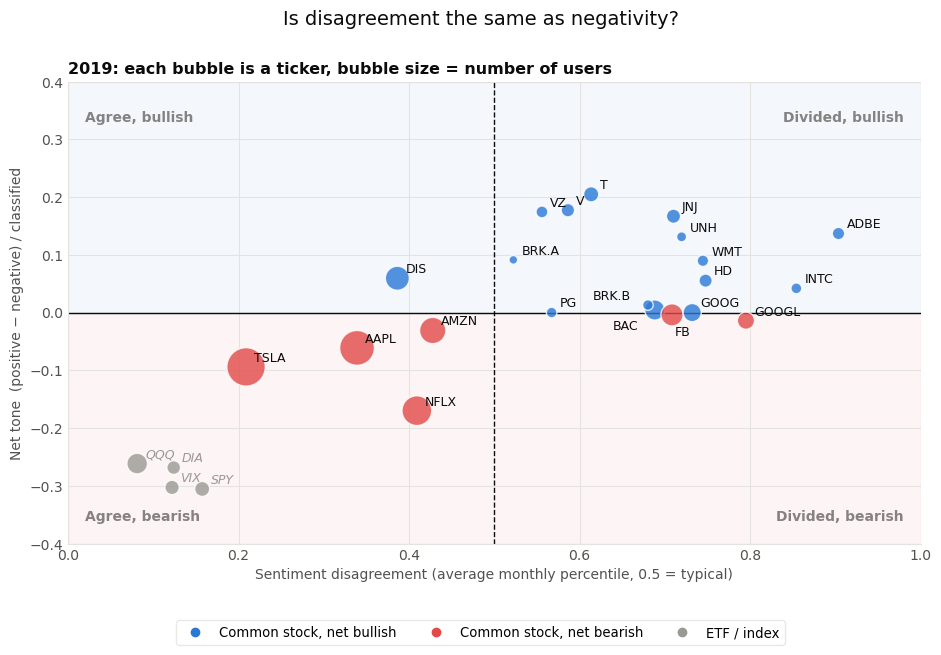

In [ ]:
# Figure 5: disagreement measures how divided users are, not whether they are negative
tone = year_view.dropna(subset=["sentiment_disagreement", "mean_net_tone"])
is_etf = tone["symbol"].isin(NON_COMMON_EQUITY)

fig, ax = plt.subplots(figsize=(11, 6))
ax.axhspan(0, 0.4, color=POS, alpha=0.05, zorder=0)
ax.axhspan(-0.4, 0, color=NEG, alpha=0.05, zorder=0)
ax.scatter(tone["sentiment_disagreement"], tone["mean_net_tone"], s=tone["unique_users"] / 25 + 20,
           color=np.where(is_etf, ETF_GREY, np.where(tone["mean_net_tone"] > 0, POS, NEG)), alpha=0.8, edgecolor="white", zorder=3)
LABEL_OFFSET = {"BRK.B": (-40, 4), "BAC": (-30, -14), "FB": (2, -15)}               # move apart the labels of the crowded cluster
for _, r in tone.iterrows():
    ax.annotate(r["symbol"], (r["sentiment_disagreement"], r["mean_net_tone"]), xytext=LABEL_OFFSET.get(r["symbol"], (6, 4)),
                textcoords="offset points",
                fontsize=9, color=ETF_GREY if r["symbol"] in NON_COMMON_EQUITY else INK, fontstyle="italic" if r["symbol"] in NON_COMMON_EQUITY else None)
ax.axhline(0, color=INK, linewidth=1)
ax.axvline(0.5, color=INK, linestyle="--", linewidth=1)
for xq, yq, txt, ha in [(0.02, 0.33, "Agree, bullish", "left"), (0.98, 0.33, "Divided, bullish", "right"),
                        (0.02, -0.36, "Agree, bearish", "left"), (0.98, -0.36, "Divided, bearish", "right")]:
    ax.text(xq, yq, txt, fontsize=10, color=INK_2, ha=ha, fontweight="bold", alpha=0.7)
ax.set_xlim(0, 1)
ax.set_ylim(-0.4, 0.4)
ax.set_xlabel("Sentiment disagreement (average monthly percentile, 0.5 = typical)", color=INK_2)
ax.set_ylabel("Net tone  (positive − negative) / classified", color=INK_2)
style(ax, grid="both")
title(ax, f"{ranking_year}: each bubble is a ticker, bubble size = number of users")

fig.legend(handles=[Line2D([], [], marker="o", linestyle="", color=POS, label="Common stock, net bullish"),
                    Line2D([], [], marker="o", linestyle="", color=NEG, label="Common stock, net bearish"),
                    Line2D([], [], marker="o", linestyle="", color=ETF_GREY, label="ETF / index")],
           loc="lower center", ncol=3, frameon=True, edgecolor=GRID, bbox_to_anchor=(0.5, -0.07), fontsize=9.5)
fig.suptitle("Is disagreement the same as negativity?", fontsize=14, color=INK, y=1.0)
plt.show()

Each bubble is a ticker in 2019: left–right = how divided its users are (disagreement percentile), up–down = net tone (share positive minus share negative), size = number of users.

The most *bearish* tickers are the ones where users **agree** the most: the index products (QQQ, DIA, VIX, SPY, net tone around −0.27 to −0.31) and the big popular names TSLA, AAPL and NFLX. The most *divided* tickers (ADBE, INTC, GOOGL, WMT) are neutral to mildly bullish. Disagreement and tone are therefore separate dimensions, and a high disagreement score should never be read as "investors are negative".

#### *4.6.6 Counting people instead of tweets*

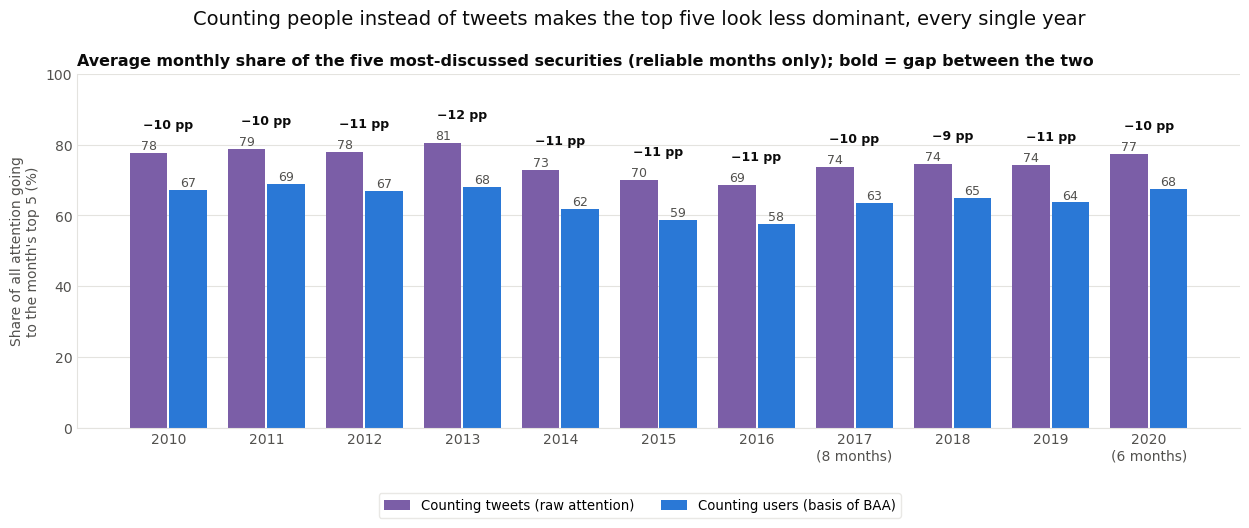

In [ ]:
# Figure 6 (Chart A): does counting tweets exaggerate how dominant the top five are, compared with counting users?
top5 = (valid_months.groupby("month")
        .agg(tweets=("raw_attention_share", lambda s: s.nlargest(5).sum()),     # share of tweets going to the month's top 5
             users=("broad_attention_share", lambda s: s.nlargest(5).sum())))    # same with user-capped, split multi-ticker attention
top5["year"] = top5.index.year
by_year = top5.groupby("year").agg(tweets=("tweets", "mean"), users=("users", "mean"), months=("tweets", "size")) * [100, 100, 1]
x = np.arange(len(by_year))

fig, ax = plt.subplots(figsize=(15, 4.6))
ax.bar(x - 0.2, by_year["tweets"], width=0.38, color=FACTOR_COLORS["raw_attention_percentile"], label="Counting tweets (raw attention)")
ax.bar(x + 0.2, by_year["users"], width=0.38, color=POS, label="Counting users (basis of BAA)")
for xi, (t, u) in enumerate(zip(by_year["tweets"], by_year["users"])):
    ax.text(xi - 0.2, t + 1, f"{t:.0f}", ha="center", fontsize=9, color=INK_2)
    ax.text(xi + 0.2, u + 1, f"{u:.0f}", ha="center", fontsize=9, color=INK_2)
    ax.text(xi, max(t, u) + 7, f"−{t - u:.0f} pp", ha="center", fontsize=9, color=INK, fontweight="bold")
ax.set_xticks(x, [f"{yr}" + (f"\n({m:.0f} months)" if m < 12 else "") for yr, m in zip(by_year.index, by_year["months"])])
ax.set_ylim(0, 100)
ax.set_ylabel("Share of all attention going\nto the month's top 5 (%)", color=INK_2)
style(ax, grid="y")
title(ax, "Average monthly share of the five most-discussed securities (reliable months only); bold = gap between the two")
fig.legend(loc="lower center", ncol=2, frameon=True, edgecolor=GRID, bbox_to_anchor=(0.5, -0.1), fontsize=9.5)
fig.suptitle("Counting people instead of tweets makes the top five look less dominant, every single year",
             fontsize=14, color=INK, y=1.02)
plt.show()

Each month we take the five most-discussed securities and measure their share of all attention, once counting **tweets** (purple) and once counting **users** (blue: each user counts at most once per stock, multi-ticker tweets are split). Bars are the yearly averages; the bold number is the gap.

In every year the top five look **9–12 percentage points less dominant** when we count people (58–69% of attention) than when we count tweets (69–81%). That gap is concentration created only by heavy posters and multi-ticker tweets, not by more people paying attention, and it is the reason BAA is built on users rather than raw tweet counts.

#### *4.6.7 Does unusual attention rotate across stocks?*

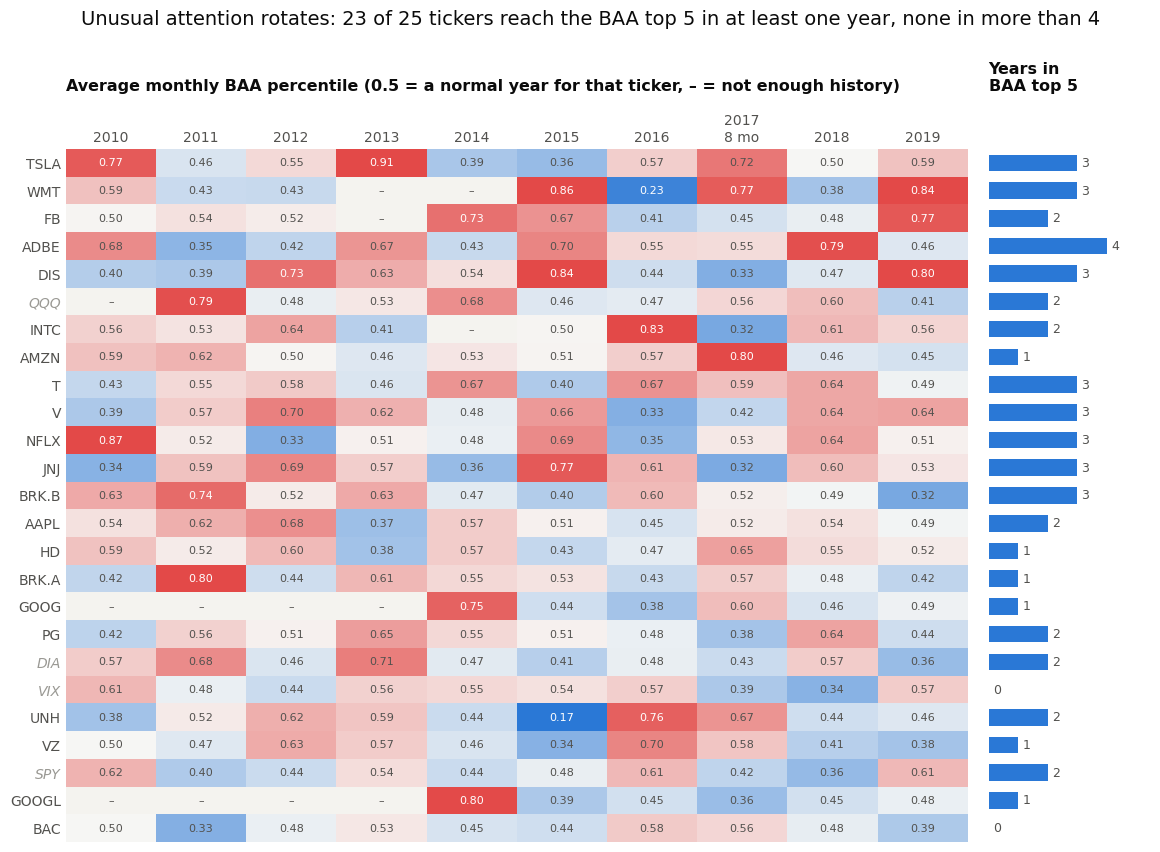

In [ ]:
# Figure 7 (Chart C): are the same stocks always "unusually hot", or does abnormal attention rotate?
heat = annual_summary.assign(symbol=annual_summary["symbol"].astype(str)).pivot(index="symbol", columns="year",
                                                                                 values="broad_abnormal_attention")
heat = heat.loc[heat.mean(axis=1).sort_values(ascending=False).index]          # hottest on average at the top
months_per_year = (valid_months.loc[valid_months["calendar_year"].between(heat.columns.min(), heat.columns.max())]
                   .groupby("calendar_year")["month"].nunique())
top5_count = heat.rank(ascending=False, method="min").le(5).sum(axis=1)         # in how many years was the ticker a BAA top 5?

cmap = LinearSegmentedColormap.from_list("baa", ["#2a78d6", "#f7f7f5", "#e34948"])  # blue = quieter than usual, red = unusually hot
cmap.set_bad("#f4f3ef")
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(14, 9), sharey=True, gridspec_kw={"width_ratios": [1, 0.18], "wspace": 0.04})
ax.imshow(heat.to_numpy(dtype=float), aspect="auto", cmap=cmap, vmin=0.2, vmax=0.8,
          extent=(-0.5, heat.shape[1] - 0.5, len(heat) - 0.5, -0.5))
for (yi, xi), v in np.ndenumerate(heat.to_numpy(dtype=float)):
    ax.text(xi, yi, "–" if np.isnan(v) else f"{v:.2f}", ha="center", va="center", fontsize=8,
            color="white" if (not np.isnan(v) and abs(v - 0.5) > 0.22) else INK_2)
ax.set_xticks(range(heat.shape[1]), [f"{yr}" + (f"\n{months_per_year.get(yr, 0)} mo" if months_per_year.get(yr, 12) < 12 else "")
                                     for yr in heat.columns])
ax.xaxis.tick_top()
ax.set_yticks(range(len(heat)), heat.index)
title(ax, "Average monthly BAA percentile (0.5 = a normal year for that ticker, – = not enough history)", pad=42)

ax2.barh(range(len(heat)), top5_count, color=POS, height=0.6)
for yi, n in enumerate(top5_count):
    ax2.text(n + 0.15, yi, f"{n}", va="center", fontsize=9, color=INK_2)
ax2.set_xlim(0, top5_count.max() + 1.5)
ax2.set_xticks([])
title(ax2, "Years in\nBAA top 5", pad=42)
for a in (ax, ax2):
    style(a, grid=None)
    a.spines[:].set_visible(False)
grey_etf_labels(ax)
fig.suptitle(f"Unusual attention rotates: {int((top5_count > 0).sum())} of {len(heat)} tickers reach the BAA top 5 "
             f"in at least one year, none in more than {top5_count.max()}", fontsize=14, color=INK, y=1.035)

Each cell is a ticker's average BAA percentile in one year: **red** = attention above that ticker's own normal level, **white** (≈ 0.5) = a normal year, **blue** = quieter than usual, **–** = not enough history yet. Rows are sorted by their average (hottest on top). The bar on the right counts the years in which the ticker was in the BAA top 5. 2017 is based on 8 months.

Red cells jump between rows from year to year: **23 of 25 tickers** reach the BAA top 5 at least once, and no ticker does so in more than 4 of the 10 years. Unusual attention therefore rotates rather than labelling the same stocks every time, so BAA brings new information each period, which is what a portfolio-sorting signal needs.

### ***Step 4.7:*** *Returns analysis: sample definition and limitations*

#### *Factor selection*

Broad abnormal attention is the preferred measure for the return analysis.

The evidence supporting this choice is:

- Its moderate correlation with raw attention shows that it retains information about visibility without simply reproducing tweet volume.
- Its low monthly persistence is consistent with an attention-shock measure.
- Its rankings identify securities experiencing unusual audience expansion rather than only permanently popular stocks.
- User capping and fractional allocation reduce sensitivity to prolific accounts and multi-ticker posts.
- Its near-zero correlation with disagreement indicates that it captures attention rather than heterogeneous beliefs.

Raw relative attention remains an important benchmark, while sentiment disagreement is best treated as a separate secondary factor. Prior research also associates disagreement more naturally with trading volume and volatility, although return effects can additionally be examined.

In [ ]:
# Load only the CRSP columns needed for index checks, security matching and monthly returns.
CRSP_COLUMNS = ["INDNO", "PERMNO", "Ticker", "MbrStartDt", "MbrEndDt", "ShareType", "SecurityType", "SecuritySubType",
                "USIncFlg", "IssuerType", "DlyCalDt", "DlyRet", "DlyRetMissFlg"]
crsp = pd.read_csv("crsp_sp500_2007_2023.csv.gz", usecols=CRSP_COLUMNS, dtype={"Ticker": "string", "DlyRetMissFlg": "string"})
for column in ["DlyCalDt", "MbrStartDt", "MbrEndDt"]:
    crsp[column] = pd.to_datetime(crsp[column], errors="coerce")

CRSP contains the data for the period the stocks were in an index, more specifically the S&P 500. We first need to check that there is return information for the tickers that are in our tweets data.

In [ ]:
# Quick checks on the CRSP extract (discussed in the markdown below).
crsp_sample = crsp.loc[crsp["DlyCalDt"].between("2010-01-01", "2020-07-31")]   # our return period
print(f"{len(crsp):,} security-days, {crsp['PERMNO'].nunique()} PERMNOs, "
      f"{crsp['DlyCalDt'].min():%Y-%m-%d} to {crsp['DlyCalDt'].max():%Y-%m-%d}")
print("Index identifiers (INDNO):", crsp["INDNO"].unique().tolist(), "-> S&P 500 constituents only")
print(f"Missing daily returns: {crsp['DlyRet'].isna().mean():.2%}, days with a return flag: {crsp['DlyRetMissFlg'].notna().sum()}")
print("Duplicate PERMNO-date rows in 2010-2020:", int(crsp_sample.duplicated(["PERMNO", "DlyCalDt"]).sum()))
print(f"Rows inside the S&P 500 membership window: {crsp_sample['DlyCalDt'].between(crsp_sample['MbrStartDt'], crsp_sample['MbrEndDt']).mean():.0%}")

2,149,139 security-days, 891 PERMNOs, 2007-01-03 to 2023-12-29
Index identifiers (INDNO): [1000500] -> S&P 500 constituents only
Missing daily returns: 0.00%, days with a return flag: 77
Duplicate PERMNO-date rows in 2010-2020: 0
Rows inside the S&P 500 membership window: 100%


#### *Scope of the available CRSP data*

The CRSP extract used here was obtained from WRDS; it is not an unrestricted extract of the CRSP US stock database. Every observation is associated with `INDNO = 1000500`, identifying the historical S&P 500 constituent universe. The return analysis must therefore be interpreted as an examination of the relationship between StockTwits attention and subsequent returns **within the available S&P 500 constituent subsample**. It is not a test covering the complete original StockTwits ticker universe.

#### *Time-varying security coverage*

A stock is included in a monthly return portfolio only when:

1. It belongs to the original StockTwits ticker universe.
2. It is classified as an eligible common equity rather than an ETF or index.
3. Its attention factor is available in month \(t\).
4. A valid CRSP security match can be established.
5. A valid subsequent return is available for the relevant return period.

The number of eligible securities can therefore change from month to month. Portfolio results must report the number of included stocks in each month and the number assigned to each portfolio. Missing returns are never replaced with zero. A missing observation means that the return is unavailable in this extract.

#### *Index-membership selection*

Companies included in S&P 500 are generally large, liquid and established, and index inclusion or removal is related to firm characteristics and corporate events. The resulting sample is therefore systematically different from the broader equity market. The findings proposed consequently cannot be generalized directly to:

- Small-capitalization firms.
- Less liquid securities.
- Firms that never entered the S&P 500.
- The complete population of stocks discussed on StockTwits.

The restriction may also reduce variation in firm size, liquidity and investor recognition, potentially making the estimated attention effect smaller or different from the effect in the broader market.

#### *Incomplete coverage around index entry and exit*

Some StockTwits securities may enter the return dataset only after joining the S&P 500. Their earlier returns can therefore be absent even though the firms were already publicly traded. TSLA is a particularly important potential example because it represents a large share of publication activity but may have little or no usable coverage during the factor sample. Index inclusion can itself generate both media attention and unusual returns. An observed relationship between BAA and returns may therefore partly reflect index-entry events rather than an independent StockTwits-attention effect.

Similarly, a security may disappear from the constituent extract after index removal even though it continues trading. Returns following removal may then be unavailable. Dropping such observations can produce non-random attrition if index removals are associated with poor performance. For these reasons, the current return analysis is considered a preliminary, conditional test. An unrestricted CRSP extract for the selected `PERMNO`s would be required for the strongest specification.

#### *Portfolio size*

After excluding `SPY`, `QQQ`, `DIA`, and `VIX`, the original attention universe contains only about 21 eligible equities. Considering that we build 10 portfolios, some of them might include stocks that dominate the majority of the portfolio share. These compositions should not be treated as well-diversified factor returns.

Five BAA portfolios are therefore also constructed as a robustness check. Quintiles contain more securities per portfolio and provide a more stable assessment of whether returns vary monotonically with attention.

The analysis will report:

- The number of securities available each month.
- The number of securities in each decile and quintile.
- Equal-weighted portfolio returns.
- The high-minus-low return spread.
- Results using the continuous BAA measure, without portfolio grouping.

#### *Timing and interpretation*

Attention is measured during month \(t\), while portfolio returns are measured during month \(t+1\). This reduces look-ahead bias and separates return prediction from the possibility that tweets merely respond to price movements occurring in the same month.

Nevertheless, the analysis identifies an association rather than a causal effect. A significant high-minus-low return could reflect StockTwits attention, corporate news, index-membership events, momentum, firm size, liquidity, or another correlated characteristic.

Accordingly, BAA should be described as a promising return predictor only if the relationship:

1. Is economically meaningful.
2. Is statistically distinguishable from zero.
3. Is reasonably monotonic across portfolios.
4. Remains visible in quintile and continuous-regression tests.
5. Is not driven by a small number of stocks or index-entry months.
6. Survives conventional risk adjustment where feasible.

In [ ]:
# Prepare the CRSP data for merging with the StockTwits data.
crsp_work = crsp.drop(columns="INDNO")
crsp_work["return_month"] = crsp_work["DlyCalDt"].dt.to_period("M")
crsp_work["has_return_flag"] = crsp_work["DlyRetMissFlg"].fillna("").str.strip().ne("")    # exceptional return codes (NS, MP, ...)

In [ ]:
# Point-in-time PERMNO matching.
# Matching on the ticker alone attaches two PERMNOs to GOOG after April 2014: PERMNO 90319 traded as GOOG until
# 2014-04-02 and as GOOGL afterwards, while PERMNO 14542 is GOOG from 2014-04-03. We therefore keep the PERMNO that
# carried the ticker on the formation date (last trading day of month t). The CRSP file only contains index members,
# so being present on that date also means the stock belongs to the S&P 500 at formation.
# CRSP lists Berkshire class B as "BRK"; class A (BRK.A) is not an S&P 500 constituent.
TICKER_ALIASES = {"BRKB": "BRK"}
last_trading_date = crsp_work.groupby("return_month")["DlyCalDt"].max()          # portfolio formation date of each month

# Start from valid StockTwits factor observations of common equities, with tickers spelled like CRSP (BRK.B -> BRKB).
formation_universe = analysis_month.loc[analysis_month["usable_for_factor"] & analysis_month["eligible_for_portfolio"]
                                        & analysis_month["broad_abnormal_attention"].notna()].copy()
formation_universe["crsp_ticker"] = (formation_universe["symbol"].astype("string").str.upper().str.strip()
                                     .str.replace(r"[.\-/]", "", regex=True).replace(TICKER_ALIASES))

common_equity = (crsp_work["ShareType"].eq("NS") & crsp_work["SecurityType"].eq("EQTY") & crsp_work["SecuritySubType"].eq("COM")
                 & crsp_work["USIncFlg"].eq("Y") & crsp_work["IssuerType"].eq("CORP"))
on_month_end = crsp_work["DlyCalDt"].eq(crsp_work["return_month"].map(last_trading_date))

month_end_ids = (crsp_work.loc[common_equity & on_month_end, ["return_month", "Ticker", "PERMNO"]]
                 .rename(columns={"return_month": "month", "Ticker": "crsp_ticker"}))
month_end_ids["crsp_ticker"] = month_end_ids["crsp_ticker"].str.upper().str.strip().str.replace(r"[.\-/]", "", regex=True)
month_end_ids = month_end_ids.drop_duplicates(["month", "crsp_ticker"])

formation_sample = formation_universe.merge(month_end_ids, on=["month", "crsp_ticker"], how="inner", validate="one_to_one")
assert not formation_sample.duplicated(["month", "symbol"]).any()
assert not formation_sample.duplicated(["month", "PERMNO"]).any()

matched = formation_sample.groupby("symbol")["month"].agg(["min", "nunique"])
unmatched = sorted(set(formation_universe["symbol"].astype(str)) - set(formation_sample["symbol"].astype(str)))
late = matched.loc[matched["nunique"] < formation_sample["month"].nunique()]
print(f"Stock-months matched to a CRSP PERMNO: {len(formation_sample):,} ({matched.shape[0]} stocks)")
print("StockTwit equities never in the S&P 500 file during the sample:", unmatched)
print("Stocks that enter the sample later:", ", ".join(f"{s} (from {r['min']})" for s, r in late.iterrows()))

Stock-months matched to a CRSP PERMNO: 2,208 (19 stocks)
Twitter equities never in the S&P 500 file during the sample: ['BRK.A', 'TSLA']
Stocks that enter the sample later: BRK.B (from 2010-02), FB (from 2013-12), GOOGL (from 2014-04), NFLX (from 2010-12)


In [ ]:
# BAA PORTFOLIO FORMATION: rank BAA across the matched stocks every month.
formation_sample = formation_sample.sort_values(["month", "broad_abnormal_attention", "symbol"]).reset_index(drop=True)
formation_sample["n_eligible_stocks"] = formation_sample.groupby("month")["symbol"].transform("nunique")
formation_sample["baa_sort_percentile"] = formation_sample.groupby("month")["broad_abnormal_attention"].rank(method="first", pct=True)

# Ten portfolios required by the assignment, then five as a robustness check due to the small number of stocks in some months.
for portfolio, k in [("baa_decile", 10), ("baa_quintile", 5)]:
    formation_sample[portfolio] = (np.ceil(k * formation_sample["baa_sort_percentile"]).clip(1, k)
                                   .where(formation_sample["n_eligible_stocks"].ge(k)).astype("Int8"))

formation_sample["return_month"] = formation_sample["month"] + 1                 # returns are measured in the following month
portfolio_assignments = formation_sample[["month", "return_month", "symbol", "PERMNO", "broad_abnormal_attention",
                                          "baa_sort_percentile", "baa_decile", "baa_quintile", "n_eligible_stocks"]].copy()

In [ ]:
# CRSP returns are daily but the analysis is monthly: compound the daily returns of every portfolio PERMNO.
market_trading_days = crsp_work.groupby("return_month")["DlyCalDt"].nunique().rename("market_trading_days")  # trading days in the index calendar

crsp_returns = crsp_work.loc[crsp_work["PERMNO"].isin(portfolio_assignments["PERMNO"].unique())]
monthly_crsp_returns = (crsp_returns.assign(gross_return=1 + crsp_returns["DlyRet"])      # DlyRet is decimal: 0.02 = 2%, gross = 1.02
    .groupby(["PERMNO", "return_month"])
    .agg(gross_monthly_return=("gross_return", "prod"), trading_days=("DlyCalDt", "nunique"), flagged_days=("has_return_flag", "sum"))
    .reset_index()
    .merge(market_trading_days.reset_index(), on="return_month", how="left", validate="many_to_one"))
monthly_crsp_returns["monthly_return"] = monthly_crsp_returns["gross_monthly_return"] - 1

# Conservative definition of a usable return: every trading day of the month is present and no day carries a return flag.
monthly_crsp_returns["valid_return"] = (monthly_crsp_returns["monthly_return"].notna()
                                        & monthly_crsp_returns["trading_days"].eq(monthly_crsp_returns["market_trading_days"])
                                        & monthly_crsp_returns["flagged_days"].eq(0))

In [ ]:
# Merge the portfolios formed in t with the returns of t+1.
# Missing or incomplete returns remain missing: they are never converted to zero, which would be confused with a zero return.
portfolio_return_panel = portfolio_assignments.merge(monthly_crsp_returns[["PERMNO", "return_month", "monthly_return", "valid_return"]],
                                                     on=["PERMNO", "return_month"], how="left", validate="many_to_one")
portfolio_return_panel["realized_return"] = portfolio_return_panel["monthly_return"].where(portfolio_return_panel["valid_return"].eq(True))

# Coverage and timing checks
stocks_per_month = portfolio_return_panel.groupby("month")["symbol"].nunique()
assert portfolio_return_panel["return_month"].eq(portfolio_return_panel["month"] + 1).all()   # attention in t, return in t+1
assert not portfolio_return_panel.duplicated(["month", "symbol"]).any()                      # one observation per stock-month
print(f"{portfolio_return_panel['realized_return'].notna().sum():,} of {len(portfolio_return_panel):,} stock-months have a valid "
      f"next-month return, over {stocks_per_month.size} formation months "
      f"({stocks_per_month.min()}-{stocks_per_month.max()} stocks per month, {stocks_per_month.mean():.1f} on average)")

2,208 of 2,208 stock-months have a valid next-month return, over 122 formation months (15-19 stocks per month, 18.1 on average)


### ***Step 4.8:*** *Does media attention predict returns?*

We now test whether stocks with an attention shock in month t (high BAA) earn different returns in month t+1, in four steps: portfolio sorts (4.8.1), same month vs next month (4.8.2), then in Task 5 returns after removing the five Fama-French risk factors (5.1–5.2), and whether the long-short portfolio is a new factor (5.3).

**How to read the dot charts.** Each dot is an estimate and its bar the 95% confidence interval, using Newey-West standard errors (3 lags) to allow for autocorrelation in monthly returns. Blue = significantly above zero, red = significantly below, grey = not significant at 5%; stars give the p-value.

In [ ]:
NW_LAGS = 3                                                                     # Newey-West lags for monthly series

def newey_west_mean(series, lags=NW_LAGS):
    """Mean of a monthly series with its Newey-West (HAC) standard error and t-statistic."""
    values = pd.Series(series).dropna().to_numpy()
    fit = sm.OLS(values, np.ones(len(values))).fit(cov_type="HAC", cov_kwds={"maxlags": lags})
    return fit.params[0], fit.bse[0], fit.tvalues[0]

def stars(t):
    return "***" if abs(t) > 3.29 else "**" if abs(t) > 2.58 else "*" if abs(t) > 1.96 else ""

def dot_ci(ax, labels, means, ses, ts, fmt="{:+.2f}", ref=0.0, notes=None):
    """One row per estimate: dot = estimate, bar = 95% CI; blue/red if significantly above/below ref, grey otherwise."""
    notes = notes or [""] * len(labels)
    for yi, (m, se, t, note) in enumerate(zip(means, ses, ts, notes)):
        color = (POS if m > ref else NEG) if abs(t) > 1.96 else ETF_GREY
        ax.errorbar(m, yi, xerr=1.96 * se, fmt="o", color=color, markersize=8, capsize=4, linewidth=2)
        ax.text(m, yi - 0.28, fmt.format(m) + stars(t) + (f"  ({note})" if note else ""), ha="center", fontsize=9.5, color=INK_2)
    ax.axvline(ref, color=INK, linestyle="--", linewidth=1)
    ax.set_yticks(range(len(labels)), labels)
    ax.set_ylim(len(labels) - 0.5, -0.8)
    style(ax)

def portfolio_bars(ax, wide, k, color, label=None, offset=0.0, width=0.7):
    """Average monthly return (%) of portfolios 1..k with 95% Newey-West CI."""
    est = [newey_west_mean(100 * wide[p]) for p in range(1, k + 1)]
    ax.bar(np.arange(1, k + 1) + offset, [e[0] for e in est], yerr=[1.96 * e[1] for e in est], width=width, color=color,
           capsize=3, error_kw={"elinewidth": 1, "ecolor": INK_2}, label=label)
    ax.axhline(0, color=INK, linewidth=1)
    ax.set_xticks(range(1, k + 1), [f"{p}\nLow BAA" if p == 1 else f"{p}\nHigh BAA" if p == k else str(p) for p in range(1, k + 1)])
    style(ax, grid="y")

SIG_LEGEND = [Line2D([], [], marker="o", linestyle="", color=POS, label="Positive, significant at 5%"),
              Line2D([], [], marker="o", linestyle="", color=NEG, label="Negative, significant at 5%"),
              Line2D([], [], marker="o", linestyle="", color=ETF_GREY, label="Not significant at 5%"),
              Line2D([], [], linestyle="", label="* p<0.05   ** p<0.01   *** p<0.001   (bars = 95% CI, Newey-West)")]

#### *4.8.1 Portfolio returns by BAA: attention in month t, returns in month t+1*

In [ ]:
# Equal-weighted portfolio returns in every month, then high minus low (top minus bottom portfolio).
def portfolio_returns(group_column):
    return (portfolio_return_panel.dropna(subset=[group_column, "realized_return"])
            .groupby(["return_month", group_column], observed=True)
            .agg(portfolio_return=("realized_return", "mean"), number_of_stocks=("symbol", "nunique"))
            .reset_index())

decile_returns = portfolio_returns("baa_decile")
quintile_returns = portfolio_returns("baa_quintile")

# Indexed by return month (t+1): the FF5 regressions of Step 5.3 join on this index
decile_wide = decile_returns.pivot(index="return_month", columns="baa_decile", values="portfolio_return")
decile_wide["high_minus_low"] = decile_wide[10] - decile_wide[1]                 # decile 10 minus decile 1
quintile_wide = quintile_returns.pivot(index="return_month", columns="baa_quintile", values="portfolio_return")
quintile_wide["high_minus_low"] = quintile_wide[5] - quintile_wide[1]            # quintile 5 minus quintile 1

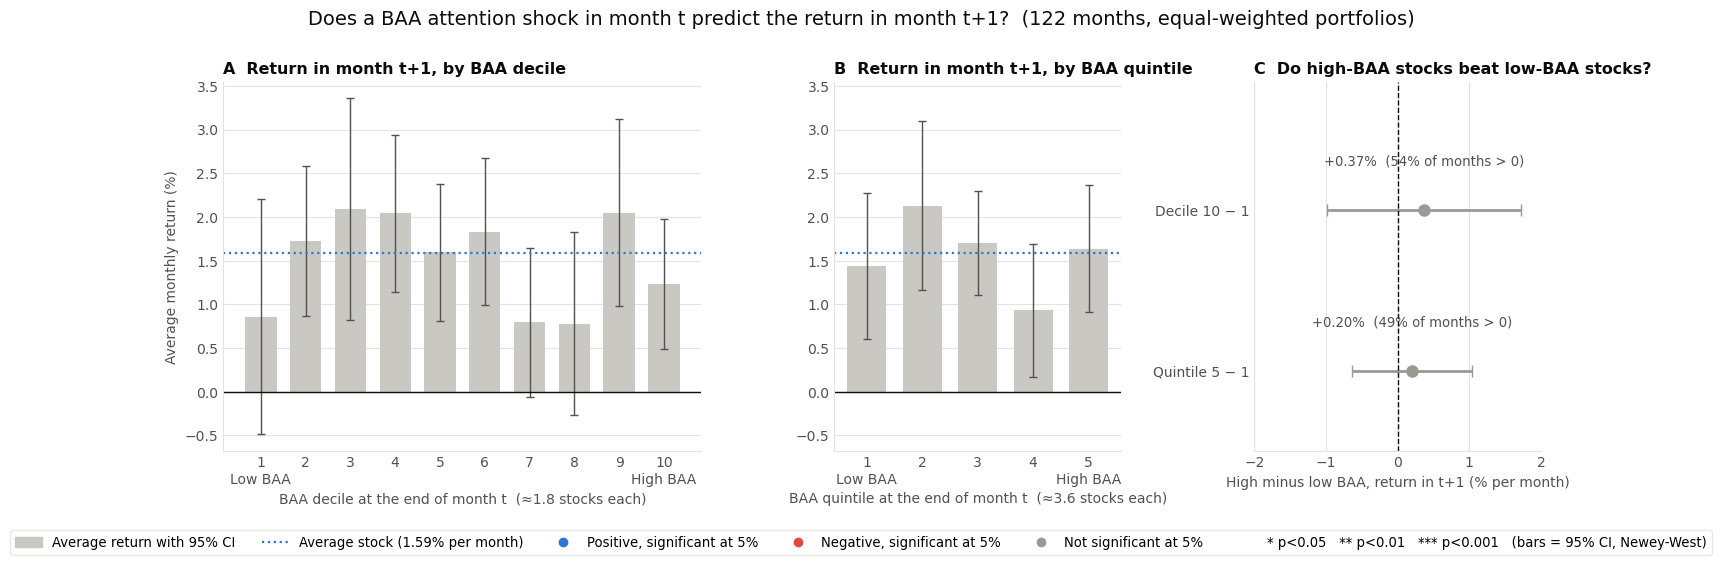

In [ ]:
# Average next-month return of each BAA portfolio, and the high-minus-low spread
spreads = {"Decile 10 − 1": decile_wide["high_minus_low"], "Quintile 5 − 1": quintile_wide["high_minus_low"]}
spread_est = {name: newey_west_mean(100 * s) for name, s in spreads.items()}
stocks_per_portfolio = {k: r.groupby(c)["number_of_stocks"].mean()
                        for k, r, c in [(10, decile_returns, "baa_decile"), (5, quintile_returns, "baa_quintile")]}
all_stocks = 100 * portfolio_return_panel.groupby("return_month")["realized_return"].mean().mean()   # equal-weighted average stock

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 4.8), gridspec_kw={"width_ratios": [1.5, 0.9, 0.9], "wspace": 0.38})
ax2.sharey(ax1)
for ax, wide, k, name in [(ax1, decile_wide, 10, "decile"), (ax2, quintile_wide, 5, "quintile")]:
    portfolio_bars(ax, wide, k, NEU)
    ax.axhline(all_stocks, color=POS, linestyle=":", linewidth=1.6)
    ax.set_xlabel(f"BAA {name} at the end of month t  (≈{stocks_per_portfolio[k].mean():.1f} stocks each)", color=INK_2)
    title(ax, f"{'A' if k == 10 else 'B'}  Return in month t+1, by BAA {name}")
ax1.set_ylabel("Average monthly return (%)", color=INK_2)

dot_ci(ax3, list(spreads), *zip(*spread_est.values()), fmt="{:+.2f}%",
       notes=[f"{(s > 0).mean():.0%} of months > 0" for s in spreads.values()])
ax3.set_xlim(-2, 2)
ax3.set_xlabel("High minus low BAA, return in t+1 (% per month)", color=INK_2)
title(ax3, "C  Do high-BAA stocks beat low-BAA stocks?")

fig.legend(handles=[Patch(color=NEU, label="Average return with 95% CI"),
                    Line2D([], [], color=POS, linestyle=":", linewidth=1.6, label=f"Average stock ({all_stocks:.2f}% per month)")]
                   + SIG_LEGEND,
           loc="lower center", ncol=6, frameon=True, edgecolor=GRID, bbox_to_anchor=(0.5, -0.12), fontsize=9.5)
fig.suptitle(f"Does a BAA attention shock in month t predict the return in month t+1?  "
             f"({decile_wide.shape[0]} months, equal-weighted portfolios)", fontsize=14, color=INK, y=1.03)
plt.show()

Every month we sort the matched stocks into 10 deciles (and 5 quintiles) by BAA and hold each equal-weighted portfolio over the next month. *Panel A* and *Panel B* show the average monthly return of each portfolio (bars = 95% CI); the dotted line is the average stock. *Panel C* shows the high-minus-low spread: the return of buying the high-BAA portfolio and shorting the low-BAA one.

- **No pattern across portfolios.** Returns go up and down between deciles (0.8% to 2.1% per month) with no tendency to rise or fall with BAA, and every confidence interval includes the average stock (1.59% per month).
- **The spread is small and not significant:** +0.37% per month for decile 10 − 1 (t = 0.54) and +0.20% for quintile 5 − 1 (t = 0.47). It is positive in only about half of the months (54% and 49%).
- Deciles hold only about 1.8 stocks each, so single stocks drive them; quintiles (about 3.6 stocks) are more reliable and tell the same story.

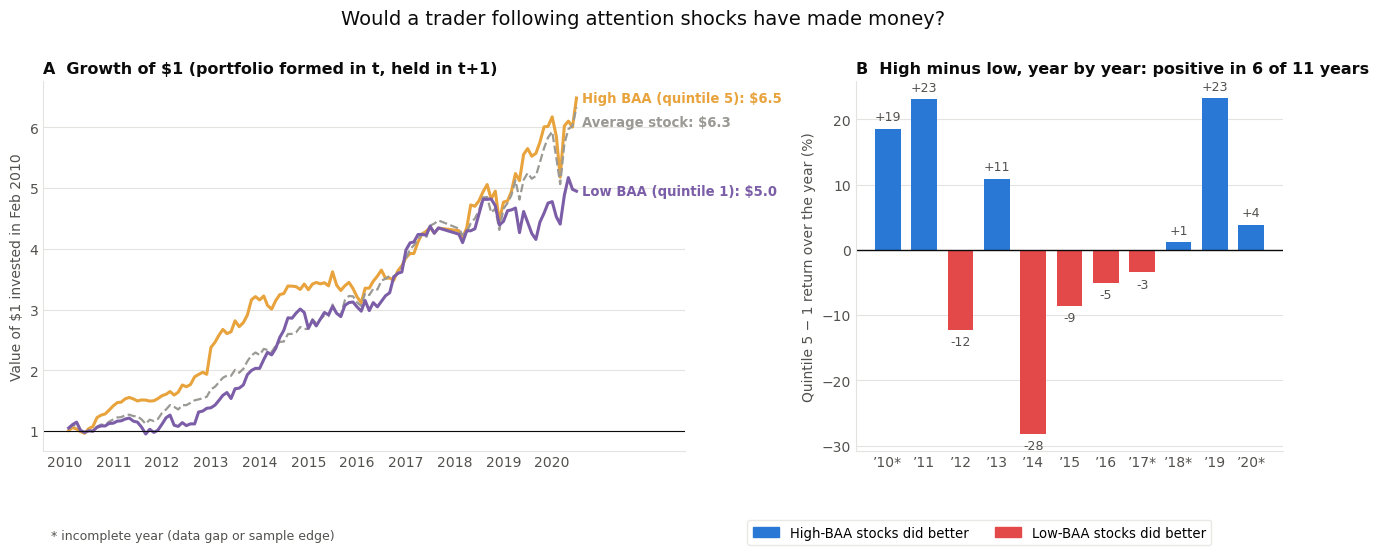

In [ ]:
# What would $1 have become, and in how many years did high-BAA stocks beat low-BAA stocks?
HIGH, LOW = "#e8a33d", "#7b5ea7"                                                # high-BAA = amber, low-BAA = purple
average_stock = portfolio_return_panel.groupby("return_month")["realized_return"].mean()
lines = {"High BAA (quintile 5)": (quintile_wide[5], HIGH), "Low BAA (quintile 1)": (quintile_wide[1], LOW),
         "Average stock": (average_stock, ETF_GREY)}
hl_by_year = (1 + quintile_wide["high_minus_low"]).groupby(quintile_wide.index.year)
yearly_spread = 100 * (hl_by_year.prod() - 1)                                  # compounded long-short return per year
months_in_year = hl_by_year.size()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4.8), gridspec_kw={"width_ratios": [1.5, 1], "wspace": 0.32})
label_y = []
for name, (series, color) in sorted(lines.items(), key=lambda kv: -(1 + kv[1][0].dropna()).prod()):
    growth = (1 + series.dropna()).cumprod()
    ax1.plot(growth.index.to_timestamp(), growth.values, color=color, linewidth=2.2 if name != "Average stock" else 1.6,
             linestyle="-" if name != "Average stock" else "--")
    y_text = min([growth.iloc[-1]] + [y - 0.4 for y in label_y])                # keep end labels from overlapping
    label_y.append(y_text)
    ax1.text(growth.index[-1].to_timestamp() + pd.Timedelta(days=40), y_text, f"{name}: ${growth.iloc[-1]:.1f}",
             va="center", fontsize=9.5, color=color, fontweight="bold")
ax1.axhline(1, color=INK, linewidth=0.8)
ax1.set_xlim(right=ax1.get_xlim()[1] + 620)
ax1.set_xticks([pd.Timestamp(f"{y}-01-01") for y in range(2010, 2021)], range(2010, 2021))
ax1.set_ylabel("Value of $1 invested in Feb 2010", color=INK_2)
style(ax1, grid="y")
title(ax1, "A  Growth of $1 (portfolio formed in t, held in t+1)")

years = yearly_spread.index
ax2.bar(years, yearly_spread, color=np.where(yearly_spread > 0, POS, NEG), width=0.7)
for yr, v in yearly_spread.items():
    ax2.text(yr, v + (0.8 if v >= 0 else -0.8), f"{v:+.0f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9, color=INK_2)
ax2.axhline(0, color=INK, linewidth=1)
ax2.set_xticks(years, [f"’{str(y)[2:]}" + ("*" if months_in_year[y] < 12 else "") for y in years])
ax2.set_ylabel("Quintile 5 − 1 return over the year (%)", color=INK_2)
style(ax2, grid="y")
title(ax2, f"B  High minus low, year by year: positive in {(yearly_spread > 0).sum()} of {len(yearly_spread)} years")

fig.legend(handles=[Patch(color=POS, label="High-BAA stocks did better"), Patch(color=NEG, label="Low-BAA stocks did better")],
           loc="lower center", ncol=2, frameon=True, edgecolor=GRID, bbox_to_anchor=(0.71, -0.1), fontsize=9.5)
fig.text(0.13, -0.075, "* incomplete year (data gap or sample edge)", fontsize=9, color=INK_2)
fig.suptitle("Would a trader following attention shocks have made money?", fontsize=14, color=INK, y=1.03)
plt.show()

*Panel A:* the value of $1 invested in February 2010 in the high-BAA and low-BAA quintile portfolios (rebalanced every month), compared with the equal-weighted average stock. *Panel B:* the return of the long-short portfolio (quintile 5 − 1) in each calendar year.

The high-BAA portfolio ends at \$6.5 against \$5.0 for low-BAA, but the path matters: the gap opens in 2010–2013, closes completely by 2017 and re-opens only in 2019–2020, and high-BAA ends barely above the average stock (\$6.3). Year by year the long-short return is positive in 6 years and negative in 5, including −28% in 2014. A strategy that wins and loses in alternating years with an insignificant average is not a reliable trading signal.

#### *4.8.2 Same month vs next month*

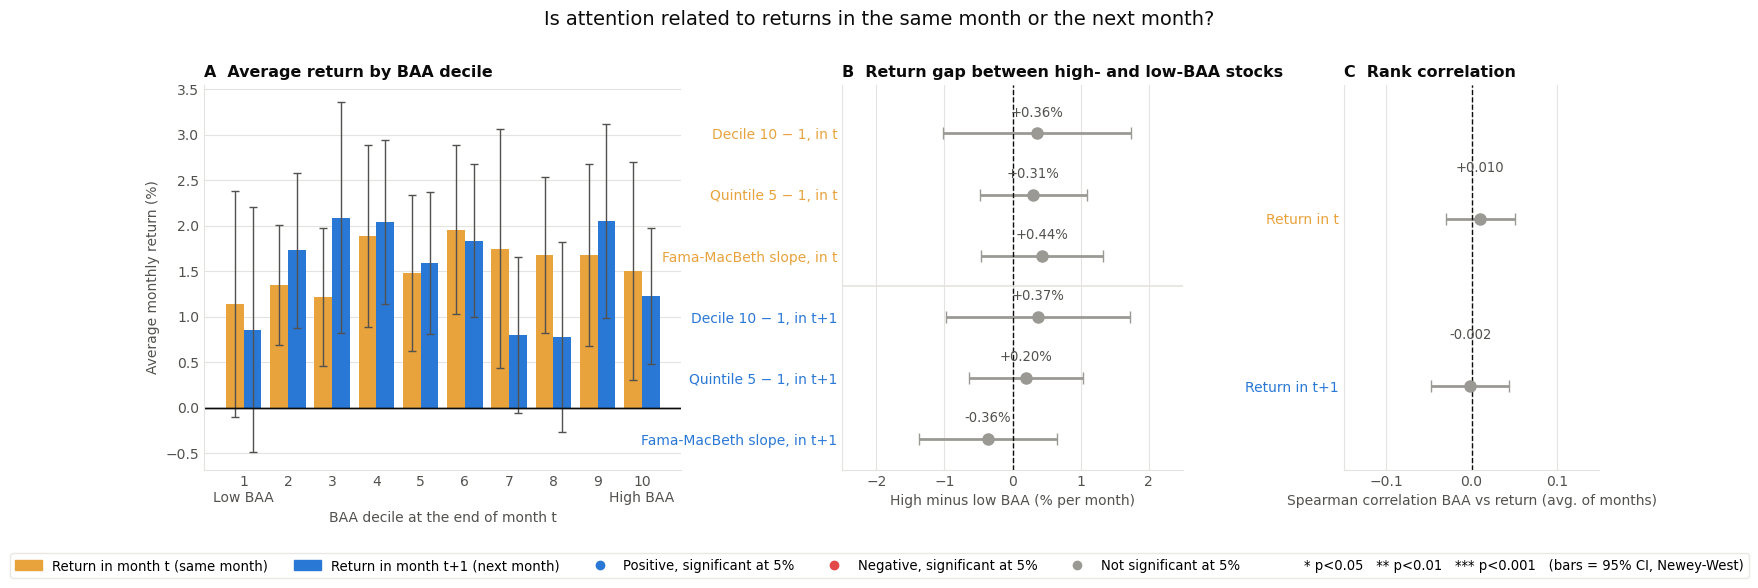

In [ ]:
# Is attention related to returns in the SAME month (tweets react to prices) or the NEXT month (prediction)?
# Same-month panel: portfolios formed in t, returns also in t (not tradable: attention is only known at the end of t).
same_month_panel = (portfolio_assignments.drop(columns="return_month")
    .merge(monthly_crsp_returns[["PERMNO", "return_month", "monthly_return", "valid_return"]],
           left_on=["PERMNO", "month"], right_on=["PERMNO", "return_month"], how="left", validate="many_to_one"))
same_month_panel["realized_return"] = same_month_panel["monthly_return"].where(same_month_panel["valid_return"].eq(True))

def portfolio_table(panel_df, group_column, value_column="realized_return"):
    """Equal-weighted portfolio average per month (rows) and portfolio (columns), plus top minus bottom."""
    table = (panel_df.dropna(subset=[group_column, value_column])
             .groupby(["month", group_column], observed=True)[value_column].mean().unstack(group_column))
    table["high_minus_low"] = table[table.columns.max()] - table[table.columns.min()]
    return table

def cross_sectional_tests(panel_df, value_column="realized_return", signal="baa_sort_percentile", min_stocks=5):
    """Fama-MacBeth: each month regress returns on the BAA percentile (slope = top vs bottom BAA stock) + Spearman correlation."""
    rows = []
    for month, cs in panel_df.dropna(subset=[signal, value_column]).groupby("month"):
        if len(cs) >= min_stocks:
            rows.append({"month": month, "slope": np.polyfit(cs[signal], cs[value_column], 1)[0],
                         "rank_correlation": cs[signal].corr(cs[value_column], method="spearman")})
    return pd.DataFrame(rows).set_index("month")

same_decile_wide = portfolio_table(same_month_panel, "baa_decile")
same_quintile_wide = portfolio_table(same_month_panel, "baa_quintile")
fmb = {"t": cross_sectional_tests(same_month_panel), "t+1": cross_sectional_tests(portfolio_return_panel)}

T_COLOR, T1_COLOR = "#e8a33d", POS                                              # same month = amber, next month = blue
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), gridspec_kw={"width_ratios": [1.4, 1, 0.75], "wspace": 0.45})

# Panel A: average return by decile in the SAME month
portfolio_bars(ax1, same_decile_wide, 10, T_COLOR)
ax1.set_xlabel("BAA decile at the end of month t", color=INK_2)
ax1.set_ylabel("Average return in month t (%)", color=INK_2)
title(ax1, "A  Same-month return by BAA decile")

# Panel B: high-minus-low spreads and Fama-MacBeth slopes (all in % per month)
tests = {"Decile 10 − 1, in t": same_decile_wide["high_minus_low"], "Quintile 5 − 1, in t": same_quintile_wide["high_minus_low"],
         "Fama-MacBeth slope, in t": fmb["t"]["slope"],
         "Decile 10 − 1, in t+1": decile_wide["high_minus_low"], "Quintile 5 − 1, in t+1": quintile_wide["high_minus_low"],
         "Fama-MacBeth slope, in t+1": fmb["t+1"]["slope"]}
dot_ci(ax2, list(tests), *zip(*[newey_west_mean(100 * s) for s in tests.values()]), fmt="{:+.2f}%")
ax2.axhline(2.5, color=GRID, linewidth=1.2)
for lbl in ax2.get_yticklabels():
    lbl.set_color(T_COLOR if lbl.get_text().endswith("in t") else T1_COLOR)
ax2.set_xlim(-2.5, 2.5)
ax2.set_xlabel("High minus low BAA (% per month)", color=INK_2)
title(ax2, "B  Return gap between high- and low-BAA stocks")

# Panel C: average monthly rank correlation between BAA and returns
dot_ci(ax3, ["Return in t", "Return in t+1"], *zip(*[newey_west_mean(fmb[k]["rank_correlation"]) for k in ["t", "t+1"]]), fmt="{:+.3f}")
for lbl, c in zip(ax3.get_yticklabels(), [T_COLOR, T1_COLOR]):
    lbl.set_color(c)
ax3.set_xlim(-0.15, 0.15)
ax3.set_xticks([-0.1, 0, 0.1])
ax3.set_xlabel("Spearman correlation BAA vs return (avg. of months)", color=INK_2)
title(ax3, "C  Rank correlation")

fig.legend(handles=[Patch(color=T_COLOR, label="Return in month t (same month)"), Patch(color=T1_COLOR, label="Return in month t+1 (next month)")]
                   + SIG_LEGEND, loc="lower center", ncol=6, frameon=True, edgecolor=GRID, bbox_to_anchor=(0.5, -0.12), fontsize=9.5)
fig.suptitle("Is attention related to returns in the same month or the next month?", fontsize=14, color=INK, y=1.03)
plt.show()

We repeat the sort using the return of the *same* month t in which attention is measured (amber) and compare it with the next month t+1 (blue). The same-month version is not a tradable strategy, because attention is only known at the end of month t, but it shows whether attention and returns move together, for example because tweets react to price moves. *Panel B* adds a Fama-MacBeth test that uses every stock instead of portfolios: each month we regress returns on the BAA percentile (0 = lowest, 1 = highest), so the slope is the return gap between the highest- and lowest-BAA stock. *Panel C* is the average monthly rank correlation between BAA and returns.

- **Neither timing shows a reliable link.** In the same month high-BAA stocks earn slightly more (+0.31% to +0.44% per month); in the next month the three estimates point in different directions (+0.37%, +0.20%, −0.36%). All six confidence intervals include zero.
- **The rank correlation is essentially zero** in both cases (+0.010 and −0.002).
- This differs from Task 3 (Test 2), where *sentiment* reacted strongly to same-day returns: abnormal *attention*, i.e. how many users talk about a stock, does not line up with monthly returns.

# 6. Risk-adjusted tests with the Fama–French five factors

### ***Step 5.1:*** *Adjusting for risk: the Fama-French five factors*

Raw returns mix any attention effect with exposure to known risk factors: market, size (SMB), value (HML), profitability (RMW) and investment (CMA). We download the monthly FF5 factors from Ken French's data library and estimate, for each stock over January 2010 – July 2020,

$$r_{i,t}-RF_t=\alpha_i+b_i\,MKT_t+s_i\,SMB_t+h_i\,HML_t+r_i\,RMW_t+c_i\,CMA_t+\varepsilon_{i,t}$$

The **FF5 abnormal return** is $\alpha_i+\varepsilon_{i,t}$, the part of the return the five factors do not explain. The residual $\varepsilon_{i,t}$ alone is kept as a robustness check.

In [ ]:
# Download the monthly Fama-French 5 factors (Mkt-RF, SMB, HML, RMW, CMA) and the risk-free rate from Ken French's Data Library
import io, zipfile, urllib.request

FF5_URL = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip"
FF5_FACTORS = ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]

with urllib.request.urlopen(FF5_URL, timeout=60) as response:
    archive = zipfile.ZipFile(io.BytesIO(response.read()))
ff5_text = archive.read(archive.namelist()[0]).decode("latin-1").splitlines()

# The file has a few description lines, then the monthly table, then an annual table: keep only the monthly rows (YYYYMM).
header_line = next(i for i, line in enumerate(ff5_text) if line.replace(" ", "").startswith(",Mkt-RF"))
ff5 = pd.read_csv(io.StringIO("\n".join(ff5_text[header_line:])), index_col=0)
ff5.index = ff5.index.astype(str).str.strip()
ff5 = ff5.loc[ff5.index.str.fullmatch(r"\d{6}")].astype(float) / 100           # percent -> decimal
ff5.columns = ff5.columns.str.strip()
ff5.index = pd.PeriodIndex(ff5.index, freq="M")
ff5.index.name = "return_month"
print(f"FF5 monthly factors loaded: {ff5.index.min()} to {ff5.index.max()}")

FF5 monthly factors loaded: 1963-07 to 2026-08


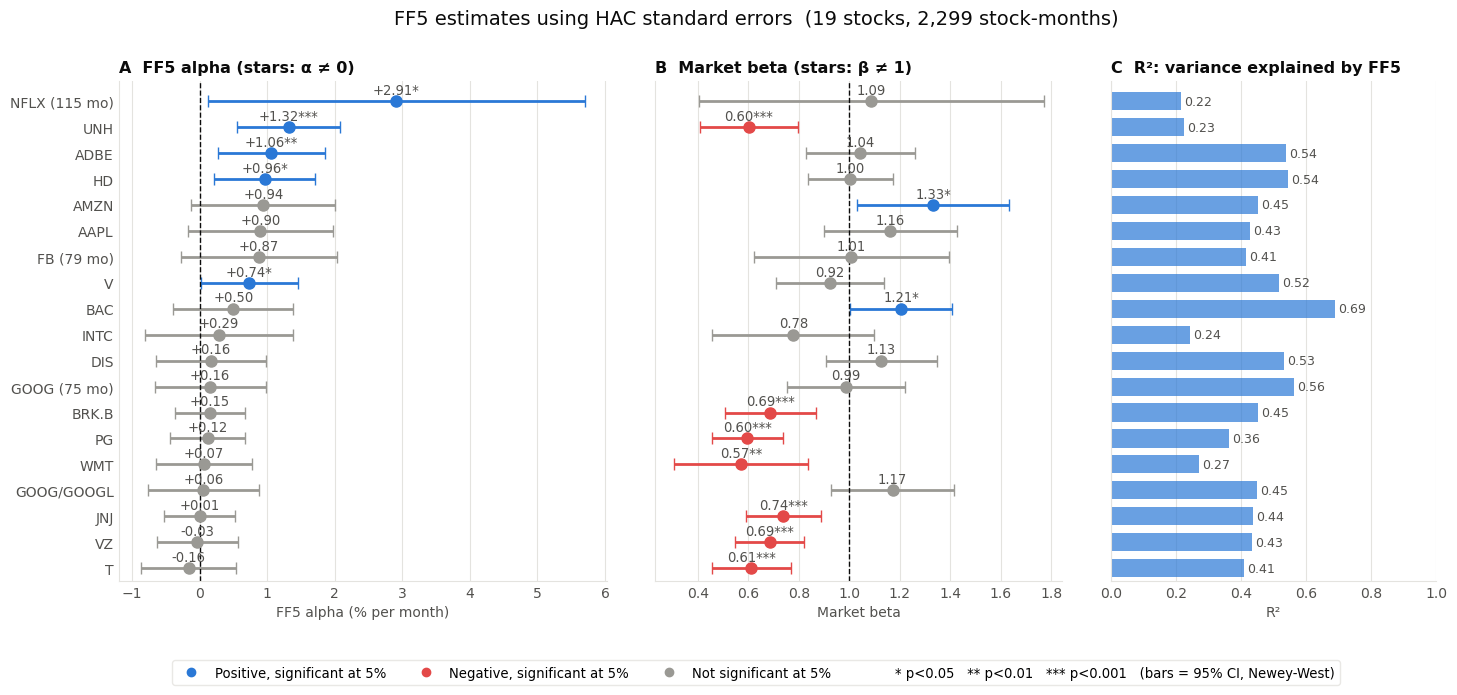

In [ ]:
# FF5 regression for every stock over the return sample (Jan 2010 - Jul 2020), HAC standard errors
#   r_i,t - RF_t = alpha_i + b_i (Mkt-RF)_t + s_i SMB_t + h_i HML_t + r_i RMW_t + c_i CMA_t + e_i,t
# Abnormal return = alpha_i + e_i,t (what the five factors do not explain); residual = e_i,t only (robustness check).
FF5_SAMPLE = (pd.Period("2010-01", "M"), pd.Period("2020-07", "M"))            # covers same-month (t) and next-month (t+1) returns
MIN_FF5_MONTHS = 36                                                             # at least three years of returns per stock

# One regression per security (PERMNO). PERMNO 90319 is tweeted as GOOG before April 2014 and as GOOGL afterwards.
permno_symbol = (portfolio_assignments.sort_values("month").assign(symbol=lambda d: d["symbol"].astype(str))
                 .groupby("PERMNO")["symbol"].agg(lambda s: "/".join(pd.unique(s))).reset_index())
stock_returns = (monthly_crsp_returns.loc[monthly_crsp_returns["valid_return"] & monthly_crsp_returns["return_month"].between(*FF5_SAMPLE),
                                          ["PERMNO", "return_month", "monthly_return"]]
                 .merge(permno_symbol, on="PERMNO", how="inner", validate="many_to_one")
                 .merge(ff5, left_on="return_month", right_index=True, how="inner", validate="many_to_one"))
stock_returns["excess_return"] = stock_returns["monthly_return"] - stock_returns["RF"]

loadings, fitted_parts = [], []
for permno, stock in stock_returns.groupby("PERMNO"):
    if len(stock) < MIN_FF5_MONTHS:
        continue
    fit = sm.OLS(stock["excess_return"], sm.add_constant(stock[FF5_FACTORS])).fit(cov_type="HAC", cov_kwds={"maxlags": NW_LAGS})
    loadings.append({"symbol": stock["symbol"].iloc[0], "months": len(stock), "alpha": 100 * fit.params["const"],
                     "alpha_se": 100 * fit.bse["const"], "alpha_t": fit.tvalues["const"], "beta": fit.params["Mkt-RF"],
                     "beta_se": fit.bse["Mkt-RF"], "r_squared": fit.rsquared})
    fitted_parts.append(pd.DataFrame({"PERMNO": permno, "return_month": stock["return_month"], "ff5_residual": fit.resid,
                                      "ff5_abnormal_return": fit.resid + fit.params["const"]}))
ff5_loadings = pd.DataFrame(loadings).set_index("symbol").sort_values("alpha", ascending=False)
ff5_abnormal = pd.concat(fitted_parts, ignore_index=True)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 6.5), sharey=True, gridspec_kw={"width_ratios": [1.2, 1, 0.8], "wspace": 0.12})
labels = [f"{s} ({m} mo)" if m < 120 else s for s, m in zip(ff5_loadings.index, ff5_loadings["months"])]
dot_ci(ax1, labels, ff5_loadings["alpha"], ff5_loadings["alpha_se"], ff5_loadings["alpha_t"], fmt="{:+.2f}")
ax1.set_xlabel("FF5 alpha (% per month)", color=INK_2)
title(ax1, "A  FF5 alpha (stars: α ≠ 0)")
beta_t = (ff5_loadings["beta"] - 1) / ff5_loadings["beta_se"]
dot_ci(ax2, labels, ff5_loadings["beta"], ff5_loadings["beta_se"], beta_t, fmt="{:.2f}", ref=1.0)
ax2.set_xlabel("Market beta", color=INK_2)
title(ax2, "B  Market beta (stars: β ≠ 1)")
ax3.barh(range(len(ff5_loadings)), ff5_loadings["r_squared"], color=POS, alpha=0.7, height=0.7)
for yi, r2 in enumerate(ff5_loadings["r_squared"]):
    ax3.text(r2 + 0.01, yi, f"{r2:.2f}", va="center", fontsize=9, color=INK_2)
ax3.set_xlim(0, 1)
ax3.set_xlabel("R²", color=INK_2)
style(ax3)
title(ax3, "C  R²: variance explained by FF5")

fig.legend(handles=SIG_LEGEND, loc="lower center", ncol=4, frameon=True, edgecolor=GRID, bbox_to_anchor=(0.5, -0.06), fontsize=9.5)
fig.suptitle(f"FF5 estimates using HAC standard errors  ({len(ff5_loadings)} stocks, {len(ff5_abnormal):,} stock-months)",
             fontsize=14, color=INK, y=0.99)
plt.show()

One row per stock: *A* the FF5 alpha (stars test α ≠ 0), *B* the market beta (stars test β ≠ 1), *C* the R². Stocks with fewer than 120 months of returns show their number of months.

- **Five stocks have a significantly positive alpha** (NFLX +2.91%, UNH +1.32%, ADBE +1.06%, HD +0.96% and V +0.74% per month) and none a negative one. This reflects the sample: large, successful S&P 500 constituents over a strong decade.
- **Defensive stocks have betas well below 1** (WMT, UNH, PG, VZ, BRK.B, T, JNJ: 0.57–0.74); AMZN and BAC are significantly above 1.
- **FF5 explains only 22–69% of the variance**, so most of each stock's monthly return is stock-specific. That is the part an attention signal could, in principle, predict.

### ***Step 5.2:*** *Redo the decile plot with FF5 residuals (residuals vs media attention)*

We repeat the portfolio plot of Step 4.8.1, replacing each stock's raw return in month t+1 by its FF5 residual $\varepsilon_{i,t+1}$ from Step 5.1: the part of the return that the five factors (and the stock's own alpha) do not explain. If media attention carried information beyond known risk exposures, the residual bars would rise or fall from low to high BAA.

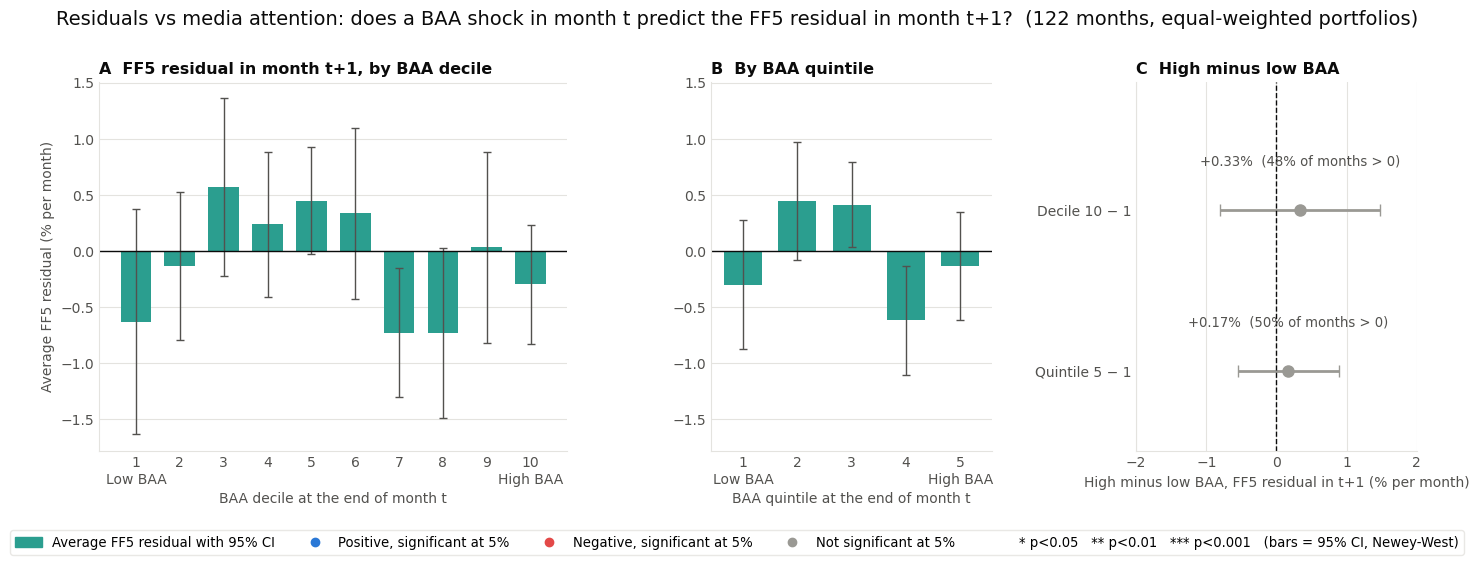

In [ ]:
# Decile plot with FF5 residuals: attention (BAA) in month t, residual in month t+1
def add_ff5(panel_df):
    return panel_df.merge(ff5_abnormal, on=["PERMNO", "return_month"], how="left", validate="many_to_one")

ff5_next_panel = add_ff5(portfolio_return_panel)                                 # return_month = t+1
ff5_same_panel = add_ff5(same_month_panel)                                       # return_month = t
res_decile_wide = portfolio_table(ff5_next_panel, "baa_decile", "ff5_residual")
res_quintile_wide = portfolio_table(ff5_next_panel, "baa_quintile", "ff5_residual")
abn_decile_wide = portfolio_table(ff5_next_panel, "baa_decile", "ff5_abnormal_return")      # used in the robustness figure below
abn_quintile_wide = portfolio_table(ff5_next_panel, "baa_quintile", "ff5_abnormal_return")
fmb_abn = {"t": cross_sectional_tests(ff5_same_panel, "ff5_abnormal_return"),
           "t+1": cross_sectional_tests(ff5_next_panel, "ff5_abnormal_return")}

RES = "#2b9e8f"                                                                  # FF5-adjusted = teal
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 4.8), gridspec_kw={"width_ratios": [1.5, 0.9, 0.9], "wspace": 0.42})
ax2.sharey(ax1)
for ax, wide, k, name in [(ax1, res_decile_wide, 10, "decile"), (ax2, res_quintile_wide, 5, "quintile")]:
    portfolio_bars(ax, wide, k, RES)
    ax.set_xlabel(f"BAA {name} at the end of month t", color=INK_2)
    title(ax, f"A  FF5 residual in month t+1, by BAA decile" if k == 10 else "B  By BAA quintile")
ax1.set_ylabel("Average FF5 residual (% per month)", color=INK_2)

res_spreads = {"Decile 10 − 1": res_decile_wide["high_minus_low"], "Quintile 5 − 1": res_quintile_wide["high_minus_low"]}
dot_ci(ax3, list(res_spreads), *zip(*[newey_west_mean(100 * s) for s in res_spreads.values()]), fmt="{:+.2f}%",
       notes=[f"{(s > 0).mean():.0%} of months > 0" for s in res_spreads.values()])
ax3.set_xlim(-2, 2)
ax3.set_xlabel("High minus low BAA, FF5 residual in t+1 (% per month)", color=INK_2)
title(ax3, "C  High minus low BAA")

fig.legend(handles=[Patch(color=RES, label="Average FF5 residual with 95% CI")] + SIG_LEGEND,
           loc="lower center", ncol=5, frameon=True, edgecolor=GRID, bbox_to_anchor=(0.5, -0.12), fontsize=9.5)
fig.suptitle(f"Residuals vs media attention: does a BAA shock in month t predict the FF5 residual in month t+1?  "
             f"({res_decile_wide.shape[0]} months, equal-weighted portfolios)", fontsize=14, color=INK, y=1.03)
plt.show()

*Panel A* and *Panel B* show the average FF5 residual in month t+1 of each BAA portfolio (bars = 95% Newey-West CI); *Panel C* is the high-minus-low spread, i.e. buying the high-BAA portfolio and shorting the low-BAA one.

- **No pattern from low to high attention.** The residuals zig-zag between −0.73% and +0.57% per month instead of rising or falling with BAA. The few portfolios whose interval excludes zero sit in the middle of the ranking (decile 7 at −0.73%, quintile 3 at +0.41% and quintile 4 at −0.62%), so they reflect noise in portfolios of 2–4 stocks, not an attention effect.
- **The spread is small and not significant:** +0.33% per month for decile 10 − 1 (t = 0.57) and +0.17% for quintile 5 − 1 (t = 0.45), positive in only about half of the months (48% and 50%).
- Because each stock's residuals average zero over its regression sample, the bars compare a stock's months after high attention with its other months: months with an attention shock are not followed by unusually good or bad risk-adjusted performance.

The figure below repeats the exercise with the FF5 abnormal return (alpha + residual) and adds the Fama-MacBeth tests as a robustness check.

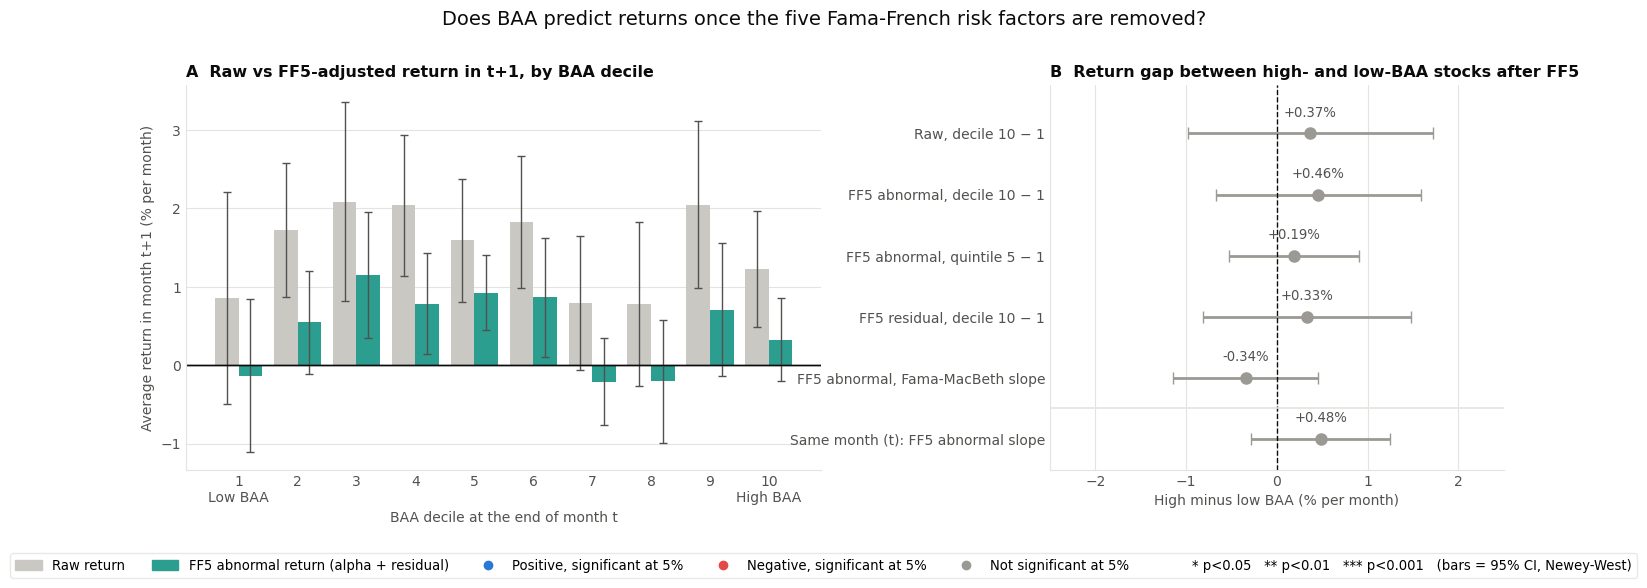

In [ ]:
# Robustness: the high-minus-low tests with the FF5 abnormal return (alpha + residual) instead of the residual alone
fig, ax = plt.subplots(figsize=(10, 5))
tests = {"Raw, decile 10 − 1": decile_wide["high_minus_low"],
         "FF5 abnormal, decile 10 − 1": abn_decile_wide["high_minus_low"],
         "FF5 abnormal, quintile 5 − 1": abn_quintile_wide["high_minus_low"],
         "FF5 residual, decile 10 − 1": res_decile_wide["high_minus_low"],
         "FF5 abnormal, Fama-MacBeth slope": fmb_abn["t+1"]["slope"],
         "Same month (t): FF5 abnormal slope": fmb_abn["t"]["slope"]}
dot_ci(ax, list(tests), *zip(*[newey_west_mean(100 * s) for s in tests.values()]), fmt="{:+.2f}%")
ax.axhline(4.5, color=GRID, linewidth=1.2)                                      # separates the next-month tests from the same-month one
ax.set_xlim(-2.5, 2.5)
ax.set_xlabel("High minus low BAA (% per month)", color=INK_2)
title(ax, "Return gap between high- and low-BAA stocks after FF5 (raw return as benchmark)")

fig.legend(handles=SIG_LEGEND, loc="lower center", ncol=2, frameon=True, edgecolor=GRID, bbox_to_anchor=(0.5, -0.16), fontsize=9.5)
fig.suptitle("Does BAA predict returns once the five Fama-French risk factors are removed?", fontsize=14, color=INK, y=1.03)
plt.show()

We repeat the high-minus-low and Fama-MacBeth tests using the FF5 abnormal return (alpha + residual) instead of the residual alone; the raw decile spread is shown as a benchmark and the last row is the same-month version.

Removing risk exposure does not reveal an attention effect: the decile 10 − 1 abnormal spread is +0.46% per month (t = 0.80), the quintile spread +0.19% (t = 0.53), the residual-only spread +0.33% (t = 0.57) and the Fama-MacBeth slope −0.34% (t = −0.84). None is significant.

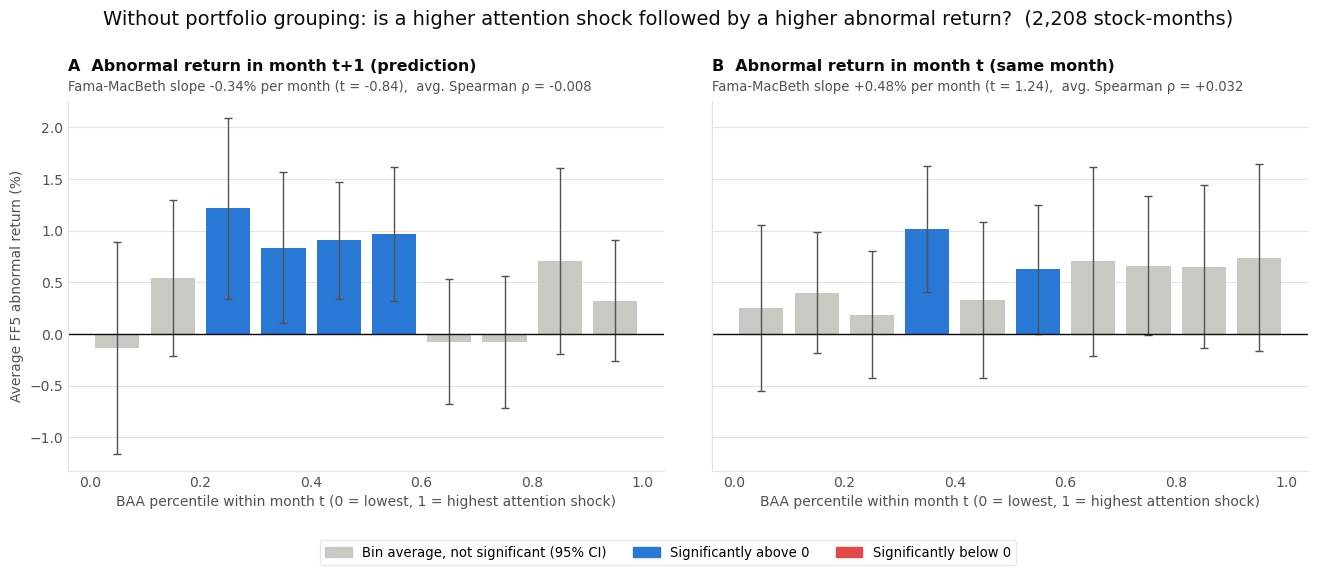

In [ ]:
# The same question without portfolios: average FF5 abnormal return by BAA percentile, stock-month by stock-month
BINS = np.linspace(0, 1, 11)                                                     # ten equal-width BAA percentile bins

fig, axes = plt.subplots(1, 2, figsize=(16, 4.8), sharey=True, gridspec_kw={"wspace": 0.08})
for ax, panel_df, key, name in [(axes[0], ff5_next_panel, "t+1", "A  Abnormal return in month t+1 (prediction)"),
                                (axes[1], ff5_same_panel, "t", "B  Abnormal return in month t (same month)")]:
    points = panel_df.dropna(subset=["baa_sort_percentile", "ff5_abnormal_return"])
    binned = (100 * points["ff5_abnormal_return"]).groupby(pd.cut(points["baa_sort_percentile"], BINS, include_lowest=True),
                                                           observed=True).agg(["mean", "sem", "size"])
    centers = [interval.mid for interval in binned.index]
    significant = (binned["mean"].abs() > 1.96 * binned["sem"])
    ax.bar(centers, binned["mean"], width=0.08, yerr=1.96 * binned["sem"], capsize=3, error_kw={"elinewidth": 1, "ecolor": INK_2},
           color=np.where(significant, np.where(binned["mean"] > 0, POS, NEG), NEU))
    slope, se, t = newey_west_mean(100 * fmb_abn[key]["slope"])
    rho = fmb_abn[key]["rank_correlation"].mean()
    ax.text(0, 1.02, f"Fama-MacBeth slope {slope:+.2f}% per month (t = {t:.2f}),  avg. Spearman ρ = {rho:+.3f}",
            transform=ax.transAxes, va="bottom", fontsize=9.5, color=INK_2)
    ax.axhline(0, color=INK, linewidth=1)
    ax.set_xticks(BINS[::2], [f"{b:.1f}" for b in BINS[::2]])
    ax.set_xlabel("BAA percentile within month t (0 = lowest, 1 = highest attention shock)", color=INK_2)
    style(ax, grid="y")
    title(ax, name, pad=22)
axes[0].set_ylabel("Average FF5 abnormal return (%)", color=INK_2)

fig.legend(handles=[Patch(color=NEU, label="Bin average, not significant (95% CI)"), Patch(color=POS, label="Significantly above 0"),
                    Patch(color=NEG, label="Significantly below 0")],
           loc="lower center", ncol=3, frameon=True, edgecolor=GRID, bbox_to_anchor=(0.5, -0.1), fontsize=9.5)
fig.suptitle(f"Without portfolio grouping: is a higher attention shock followed by a higher abnormal return?  "
             f"({len(ff5_next_panel.dropna(subset=['ff5_abnormal_return'])):,} stock-months)", fontsize=14, color=INK, y=1.07)
plt.show()

Instead of forming portfolios, each stock-month is placed in one of ten bins by its BAA percentile, and the bars show the average FF5 abnormal return in each bin (95% CI). If attention predicted returns, the bars in *A* would rise (or fall) from left to right.

- **There is no slope.** In *Panel A* the significantly positive bins sit in the middle (percentiles 0.2–0.6), while the lowest- and highest-BAA bins are both indistinguishable from zero. The Fama-MacBeth slope is −0.34% per month (t = −0.84) and the rank correlation −0.008.
- In the same month (*Panel B*) the bars are flat at around +0.5%; the slope (+0.48%, t = 1.24) is not significant either.

### ***Step 5.3:*** *Is BAA a new factor?*

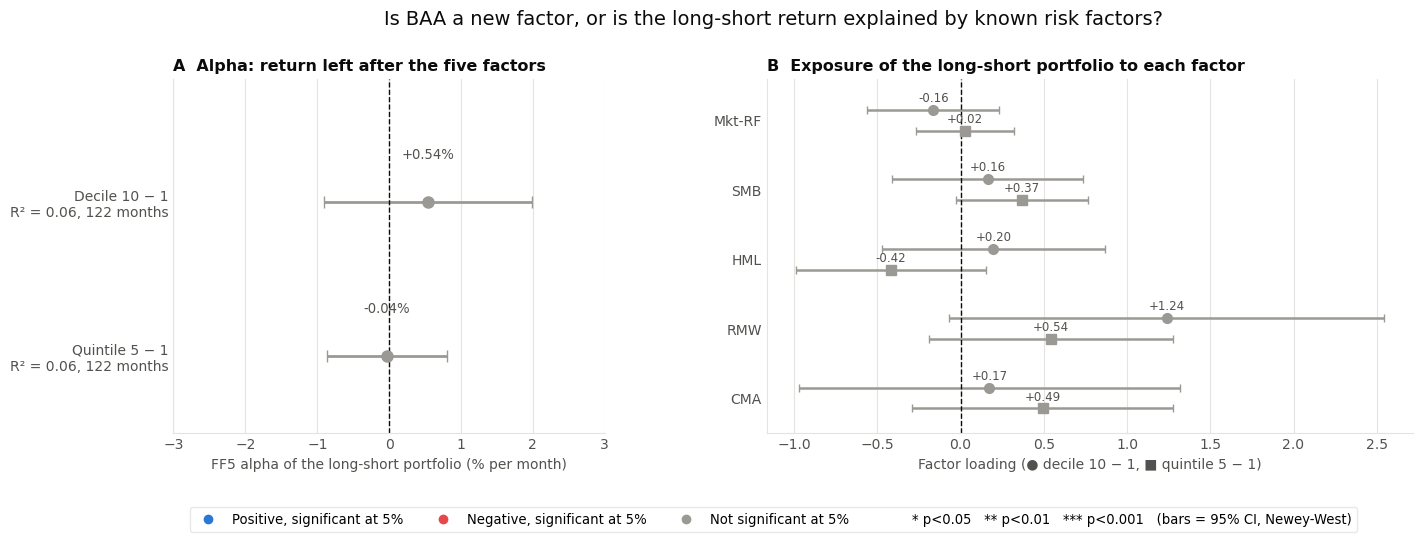

In [ ]:
# Is the BAA long-short portfolio a new factor? Regress the raw high-minus-low spread on the five factors.
# A significant alpha would mean BAA earns returns that the five traditional factors cannot explain.
def ff5_spread_regression(spread, lags=NW_LAGS):
    data = spread.rename("spread").to_frame().join(ff5[FF5_FACTORS], how="inner").dropna()
    return sm.OLS(100 * data["spread"], sm.add_constant(data[FF5_FACTORS])).fit(cov_type="HAC", cov_kwds={"maxlags": lags})

spread_fits = {"Decile 10 − 1": ff5_spread_regression(decile_wide["high_minus_low"]),     # decile_wide is indexed by return month
               "Quintile 5 − 1": ff5_spread_regression(quintile_wide["high_minus_low"])}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4.6), gridspec_kw={"width_ratios": [0.8, 1.2], "wspace": 0.3})
dot_ci(ax1, [f"{n}\nR² = {f.rsquared:.2f}, {int(f.nobs)} months" for n, f in spread_fits.items()],
       [f.params["const"] for f in spread_fits.values()], [f.bse["const"] for f in spread_fits.values()],
       [f.tvalues["const"] for f in spread_fits.values()], fmt="{:+.2f}%")
ax1.set_xlim(-3, 3)
ax1.set_xlabel("FF5 alpha of the long-short portfolio (% per month)", color=INK_2)
title(ax1, "A  Alpha: return left after the five factors")

offsets = {"Decile 10 − 1": -0.15, "Quintile 5 − 1": 0.15}
for name, fit in spread_fits.items():
    for yi, factor in enumerate(FF5_FACTORS):
        b, se, t = fit.params[factor] / 100, fit.bse[factor] / 100, fit.tvalues[factor]     # back to a plain loading
        color = (POS if b > 0 else NEG) if abs(t) > 1.96 else ETF_GREY
        ax2.errorbar(b, yi + offsets[name], xerr=1.96 * se, fmt="o" if name.startswith("Decile") else "s", color=color,
                     markersize=7, capsize=3, linewidth=1.8)
        ax2.text(b, yi + offsets[name] - 0.12, f"{b:+.2f}{stars(t)}", ha="center", fontsize=8.5, color=INK_2)
ax2.axvline(0, color=INK, linestyle="--", linewidth=1)
ax2.set_yticks(range(len(FF5_FACTORS)), FF5_FACTORS)
ax2.set_ylim(len(FF5_FACTORS) - 0.5, -0.6)
ax2.set_xlabel("Factor loading (● decile 10 − 1, ■ quintile 5 − 1)", color=INK_2)
style(ax2)
title(ax2, "B  Exposure of the long-short portfolio to each factor")

fig.legend(handles=SIG_LEGEND, loc="lower center", ncol=4, frameon=True, edgecolor=GRID, bbox_to_anchor=(0.5, -0.12), fontsize=9.5)
fig.suptitle("Is BAA a new factor, or is the long-short return explained by known risk factors?", fontsize=14, color=INK, y=1.03)
plt.show()

We regress the monthly long-short return (high minus low BAA) on the five factors. *Panel A* is the alpha, the return left after the factors: a significant alpha would make BAA a new, priced factor. *Panel B* shows how much the long-short portfolio loads on each factor (● decile 10 − 1, ■ quintile 5 − 1).

- **The alpha is not significant:** +0.54% per month for deciles (t = 0.73) and −0.04% for quintiles (t = −0.08).
- **The five factors explain almost nothing** (R² ≈ 0.06) and no loading is significant. The spread is neither a hidden factor bet nor a new factor: it is mostly noise.

# 7. Conclusions

### *Does BAA predict returns?*

In Step 4.7 we set six conditions for calling BAA a promising return predictor. The evidence:

| Condition | Result | Met? |
|---|---|---|
| 1. Economically meaningful | Spreads of +0.2% to +0.5% per month that change sign from year to year | ✗ |
| 2. Statistically different from zero | No spread, slope or alpha is significant (all \|t\| < 1.3) | ✗ |
| 3. Reasonably monotonic across portfolios | Decile and quintile returns zig-zag; abnormal returns peak in the middle bins | ✗ |
| 4. Visible in quintile and continuous tests | Quintile spread +0.20% (t = 0.47); Fama-MacBeth slope −0.36% (t = −0.70) | ✗ |
| 5. Not driven by a few stocks | Deciles hold about 1.8 stocks, so single stocks dominate them; with no significant effect this is a limitation, not a driver | – |
| 6. Survives risk adjustment | FF5 abnormal spread +0.46% (t = 0.80); long-short FF5 alpha +0.54% (t = 0.73) | ✗ |

**Within our S&P 500 subsample, StockTwits attention shocks do not predict next-month returns, before or after adjusting for the five Fama-French factors, and they are not a new factor.**

This should be read as an absence of evidence rather than proof that attention never matters:
- **Low power.** Only 15–19 stocks per month (TSLA, the most-tweeted stock, is never in the S&P 500 file during the sample), so deciles hold one or two stocks and confidence intervals are wide.
- **Horizon.** Attention-driven buying (Barber and Odean, 2008) is expected to push prices up quickly and then reverse; a monthly horizon may average that effect away. Daily or weekly returns would be the natural next test.
- **Selection.** Large, liquid S&P 500 constituents are the stocks where attention should matter least; the effect may be stronger in smaller, less-followed firms.

# 8. Acknowledgements and references

**Acknowledgements.** Team project by Cecilia Lo Cicero, Sara Pulidori, Alissa Sharuda and Nico Visentin, developed as coursework for *20598 – Finance with Big Data* (MSc, Bocconi University), taught by Clément Mazet-Sonilhac. The assignment framework was provided by the course; the analysis, extensions and write-up are the team's own.

**References**

- Antweiler, W., & Frank, M. Z. (2004). Is all that talk just noise? The information content of internet stock message boards. *Journal of Finance*, 59(3), 1259–1294.
- Araci, D. (2019). FinBERT: Financial sentiment analysis with pre-trained language models. arXiv:1908.10063.
- Barber, B. M., & Odean, T. (2008). All that glitters: The effect of attention and news on the buying behavior of individual and institutional investors. *Review of Financial Studies*, 21(2), 785–818.
- Da, Z., Engelberg, J., & Gao, P. (2011). In search of attention. *Journal of Finance*, 66(5), 1461–1499.
- Fama, E. F., & French, K. R. (2015). A five-factor asset pricing model. *Journal of Financial Economics*, 116(1), 1–22.
- Fama, E. F., & MacBeth, J. D. (1973). Risk, return, and equilibrium: Empirical tests. *Journal of Political Economy*, 81(3), 607–636.
- Lee, J., Youn, H. L., Poon, J., & Han, S. C. (2023). StockEmotions: Discover investor emotions for financial sentiment analysis and multivariate time series. arXiv:2301.09279.
- Loureiro, D., Barbieri, F., Neves, L., Espinosa Anke, L., & Camacho-Collados, J. (2022). TimeLMs: Diachronic language models from Twitter. *ACL 2022 System Demonstrations*.
- Newey, W. K., & West, K. D. (1987). A simple, positive semi-definite, heteroskedasticity and autocorrelation consistent covariance matrix. *Econometrica*, 55(3), 703–708.
- Models: [`cardiffnlp/twitter-roberta-base-sentiment-latest`](https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest), [`ProsusAI/finbert`](https://huggingface.co/ProsusAI/finbert), [`StephanAkkerman/FinTwitBERT-sentiment`](https://huggingface.co/StephanAkkerman/FinTwitBERT-sentiment), `openai/gpt-oss-120b` via Groq.